# Benchmarking and Evaluation

## Prepare Environment

Set up the notebook environment with necessary imports and create reusable utility functions for tasks we'll repeat across all datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import copy
import time
import numpy as np
import pandas as pd
from scipy.stats import iqr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

import utils
from sgkan import sgkan_parameter_search as sps
from sgkan import sgkan_model
from hkan.hkan import (
    ExpandingLayer, ConnectingLayer,
    make_hkan_layer, extend_hkan,
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
    set_tqdm_disable,
)
import visualize
import swim as ss
import evaluation_metrics as em
random_seed = 0

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[plot_hypothesis_legend] saved to static/hypothesis_legend_rmse.png


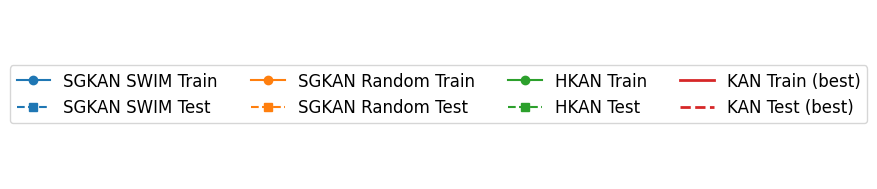

[plot_hypothesis_legend] saved to static/hypothesis_legend_time.png


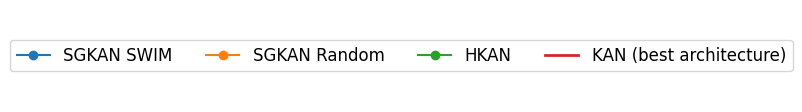

[plot_hypothesis_legend] saved to static/hypothesis_legend_inference.png


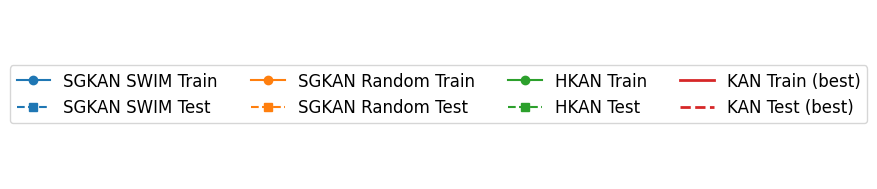

In [2]:
visualize.plot_hypothesis_legend(kind="rmse")        # for all Hypothesis 1 (RMSE) plots
visualize.plot_hypothesis_legend(kind="time")         # for all Hypothesis 2 (training time) plots
visualize.plot_hypothesis_legend(kind="inference")    # for all Hypothesis 3 (inference time) plots

In [3]:
def load_dataset(dataset_prefix: str):
    """Load dataset using dataset prefix."""
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "data")
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test

tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (3750, 10)
y_train shape: (3750,)
x_test shape: (1250, 10)
y_test shape: (1250,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)


## TF1

### SG-KAN

In [3]:
# Find best parameter configuration
tf1_sgkan_result = sps.study_optuna_sgkan(
    "tf1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
    n_trials=375
)

# Use best parameter configuration to fit an SGKAN model again
best_tf1_sgkan_configs = tf1_sgkan_result["layer_configs"]
best_tf1_sgkan_configs

Results found for tf1. Loading from data/tf1_sgkan_optuna_search.csv
Best Validation RMSE:   0.000000000019718
Best Test RMSE:          0.000000000166345
Best layer_width:        1000
Best num_inducing:       50
Best alpha_edge:         1.000e+01
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number             value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type          val_rmse     test_rmse
0         0  6.7783242464e-05                1000                   50              0.001                    0             matern  6.7783242464e-05           NaN
1         1  5.6343439768e-02                1000                   25              1.000                    0           periodic  5.6343439768e-02           NaN
2         2  1.4776349045e-06                 500                   50             10.000                    0                rbf  1.4776349045e-06           NaN
3         3  5.732019730

[{'layer_width': 1000,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [4]:
tf1_sgkan_optuna_df = pd.read_csv("data/tf1_sgkan_optuna_search.csv")
tf1_sgkan_optuna_df.sort_values("val_rmse").head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
321,321,1.9718027054e-11,2026-08-06 15:00:30.665284,2026-08-06 15:00:50.975097,20.309813,10.0,0,rbf,1000,50,...,19.114862333,rbf,1000,50,1,1.9718027054e-11,321,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0000000002
207,207,5.4813087171e-11,2026-08-06 14:38:20.330624,2026-08-06 14:38:37.604884,17.274260,1.0,0,rbf,1000,50,...,16.017670875,rbf,1000,50,1,5.4813087171e-11,207,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
254,254,9.7881640041e-11,2026-08-06 14:47:21.200069,2026-08-06 14:47:31.224114,10.024045,10.0,0,rbf,1000,25,...,9.179296000,rbf,1000,25,1,9.7881640041e-11,254,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
363,363,6.0005247809e-10,2026-08-06 15:08:44.622213,2026-08-06 15:08:57.881550,13.259337,1.0,0,rbf,750,50,...,12.383522542,rbf,750,50,1,6.0005247809e-10,363,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
83,83,7.0983632996e-10,2026-08-06 14:16:56.022367,2026-08-06 14:17:29.504933,33.482566,10.0,0,rbf,1000,100,...,31.325037375,rbf,1000,100,1,7.0983632996e-10,83,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
305,305,1.6567754100e-09,2026-08-06 14:57:36.145585,2026-08-06 14:57:41.769204,5.623619,10.0,0,rbf,1000,10,...,5.090786791,rbf,1000,10,1,1.6567754100e-09,305,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
6,6,2.1652957075e-09,2026-08-06 14:00:48.891094,2026-08-06 14:01:24.617614,35.726520,1.0,0,rbf,1000,100,...,33.391136083,rbf,1000,100,1,2.1652957075e-09,6,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
370,370,2.6612455195e-09,2026-08-06 15:09:32.870993,2026-08-06 15:09:58.643458,25.772465,10.0,0,rbf,1000,75,...,24.096895709,rbf,1000,75,1,2.6612455195e-09,370,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
64,64,2.7290326661e-09,2026-08-06 14:13:07.031479,2026-08-06 14:13:12.009842,4.978363,1.0,0,rbf,1000,10,...,4.718459125,rbf,1000,10,1,2.7290326661e-09,64,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
145,145,2.8717483189e-09,2026-08-06 14:27:35.291063,2026-08-06 14:27:40.223432,4.932369,0.1,0,rbf,1000,10,...,4.654529709,rbf,1000,10,1,2.8717483189e-09,145,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [5]:
# Calculate training time
start = time.perf_counter()
best_tf1_sgkan_model = sgkan_model.SGKANModel(best_tf1_sgkan_configs).fit(tf1_x_train, tf1_y_train)
fit_time = time.perf_counter() - start
print("SWIM Training time: ", fit_time)

best_tf1_sgkan_results = em.evaluate(
    best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(best_tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1204, 'interval': 755, 'knn_fallback': 41}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 858, 'interval': 137, 'knn_fallback': 5}
[SGKANModel.fit] Total fit duration: 24.0401s
SWIM Training time:  24.040456250000716
Metric          Train                Test                
-------------------------------------------------------
MAE             1.293834e-11         3.092844e-11        
RMSE            1.714553e-11         1.663452e-10        
-------------------------------------------------------
Inference (s)   7.479810             14.633528           


In [6]:
# SWIM (Random) ablation
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf1_sgkan_configs = copy.deepcopy(best_tf1_sgkan_configs)
for i in random_best_tf1_sgkan_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf1_sgkan_configs, best_tf1_sgkan_configs

([{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [7]:
# Calculate training time
start = time.perf_counter()
random_best_tf1_sgkan_model = sgkan_model.SGKANModel(random_best_tf1_sgkan_configs).fit(tf1_x_train, tf1_y_train)
fit_time = time.perf_counter() - start
print("SWIM(Random) Training time: ", fit_time)

random_best_tf1_sgkan_results = em.evaluate(
    random_best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(random_best_tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1253, 'interval': 705, 'knn_fallback': 42}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 722, 'knn_fallback': 82, 'interval_capped': 196}
[SGKANModel.fit] Total fit duration: 29.4881s
SWIM(Random) Training time:  29.488544957999693
Metric          Train                Test                
-------------------------------------------------------
MAE             1.148366e-04         1.598896e-04        
RMSE            1.522128e-04         2.490166e-04        
-------------------------------------------------------
Inference (s)   9.554678             16.682621           


#### 50 Seed Results

In [8]:
tf1_sgkan_50_runs_path = "data/tf1_sgkan_50_run_results.csv"

# Load cached results if they exist
if os.path.exists(tf1_sgkan_50_runs_path):
    tf1_sgkan_50_runs_df = pd.read_csv("data/tf1_sgkan_50_run_results.csv")
else:
    tf1_sgkan_50_runs = utils.run_sgkan_seed_experiments(tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, best_tf1_sgkan_configs, n_runs=50)
    tf1_sgkan_50_runs_df = utils.create_export_seed_results(tf1_sgkan_50_runs, "tf1_sgkan_50_run_results")

tf1_sgkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,1.2938335951e-11,1.7145528925e-11,6.807527083,3.0928436261e-11,0.0000000002,12.934858208,22.042198250
1,1,3.5251641094e-10,4.7042667663e-10,6.642470375,7.0116639996e-10,0.0000000058,13.328321000,18.485489667
2,2,8.4504134687e-10,1.1167596268e-09,7.273512584,1.5272860610e-09,0.0000000049,14.736192917,22.005633209
3,3,2.7916776666e-09,3.6551723357e-09,7.359468958,5.3078205909e-09,0.0000000404,14.983615708,21.541696041
4,4,1.0656151038e-11,1.3987647995e-11,8.317768542,2.3743281808e-11,0.0000000002,15.202450709,21.018501084
5,5,1.2523057101e-08,1.6273093598e-08,6.402344875,2.1808511336e-08,0.0000000825,12.856338833,18.260000167
6,6,3.2685029460e-10,4.3289728259e-10,6.714450750,7.7526130595e-10,0.0000000072,13.255049125,17.867163084
7,7,7.5064554502e-08,1.0035730582e-07,8.183887709,1.1451468122e-07,0.0000003418,13.166646958,19.537271459
8,8,3.3335906674e-10,4.4333071930e-10,6.816866333,5.9283708878e-10,0.0000000018,13.259642875,20.311698166
9,9,5.7904541384e-11,7.5157796958e-11,6.774790958,1.2639126682e-10,0.0000000008,13.255694333,18.334407500


In [9]:
tf1_sgkan_summary = utils.summarize_metrics(tf1_sgkan_50_runs_df, "TF1 SGKAN")
tf1_sgkan_summary

{'model': 'TF1 SGKAN',
 'train_rmse_median': 2.3881136805168462e-09,
 'train_rmse_iqr': 4.300725423622135e-08,
 'test_rmse_median': 1.810754876484368e-08,
 'test_rmse_iqr': 1.733479180379478e-07,
 'train_inference_time_median': 7.316490771001554,
 'train_inference_time_iqr': 1.4860289067473786,
 'test_inference_time_median': 13.916247854001995,
 'test_inference_time_iqr': 1.892095416995291,
 'fit_time_median': 20.478097666506073,
 'fit_time_iqr': 6.298928563501253}

#### Explore Feature Importances and Layers

In [10]:
best_tf1_sgkan_stages, best_tf1_sgkan_ytrain_hat, best_tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, best_tf1_sgkan_configs)

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1204, 'interval': 755, 'knn_fallback': 41}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 858, 'interval': 137, 'knn_fallback': 5}


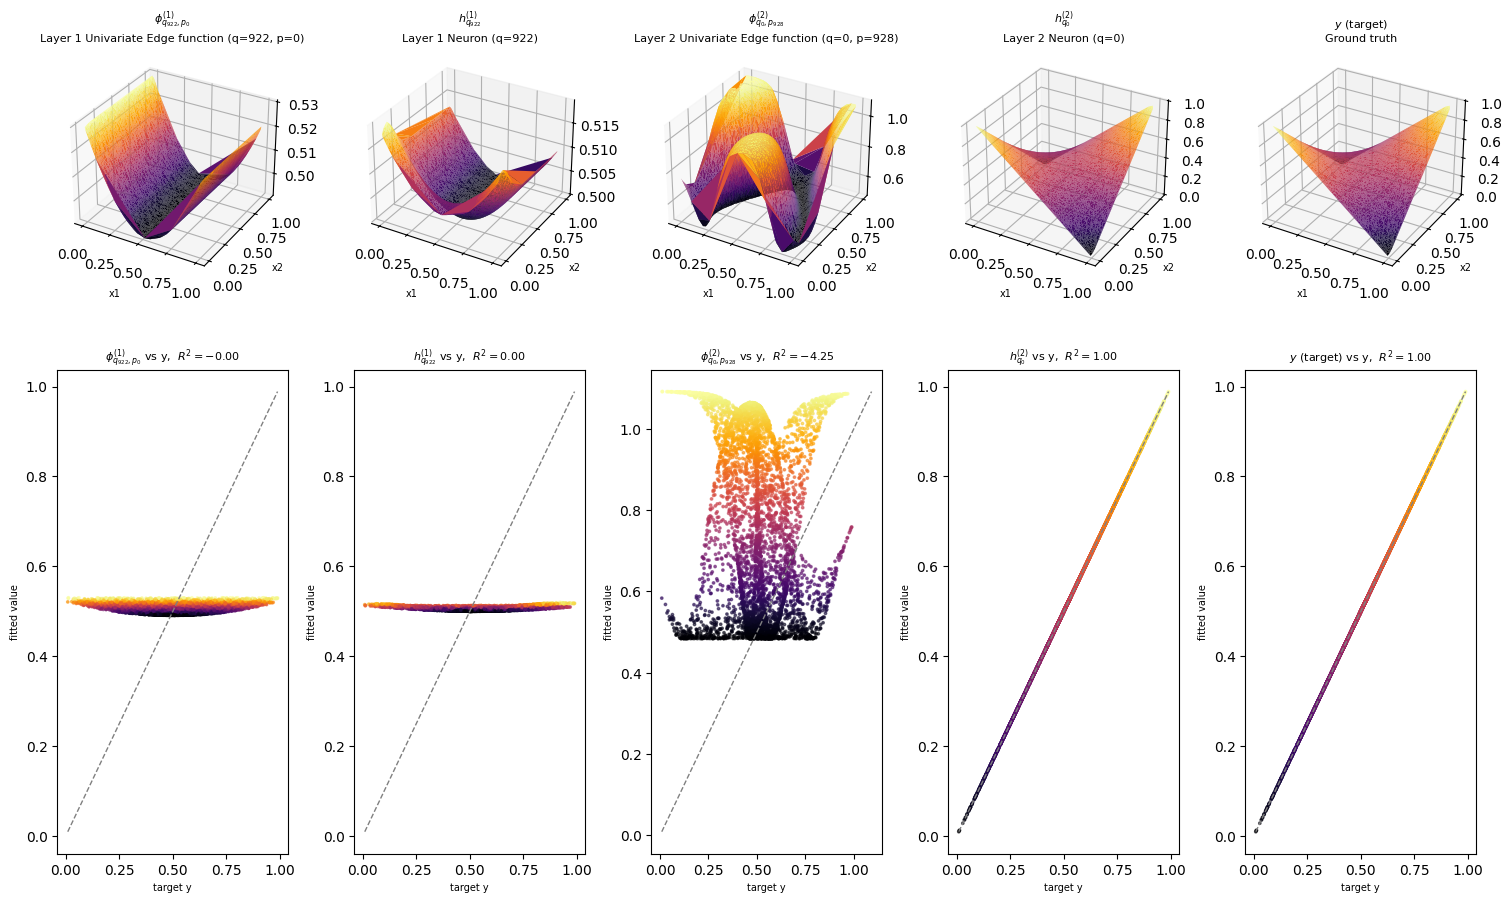

In [11]:
visualize.plot_model_stages(tf1_x_train, tf1_y_train, best_tf1_sgkan_stages, block_idx="random")

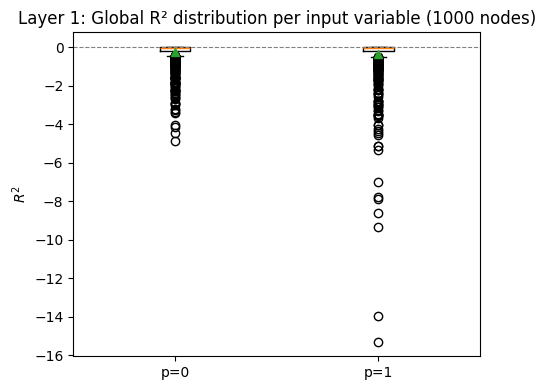

In [12]:
# Global
visualize.plot_first_layer_featurewise_r2_summary(best_tf1_sgkan_stages, tf1_y_train)

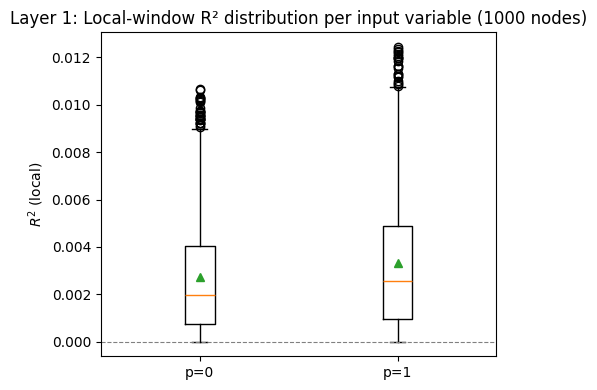

In [13]:
# Local
visualize.plot_first_layer_local_edge_r2_summary(best_tf1_sgkan_layer_neurons)

### HKAN

Layer: 0
Layer: 1


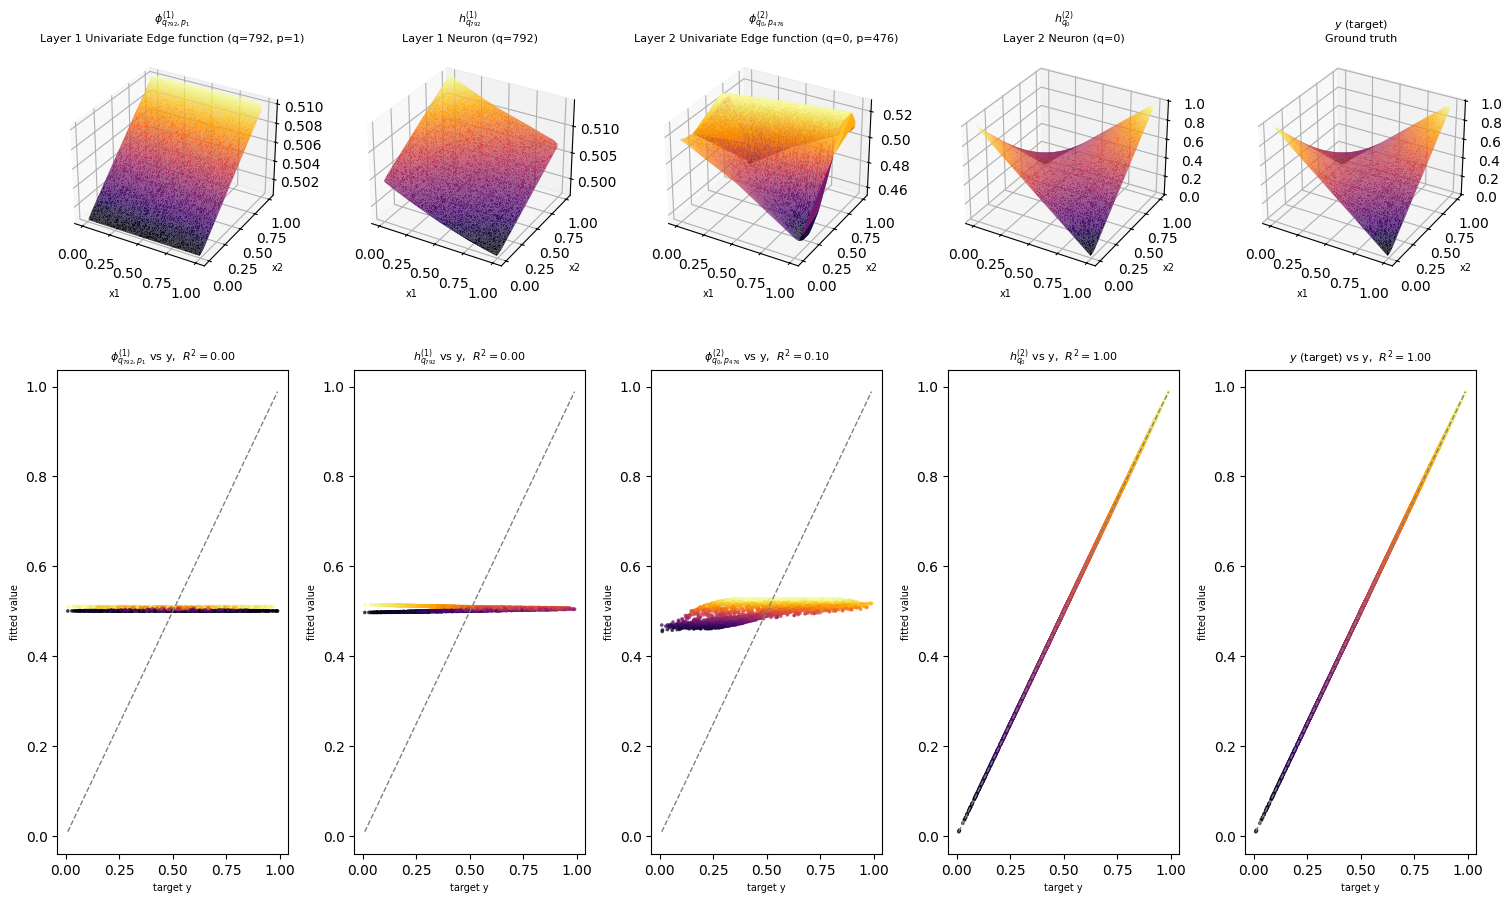

In [14]:
# Best TF1 HKAN configuration from the paper
tf1_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

tf1_hkan_stages, tf1_ytrain_hat = utils.stack_hkan_layers(tf1_x_train, tf1_y_train, tf1_hkan_layer_configs)
visualize.plot_model_stages(tf1_x_train, tf1_y_train, tf1_hkan_stages, block_idx="random", seed=0)

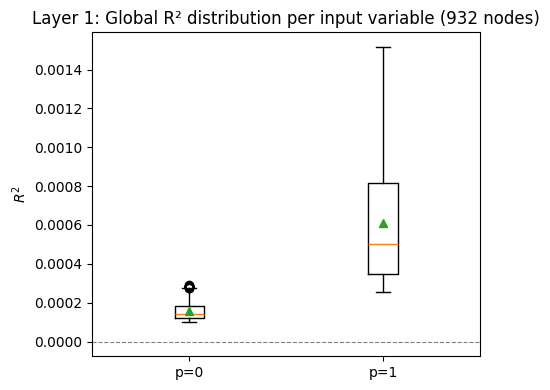

In [15]:
visualize.plot_first_layer_featurewise_r2_summary(tf1_hkan_stages, tf1_y_train)

In [16]:
tf1_hkan_model = utils.build_hkan_model_from_configs(tf1_hkan_layer_configs)
utils.fit_hkan(tf1_hkan_model, tf1_x_train, tf1_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  2.93it/s]


✓ HKAN training completed in 3.2532 seconds


In [17]:
tf1_hkan_results = em.evaluate(tf1_hkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
em.print_results(tf1_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.244636e-11         1.450749e-11        
RMSE            1.668325e-11         2.767774e-11        
-------------------------------------------------------
Inference (s)   1.107656             1.716668            


In [18]:
tf1_hkan_50_runs_path = "data/tf1_hkan_50_run_results.csv"

# Load cached results if they exist
if os.path.exists(tf1_hkan_50_runs_path):
    tf1_hkan_50_runs_df = pd.read_csv("data/tf1_hkan_50_run_results.csv")
else:
    tf1_hkan_50_runs = utils.run_hkan_seed_experiments(tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, tf1_hkan_layer_configs, n_runs=50)
    tf1_hkan_50_runs_df = utils.create_export_seed_results(tf1_hkan_50_runs, "tf1_hkan_50_run_results")

tf1_hkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,1.5125656372e-11,2.0242433154e-11,1.227057125,1.7078801184e-11,2.5281543829e-11,2.457613459,3.988327708
1,1,1.3447239641e-11,1.8126549352e-11,1.546925042,1.5694193579e-11,2.9946773400e-11,2.388090417,3.810348125
2,2,1.2567302609e-11,1.6685643961e-11,1.042406708,1.4449409812e-11,2.3827304509e-11,2.140022250,3.536159959
3,3,1.8126126443e-11,2.4639080376e-11,1.183376834,2.1239455881e-11,3.5991024708e-11,2.021152334,3.509506333
4,4,1.0556423568e-11,1.4265346554e-11,1.412527250,1.1990460717e-11,1.8946742957e-11,1.849695833,3.385597250
5,5,1.1447387915e-11,1.5350642393e-11,1.077303500,1.3371552758e-11,2.1485274232e-11,1.921823250,3.421251875
6,6,1.0660818439e-11,1.4213525316e-11,1.151226625,1.2099441649e-11,1.8773774937e-11,1.995820458,3.460555209
7,7,9.9494174118e-12,1.3416590609e-11,1.062301583,1.1316754866e-11,2.4008093207e-11,1.937245667,3.673428792
8,8,1.0211286544e-11,1.3232660894e-11,1.129816125,1.1547390372e-11,1.9427724063e-11,2.011834666,3.368224917
9,9,1.2950272530e-11,1.7818680296e-11,1.103812583,1.5109816259e-11,2.5339426842e-11,1.927440708,3.343040292


In [19]:
tf1_hkan_summary = utils.summarize_metrics(tf1_hkan_50_runs_df, "TF1 HKAN")
tf1_hkan_summary

{'model': 'TF1 HKAN',
 'train_rmse_median': 1.5767214228132815e-11,
 'train_rmse_iqr': 3.908054711691378e-12,
 'test_rmse_median': 2.2646640551961518e-11,
 'test_rmse_iqr': 6.0379549511298735e-12,
 'train_inference_time_median': 1.1277010000048904,
 'train_inference_time_iqr': 0.09902558399335248,
 'test_inference_time_median': 1.9899430204968667,
 'test_inference_time_iqr': 0.10327593724650797,
 'fit_time_median': 3.3871759790054057,
 'fit_time_iqr': 0.15780390649888432}

### KAN

In [20]:
tf1_kan_study = utils.study_optuna_kan("TF1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
tf1_kan_best_architecture = tf1_kan_study["architecture"]
tf1_kan_best_architecture

Results found for TF1. Loading from data/tf1_kan_optuna_search.csv
Best Validation RMSE:   0.000002
Best architecture:       [2, 3, 3, 1]

All 10 trials:
   number  params_width_idx user_attrs_architecture  user_attrs_val_rmse user_attrs_grids  user_attrs_steps_per_grid user_attrs_opt  user_attrs_lamb   duration
0       0                 8            [2, 5, 3, 1]         0.0000225551      (5, 10, 20)                         20          LBFGS                0  54.092953
1       1                 1               [2, 2, 1]         0.0006650177      (5, 10, 20)                         20          LBFGS                0  25.493952
2       2                 5            [2, 3, 2, 1]         0.0000574597      (5, 10, 20)                         20          LBFGS                0  42.339769
3       3                 0                  [2, 1]         0.1635495494      (5, 10, 20)                         20          LBFGS                0   8.247715
4       4                 7            [2, 3, 

[2, 3, 3, 1]

In [21]:
# Calculate training time
start = time.perf_counter()
model = utils.build_kan(width=tf1_kan_best_architecture, grid=3, k=3, seed=42)
model = utils.fit_kan_with_grid_extension(
    model,
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
    grids=(5, 10, 20), steps_per_grid=20, opt="LBFGS", lamb=0,
)
fit_time = time.perf_counter() - start
print("TF1 KAN Training time: ", fit_time)

tf1_kan_results = em.evaluate(
    utils.KANModel(model),
    tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(tf1_kan_results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.94e-04 | test_loss: 2.09e-04 | reg: 1.30e+01 | : 100%|█| 20/20 [00:07<00:00,  2.65it


saving model version 0.1
saving model version 0.2


| train_loss: 3.83e-05 | test_loss: 4.61e-05 | reg: 1.29e+01 | : 100%|█| 20/20 [00:07<00:00,  2.83it


saving model version 0.3
saving model version 0.4


| train_loss: 5.52e-06 | test_loss: 6.05e-05 | reg: 1.29e+01 | : 100%|█| 20/20 [00:08<00:00,  2.23it


saving model version 0.5
saving model version 0.6


| train_loss: 3.09e-06 | test_loss: 2.81e-04 | reg: 1.29e+01 | : 100%|█| 20/20 [00:13<00:00,  1.43it

saving model version 0.7

✓ KAN training with grid extension completed in 37.9805 seconds
TF1 KAN Training time:  38.01791937499911
Metric          Train                Test                
-------------------------------------------------------
MAE             2.109149e-06         6.726316e-06        
RMSE            3.091771e-06         2.808558e-04        
-------------------------------------------------------
Inference (s)   0.027235             0.042909            


In [5]:
tf1_kan_50_runs_path = "data/tf1_kan_50_run_results.csv"

# Load cached results if they exist
if os.path.exists(tf1_kan_50_runs_path):
    tf1_kan_50_runs_df = pd.read_csv("data/tf1_kan_50_run_results.csv")
else:
    tf1_kan_50_runs = utils.run_kan_seed_experiments(
        tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
        width=tf1_kan_best_architecture,
        grids=(5, 10, 20),
        steps_per_grid=20,
        opt="LBFGS",
        lamb=0,
        n_runs=50
    )
    tf1_kan_50_runs_df = utils.create_export_seed_results(tf1_kan_50_runs, "tf1_kan_50_run_results")

tf1_kan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.0000205811,0.0000398071,0.024058792,0.0000247681,0.0000663081,0.033773000,38.492863125
1,1,0.0000174399,0.0000288667,0.023331375,0.0000208888,0.0000504849,0.032614958,39.338895667
2,2,0.0000090699,0.0000167899,0.025543334,0.0000114095,0.0000532238,0.033142334,40.852438125
3,3,0.0000205423,0.0000379597,0.026384958,0.0000269893,0.0001953926,0.038183167,39.960059458
4,4,0.0000223757,0.0000383738,0.024983625,0.0000272360,0.0000989814,0.038906875,40.142217917
5,5,0.0000126011,0.0000209671,0.026808125,0.0000154904,0.0000438944,0.033236667,40.095954083
6,6,0.0000159100,0.0000305077,0.028982584,0.0000204469,0.0000996615,0.035385125,39.682799583
7,7,0.0000108430,0.0000195585,0.025680875,0.0000132740,0.0000310357,0.036585041,40.092296792
8,8,0.0000100823,0.0000172575,0.039066208,0.0000128702,0.0000533745,0.037363541,39.426457375
9,9,0.0000114663,0.0000206623,0.025939666,0.0000166075,0.0001397582,0.038527333,40.985211209


In [6]:
tf1_kan_summary = utils.summarize_metrics(tf1_kan_50_runs_df, "TF1 KAN")
tf1_kan_summary

{'model': 'TF1 KAN',
 'train_rmse_median': 2.0814675873160577e-05,
 'train_rmse_iqr': 1.4127566491460988e-05,
 'test_rmse_median': 6.123306121300018e-05,
 'test_rmse_iqr': 0.00012723347379029316,
 'train_inference_time_median': 0.02636229150812135,
 'train_inference_time_iqr': 0.0021287602576195025,
 'test_inference_time_median': 0.035932874998252304,
 'test_inference_time_iqr': 0.0034101355013262946,
 'fit_time_median': 40.457894166996994,
 'fit_time_iqr': 0.9288835417464725}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

In [4]:
import importlib
importlib.reload(visualize)

<module 'visualize' from '/Users/gizemnurdal/Workspace/swim-meets-kans/visualize.py'>

In [7]:
tf1_hypothesis_1_path = "data/tf1_hypothesis_1_results_df.csv"

if os.path.exists(tf1_hypothesis_1_path):
    tf1_hypothesis_1_results_df = pd.read_csv(tf1_hypothesis_1_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf1_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    tf1_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf1_hypothesis_1_results_df.to_csv(tf1_hypothesis_1_path, index=False)

tf1_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,1.6622241134e-01,0.1702255039,0.1619933467,0.1655058884,1.3286104600e-01,1.3303030606e-01
1,1,10,1.5892349659e-01,0.1639006045,0.1457391523,0.1490251091,2.5849179251e-02,2.6468756615e-02
2,2,25,1.2209953546e-01,0.1277152683,0.1003967854,0.1038198899,2.1855769224e-04,2.3885655786e-04
3,3,50,6.5512731335e-02,0.0701368481,0.1148422973,0.1181960046,1.1490466657e-06,1.2690709363e-06
4,4,100,1.3245869591e-02,0.0151921539,0.0652059654,0.0714701304,7.4564740764e-10,8.8788353486e-10
5,5,250,4.1481591726e-05,0.0000656181,0.0110519513,0.0123550449,4.3970661393e-11,5.6898401583e-11
6,6,500,2.8050201600e-05,0.0000470535,0.0028457322,0.0034820677,2.6656996619e-11,3.5125395552e-11
7,7,750,6.3065819595e-07,0.0000014729,0.0005177078,0.0007787780,1.4269753034e-11,2.3828897986e-11
8,8,1000,1.7145528925e-11,0.0000000002,0.0001522128,0.0002490166,1.1250849873e-11,1.6398886949e-11


[plot_hypothesis_1_results] saved to static/TF1_Layer_Width_vs_RMSE.png


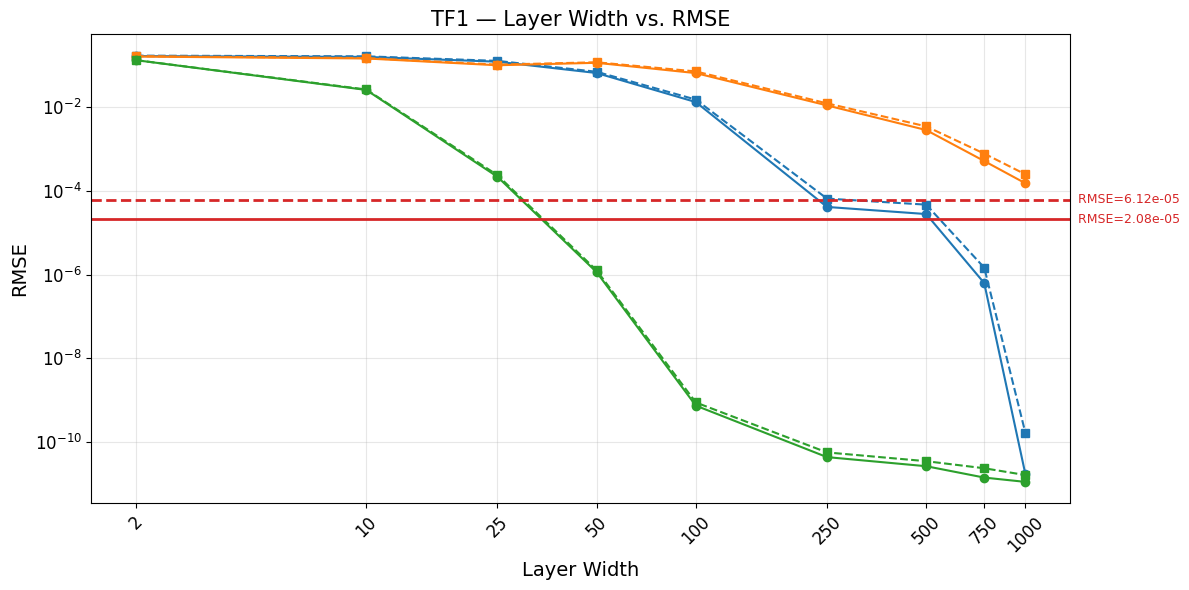

In [8]:
visualize.plot_hypothesis_1_results(
    tf1_hypothesis_1_results_df,
    kan_best_train_rmse=tf1_kan_summary['train_rmse_median'],
    kan_best_test_rmse=tf1_kan_summary['test_rmse_median'],
    title="TF1 — Layer Width vs. RMSE",
    show_legend=False
)

### Hypothesis 2

Increasing layer width (other parameters constant) vs. training time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [9]:
tf1_hypothesis_2_path = "data/tf1_hypothesis_2_results_df.csv"

if os.path.exists(tf1_hypothesis_2_path):
    tf1_hypothesis_2_results_df = pd.read_csv(tf1_hypothesis_2_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    timing = {
        'sgkan_swim': [],
        'sgkan_random': [],
        'hkan': [],
    }

    print("Timing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_sgkan_configs]
        config[0]['layer_width'] = width
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_swim'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_random'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf1_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        start = time.perf_counter()
        utils.fit_hkan(model, tf1_x_train, tf1_y_train)
        fit_time = time.perf_counter() - start
        timing['hkan'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    tf1_hypothesis_2_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_fit_time': timing['sgkan_swim'],
        'sgkan_random_fit_time': timing['sgkan_random'],
        'hkan_fit_time': timing['hkan'],
    })
    tf1_hypothesis_2_results_df.to_csv(tf1_hypothesis_2_path, index=False)

tf1_hypothesis_2_results_df

,layer_width,sgkan_swim_fit_time,sgkan_random_fit_time,hkan_fit_time
0,2,0.156107917,0.034679208,0.006127625
1,10,0.200412875,0.156001583,0.047153250
2,25,0.717154000,0.493344125,0.113502542
3,50,1.087079000,0.914436709,0.208766834
4,100,2.088471625,1.700737666,0.387985041
5,250,4.978554209,4.236557458,1.012829541
6,500,15.653216750,8.183038000,2.827044791
7,750,13.398740625,15.762823959,2.833465083
8,1000,19.042641000,16.924963875,4.028602167


[plot_hypothesis_2_results] saved to static/TF1_Layer_Width_vs_Training_Time_s.png


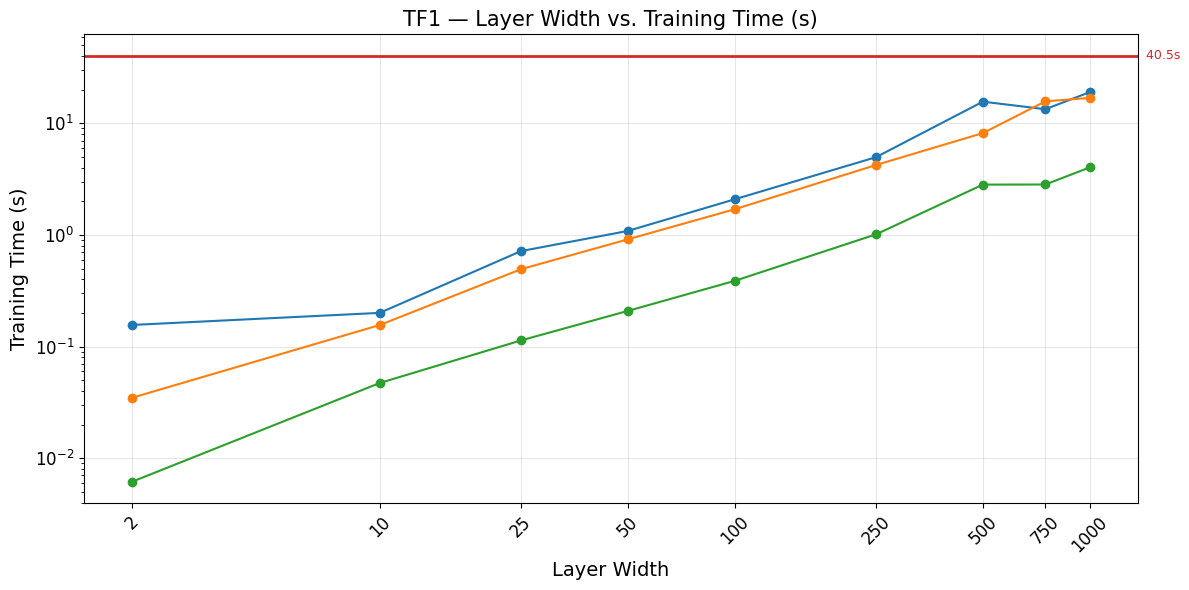

In [10]:
visualize.plot_hypothesis_2_results(
    tf1_hypothesis_2_results_df,
    kan_fit_time=tf1_kan_summary['fit_time_median'],
    title="TF1 — Layer Width vs. Training Time (s)",
    show_legend=False
)

### Hypothesis 3

Increasing layer width (other parameters constant) vs. inference time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [11]:
tf1_hypothesis_3_path = "data/tf1_hypothesis_3_results_df.csv"

if os.path.exists(tf1_hypothesis_3_path):
    tf1_hypothesis_3_results_df = pd.read_csv(tf1_hypothesis_3_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    inf_times = {
        'sgkan_swim': {'train': [], 'test': []},
        'sgkan_random': {'train': [], 'test': []},
        'hkan': {'train': [], 'test': []},
    }

    print("Measuring SGKAN SWIM inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        inf_times['sgkan_swim']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_swim']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring SGKAN Random inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        inf_times['sgkan_random']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_random']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring HKAN inference time...")
    for width in layer_widths:
        config = [c.copy() for c in tf1_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        inf_times['hkan']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['hkan']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    tf1_hypothesis_3_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_inf_time': inf_times['sgkan_swim']['train'],
        'sgkan_swim_test_inf_time': inf_times['sgkan_swim']['test'],
        'sgkan_random_train_inf_time': inf_times['sgkan_random']['train'],
        'sgkan_random_test_inf_time': inf_times['sgkan_random']['test'],
        'hkan_train_inf_time': inf_times['hkan']['train'],
        'hkan_test_inf_time': inf_times['hkan']['test'],
    })
    tf1_hypothesis_3_results_df.to_csv(tf1_hypothesis_3_path, index=False)

tf1_hypothesis_3_results_df

,layer_width,sgkan_swim_train_inf_time,sgkan_swim_test_inf_time,sgkan_random_train_inf_time,sgkan_random_test_inf_time,hkan_train_inf_time,hkan_test_inf_time
0,2,0.012112416,0.037117708,0.012615542,0.023832167,0.005914000,0.002414584
1,10,0.105605959,0.163168750,0.081720083,0.181789333,0.022669417,0.023676792
2,25,0.239531833,0.404911000,0.181347541,0.286451166,0.030790334,0.055490709
3,50,0.440873583,0.779449250,0.422045334,0.722956875,0.052267625,0.097488375
4,100,1.141752042,1.821554833,0.660459875,1.582958167,0.138344333,0.222666125
5,250,2.074892209,3.758491917,1.934133334,3.705340167,0.268808416,0.478019834
6,500,3.817871750,7.609099333,3.151256292,6.219828291,0.583226417,1.137689291
7,750,5.363752959,10.912191375,5.447199000,11.024518958,1.061766333,2.220959500
8,1000,7.033690625,15.241847666,6.748723625,14.239231500,1.173504750,2.840995625


[plot_hypothesis_3_results] saved to static/TF1_Layer_Width_vs_Inference_Time_s.png


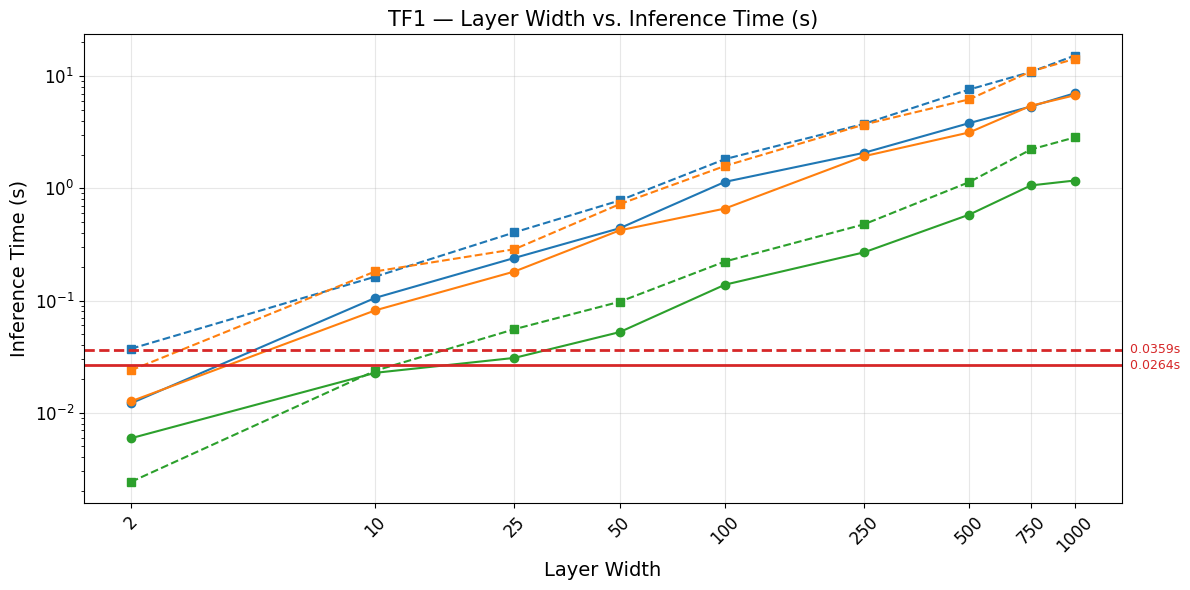

In [12]:
visualize.plot_hypothesis_3_results(
    tf1_hypothesis_3_results_df,
    kan_train_inference_time=tf1_kan_summary['train_inference_time_median'],
    kan_test_inference_time=tf1_kan_summary['test_inference_time_median'],
    title="TF1 — Layer Width vs. Inference Time (s)",
    show_legend=False
)

## TF2

### SG-KAN

In [31]:
# Find best parameter configuration
tf2_sgkan_result = sps.study_optuna_sgkan(
    "tf2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test,
    n_trials=375
)

# Use best parameter configuration to fit an SGKAN model again
best_tf2_sgkan_configs = tf2_sgkan_result["layer_configs"]
best_tf2_sgkan_configs

Results found for tf2. Loading from data/tf2_sgkan_optuna_search.csv
Best Validation RMSE:   0.121401919822631
Best Test RMSE:          0.069466691865074
Best layer_width:        250
Best num_inducing:       10
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number           value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type        val_rmse     test_rmse
0         0    0.1341706757                1000                   50              0.001                    0             matern    0.1341706757           NaN
1         1    0.1690794742                1000                   25              1.000                    0           periodic    0.1690794742           NaN
2         2    0.1286880126                 500                   50             10.000                    0                rbf    0.1286880126           NaN
3         3    0.1301444605              

[{'layer_width': 250,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [32]:
tf2_sgkan_optuna_df = pd.read_csv("data/tf2_sgkan_optuna_search.csv")
tf2_sgkan_optuna_df.sort_values("val_rmse").head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
50,50,0.1214019198,2026-08-06 18:54:32.364016,2026-08-06 18:54:33.499482,1.135466,1.000,0,rbf,250,10,...,1.052490375,rbf,250,10,1,0.1214019198,50,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0694666919
113,113,0.1216280767,2026-08-06 19:07:10.253905,2026-08-06 19:07:11.311886,1.057981,0.100,0,rbf,250,10,...,0.959779833,rbf,250,10,1,0.1216280767,113,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
316,316,0.1219895807,2026-08-06 19:43:01.154879,2026-08-06 19:43:02.466117,1.311238,0.001,0,matern,250,10,...,1.109804250,matern,250,10,1,0.1219895807,316,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
276,276,0.1225866840,2026-08-06 19:34:34.476535,2026-08-06 19:34:44.303424,9.826889,0.100,0,matern,500,50,...,8.990966625,matern,500,50,1,0.1225866840,276,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
41,41,0.1227289119,2026-08-06 18:52:49.025630,2026-08-06 18:52:51.341801,2.316171,10.000,0,rbf,250,25,...,2.151501833,rbf,250,25,1,0.1227289119,41,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
303,303,0.1233063567,2026-08-06 19:40:55.575642,2026-08-06 19:41:03.581205,8.005563,0.001,0,rbf,250,100,...,7.431112500,rbf,250,100,1,0.1233063567,303,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
237,237,0.1233188691,2026-08-06 19:28:32.486945,2026-08-06 19:28:37.905749,5.418804,0.001,0,matern,250,50,...,4.935220709,matern,250,50,1,0.1233188691,237,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
149,149,0.1235018644,2026-08-06 19:12:05.574241,2026-08-06 19:12:13.033998,7.459757,0.001,0,matern,250,75,...,6.900353708,matern,250,75,1,0.1235018644,149,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
230,230,0.1235203927,2026-08-06 19:27:08.930068,2026-08-06 19:27:15.581994,6.651926,1.000,0,rbf,250,75,...,6.058089542,rbf,250,75,1,0.1235203927,230,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
186,186,0.1235904685,2026-08-06 19:18:29.525190,2026-08-06 19:18:40.056562,10.531372,1.000,0,matern,250,100,...,9.586591167,matern,250,100,1,0.1235904685,186,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [33]:
# Calculate training time
start = time.perf_counter()
best_tf2_sgkan_model = sgkan_model.SGKANModel(best_tf2_sgkan_configs).fit(tf2_x_train, tf2_y_train)
fit_time = time.perf_counter() - start
print("SWIM Training time: ", fit_time)

best_tf2_sgkan_results = em.evaluate(
    best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(best_tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 281, 'interval': 215, 'knn_fallback': 4}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 166, 'interval_capped': 84}
[SGKANModel.fit] Total fit duration: 1.2961s
SWIM Training time:  1.2962005420013156
Metric          Train                Test                
-------------------------------------------------------
MAE             1.067455e-01         5.087396e-02        
RMSE            1.275607e-01         6.946669e-02        
-------------------------------------------------------
Inference (s)   0.390112             0.712837            


In [34]:
# SWIM (Random) ablation
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf2_sgkan_configs = copy.deepcopy(best_tf2_sgkan_configs)
for i in random_best_tf2_sgkan_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf2_sgkan_configs, best_tf2_sgkan_configs

([{'layer_width': 250,
   'num_inducing': 10,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 10,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 250,
   'num_inducing': 10,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 10,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [35]:
# Calculate training time
start = time.perf_counter()
random_best_tf2_sgkan_model = sgkan_model.SGKANModel(random_best_tf2_sgkan_configs).fit(tf2_x_train, tf2_y_train)
fit_time = time.perf_counter() - start
print("SWIM(Random) Training time: ", fit_time)

random_best_tf2_sgkan_results = em.evaluate(
    random_best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(random_best_tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 306, 'interval': 193, 'knn_fallback': 1}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 229, 'knn_fallback': 21}
[SGKANModel.fit] Total fit duration: 1.1517s
SWIM(Random) Training time:  1.1518176250010583
Metric          Train                Test                
-------------------------------------------------------
MAE             1.098720e-01         6.039654e-02        
RMSE            1.320654e-01         8.338002e-02        
-------------------------------------------------------
Inference (s)   0.323478             0.701234            


#### 50 Seed Results

In [36]:
tf2_sgkan_50_runs_path = "data/tf2_sgkan_50_run_results.csv"

# Load cached results if they exist
if os.path.exists(tf2_sgkan_50_runs_path):
    tf2_sgkan_50_runs_df = pd.read_csv("data/tf2_sgkan_50_run_results.csv")
else:
    tf2_sgkan_50_runs = utils.run_sgkan_seed_experiments(tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, best_tf2_sgkan_configs, n_runs=50)
    tf2_sgkan_50_runs_df = utils.create_export_seed_results(tf2_sgkan_50_runs, "tf2_sgkan_50_run_results")

tf2_sgkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.1067454811,0.1275607046,0.527055166,0.0508739642,0.0694666919,0.995550125,1.770554000
1,1,0.1045831408,0.1239307342,0.799231167,0.0425268903,0.0600911949,0.933778084,1.635135458
2,2,0.1001727244,0.1169034136,0.540986792,0.0305358252,0.0407585599,0.729477333,1.823336000
3,3,0.1084668558,0.1309656356,0.488427959,0.0557595407,0.0756283244,0.867066584,1.420972292
4,4,0.1048370478,0.1253916277,0.494532417,0.0489197713,0.0646528312,0.775636333,1.236275458
5,5,0.1006834138,0.1183207145,0.413290625,0.0351806206,0.0465550869,0.802927042,1.294591375
6,6,0.1088875453,0.1314727094,0.338553833,0.0576049089,0.0766040646,0.780774125,1.118958250
7,7,0.0998404291,0.1167363485,0.413157458,0.0289328725,0.0379627927,0.862438667,1.340270416
8,8,0.0995261263,0.1157272762,0.343454542,0.0278327197,0.0366554233,0.697228042,1.493746667
9,9,0.0996780894,0.1164949888,0.355673125,0.0299488827,0.0401342551,0.700083291,1.280281250


In [37]:
tf2_sgkan_summary = utils.summarize_metrics(tf2_sgkan_50_runs_df, "TF2 SGKAN")
tf2_sgkan_summary

{'model': 'TF2 SGKAN',
 'train_rmse_median': 0.11875063275247025,
 'train_rmse_iqr': 0.010023946168560713,
 'test_rmse_median': 0.04967918844018455,
 'test_rmse_iqr': 0.025488867369778387,
 'train_inference_time_median': 0.4340279795069364,
 'train_inference_time_iqr': 0.12204958325310145,
 'test_inference_time_median': 0.8791700204965309,
 'test_inference_time_iqr': 0.1999741565050499,
 'fit_time_median': 1.5838366039970424,
 'fit_time_iqr': 0.4095950205010013}

#### Explore Feature Importances and Layers

In [38]:
best_tf2_sgkan_stages, best_tf2_sgkan_ytrain_hat, best_tf2_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf2_x_train, tf2_y_train, best_tf2_sgkan_configs)

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 281, 'interval': 215, 'knn_fallback': 4}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 166, 'interval_capped': 84}


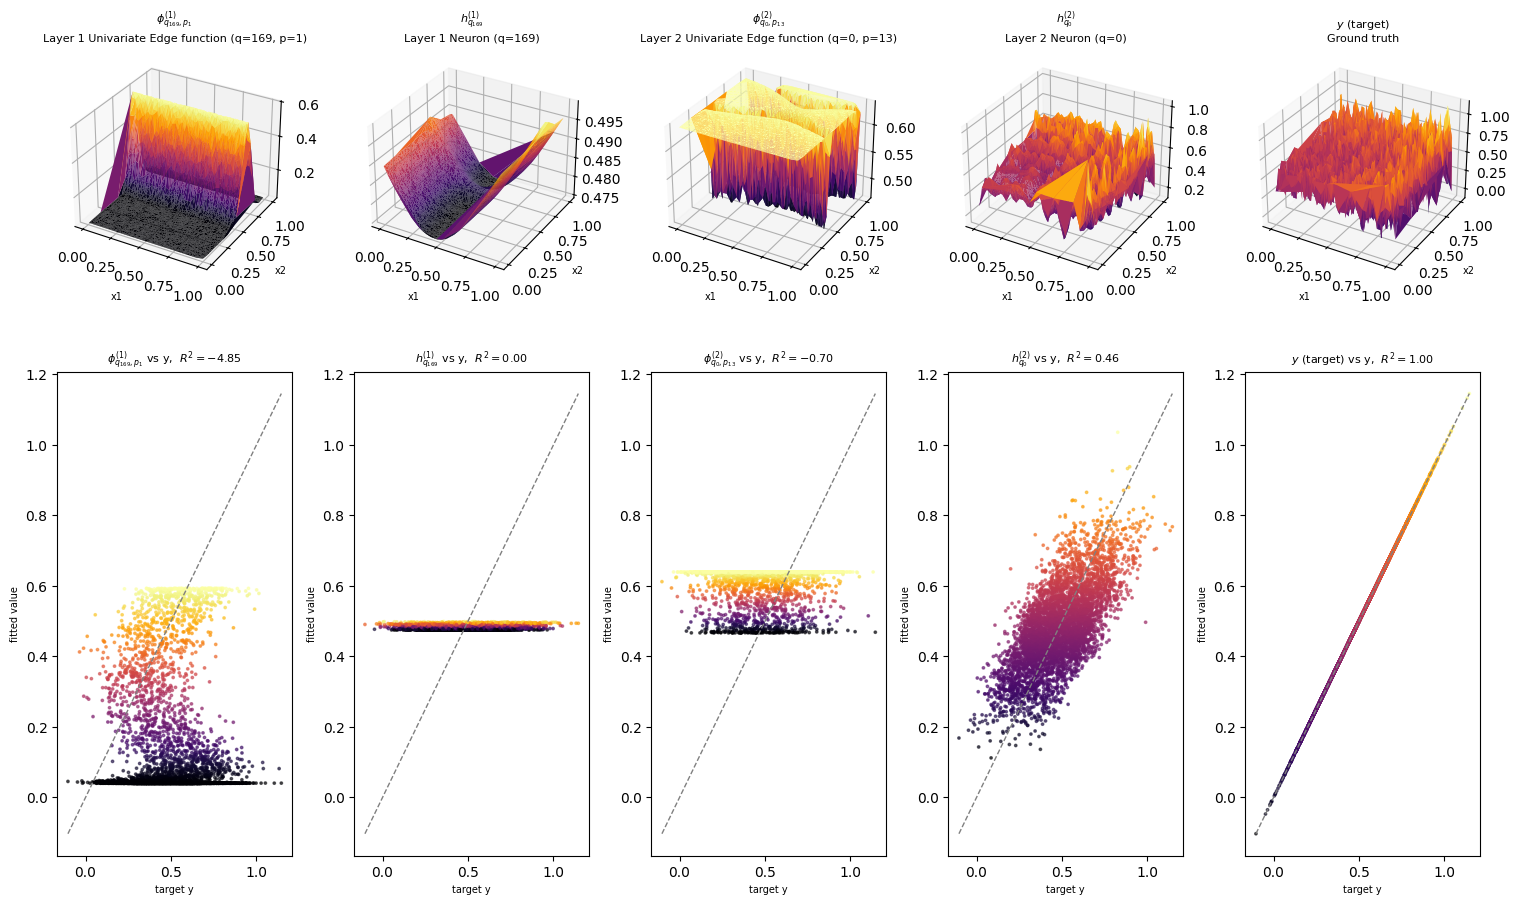

In [39]:
visualize.plot_model_stages(tf2_x_train, tf2_y_train, best_tf2_sgkan_stages, block_idx="random")

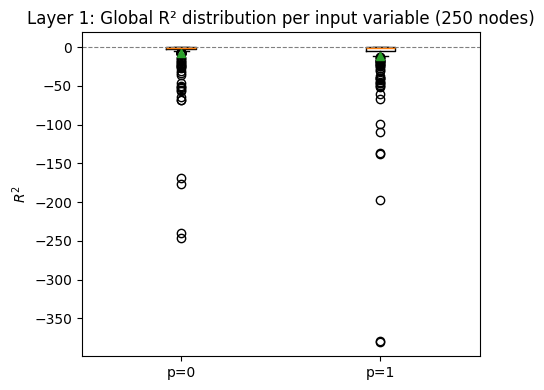

In [40]:
# Global
visualize.plot_first_layer_featurewise_r2_summary(best_tf2_sgkan_stages, tf2_y_train)

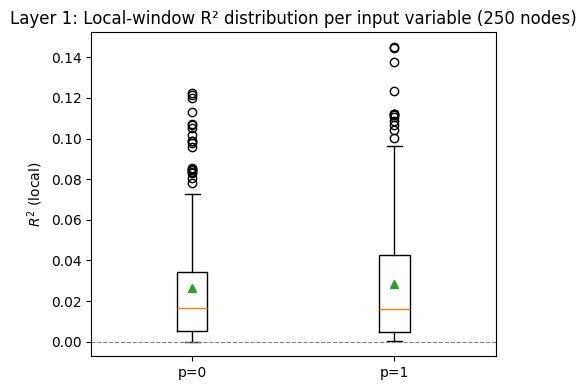

In [41]:
# Local
visualize.plot_first_layer_local_edge_r2_summary(best_tf2_sgkan_layer_neurons)

### HKAN

Layer: 0


Fitting connecting regressors: 100%|██████████| 48/48 [00:00<00:00, 2215.76it/s]


Layer: 1


Fitting connecting regressors: 100%|██████████| 11/11 [00:00<00:00, 142.75it/s]


Layer: 2


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 574.64it/s]


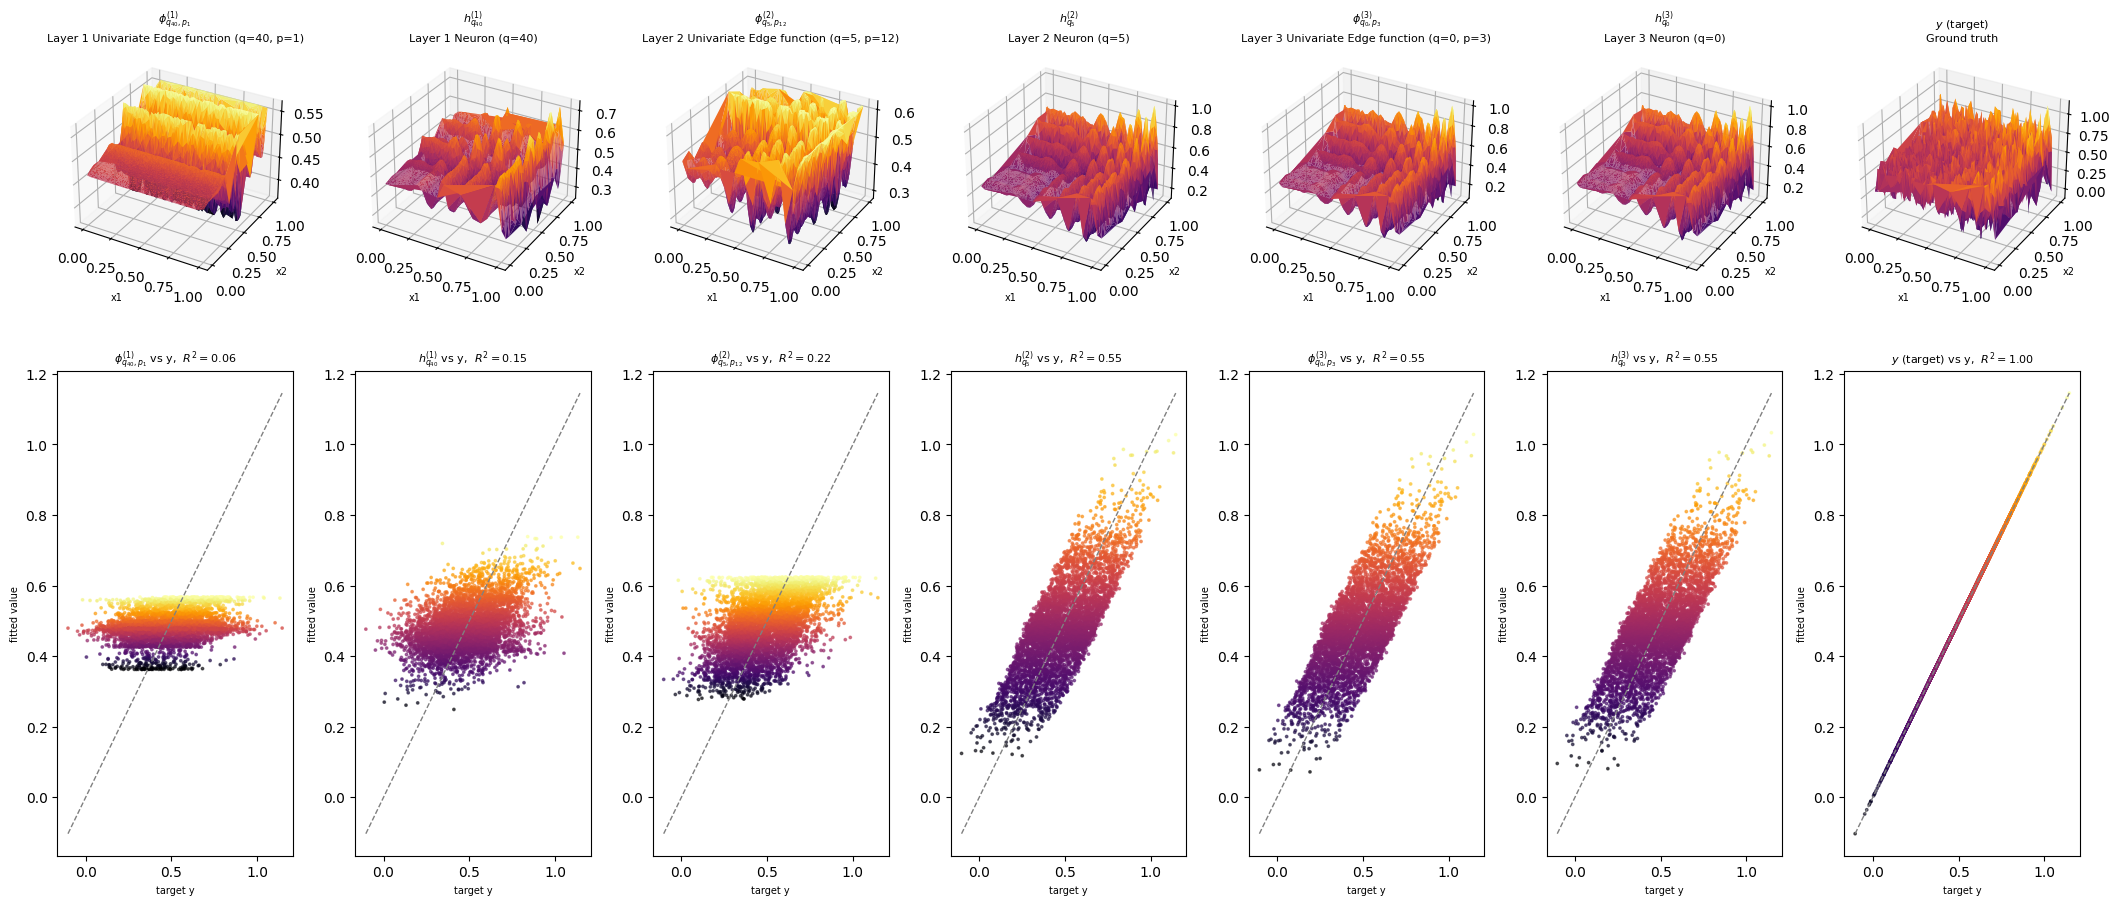

In [42]:
# Best TF2 HKAN configuration from the paper
tf2_hkan_layer_configs = [
    dict(layer=0, n_vars_out=48, n_basis=17, centers="random", basis_fn=Tanh(s=22), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=11, n_basis=21, centers="random_data_points", basis_fn=Softplus(s=18), expanding_base_regressor=Ridge(alpha=1)),
    dict(layer=2, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

tf2_hkan_stages, tf2_ytrain_hat = utils.stack_hkan_layers(tf2_x_train, tf2_y_train, tf2_hkan_layer_configs)
visualize.plot_model_stages(tf2_x_train, tf2_y_train, tf2_hkan_stages, block_idx="random", seed=0)

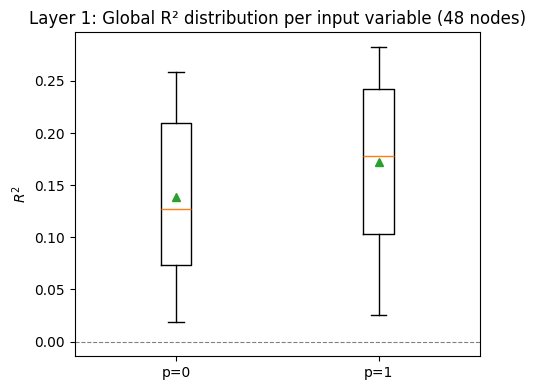

In [43]:
visualize.plot_first_layer_featurewise_r2_summary(tf2_hkan_stages, tf2_y_train)

In [44]:
tf2_hkan_model = utils.build_hkan_model_from_configs(tf2_hkan_layer_configs)
utils.fit_hkan(tf2_hkan_model, tf2_x_train, tf2_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 559.61it/s]


✓ HKAN training completed in 2.0364 seconds


In [45]:
tf2_hkan_results = em.evaluate(tf2_hkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
em.print_results(tf2_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             1.004584e-01         1.345950e-02        
RMSE            1.160501e-01         1.766525e-02        
-------------------------------------------------------
Inference (s)   0.890084             1.545122            


In [46]:
tf2_hkan_50_runs_path = "data/tf2_hkan_50_run_results.csv"

# Load cached results if they exist
if os.path.exists(tf2_hkan_50_runs_path):
    tf2_hkan_50_runs_df = pd.read_csv("data/tf2_hkan_50_run_results.csv")
else:
    tf2_hkan_50_runs = utils.run_hkan_seed_experiments(tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, tf2_hkan_layer_configs, n_runs=50)
    tf2_hkan_50_runs_df = utils.create_export_seed_results(tf2_hkan_50_runs, "tf2_hkan_50_run_results")

tf2_hkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.1007103548,0.1161689696,1.153364083,0.0118286218,0.0157400720,1.848437833,2.460392667
1,1,0.1008491801,0.1163143165,0.873786917,0.0119586005,0.0157926298,1.758865666,2.274593417
2,2,0.1007035853,0.1161427635,0.934053333,0.0117463480,0.0155481191,1.704971334,2.325285125
3,3,0.1006609226,0.1161412944,2.365836083,0.0123593735,0.0159422312,1.944340833,2.422836875
4,4,0.1007811447,0.1163541062,1.251333750,0.0121881564,0.0160424527,2.092996042,2.679714708
5,5,0.1004939115,0.1160429016,1.140541417,0.0133912793,0.0168401839,1.883756208,2.449206292
6,6,0.1006908528,0.1161529955,0.996975958,0.0127610790,0.0163453939,2.237369666,2.396850250
7,7,0.1008919749,0.1163925160,1.053578584,0.0133576328,0.0173893939,1.929315250,2.246247833
8,8,0.1007609079,0.1162671809,0.958760625,0.0125033530,0.0164096951,1.833811542,2.522214583
9,9,0.1008793759,0.1163387406,1.001833708,0.0126776347,0.0167458334,2.190573791,2.307048458


In [47]:
tf2_hkan_summary = utils.summarize_metrics(tf2_hkan_50_runs_df, "TF2 HKAN")
tf2_hkan_summary

{'model': 'TF2 HKAN',
 'train_rmse_median': 0.1162740277033517,
 'train_rmse_iqr': 0.0001500757657232482,
 'test_rmse_median': 0.01646540377539695,
 'test_rmse_iqr': 0.0011648351390373991,
 'train_inference_time_median': 0.9998593959971913,
 'train_inference_time_iqr': 0.16985506250784965,
 'test_inference_time_median': 1.870029791498382,
 'test_inference_time_iqr': 0.21200649975071428,
 'fit_time_median': 2.3788757500005886,
 'fit_time_iqr': 0.25390571825118924}

### KAN

In [48]:
tf2_kan_study = utils.study_optuna_kan("TF2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
tf2_kan_best_architecture = tf2_kan_study["architecture"]
tf2_kan_best_architecture

Results found for TF2. Loading from data/tf2_kan_optuna_search.csv
Best Validation RMSE:   0.121191
Best architecture:       [2, 1]

All 10 trials:
   number  params_width_idx user_attrs_architecture  user_attrs_val_rmse user_attrs_grids  user_attrs_steps_per_grid user_attrs_opt  user_attrs_lamb   duration
0       0                 8            [2, 5, 3, 1]         0.1367654853      (5, 10, 20)                         20          LBFGS                0  46.860391
1       1                 1               [2, 2, 1]         0.1326470408      (5, 10, 20)                         20          LBFGS                0  22.404810
2       2                 5            [2, 3, 2, 1]         0.1368387172      (5, 10, 20)                         20          LBFGS                0  38.084372
3       3                 0                  [2, 1]         0.1211914816      (5, 10, 20)                         20          LBFGS                0  10.169629
4       4                 7            [2, 3, 3, 1] 

[2, 1]

In [49]:
# Calculate training time
start = time.perf_counter()
model = utils.build_kan(width=tf2_kan_best_architecture, grid=3, k=3, seed=42)
model = utils.fit_kan_with_grid_extension(
    model,
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test,
    grids=(5, 10, 20), steps_per_grid=20, opt="LBFGS", lamb=0,
)
fit_time = time.perf_counter() - start
print("TF2 KAN Training time: ", fit_time)

tf2_kan_results = em.evaluate(
    utils.KANModel(model),
    tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(tf2_kan_results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 1.73e-01 | test_loss: 1.31e-01 | reg: 1.01e+00 | : 100%|█| 20/20 [00:02<00:00,  8.47it


saving model version 0.1
saving model version 0.2


| train_loss: 1.73e-01 | test_loss: 1.31e-01 | reg: 1.04e+00 | : 100%|█| 20/20 [00:02<00:00,  9.03it


saving model version 0.3
saving model version 0.4


| train_loss: 1.61e-01 | test_loss: 1.11e-01 | reg: 2.22e+00 | : 100%|█| 20/20 [00:02<00:00,  7.73it


saving model version 0.5
saving model version 0.6


| train_loss: 1.17e-01 | test_loss: 1.72e-02 | reg: 3.07e+00 | : 100%|█| 20/20 [00:03<00:00,  5.30it


saving model version 0.7

✓ KAN training with grid extension completed in 11.0493 seconds
TF2 KAN Training time:  11.061530292001407
Metric          Train                Test                
-------------------------------------------------------
MAE             1.013665e-01         1.334286e-02        
RMSE            1.170350e-01         1.724687e-02        
-------------------------------------------------------
Inference (s)   0.004841             0.009788            


In [13]:
tf2_kan_50_runs_path = "data/tf2_kan_50_run_results.csv"

# Load cached results if they exist
if os.path.exists(tf2_kan_50_runs_path):
    tf2_kan_50_runs_df = pd.read_csv("data/tf2_kan_50_run_results.csv")
else:
    tf2_kan_50_runs = utils.run_kan_seed_experiments(
        tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test,
        width=tf2_kan_best_architecture,
        grids=(5, 10, 20),
        steps_per_grid=20,
        opt="LBFGS",
        lamb=0,
        n_runs=50
    )
    tf2_kan_50_runs_df = utils.create_export_seed_results(tf2_kan_50_runs, "tf2_kan_50_run_results")

tf2_kan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.1013665327,0.1170349925,0.004391209,0.0133428671,0.0172468810,0.009328708,10.777343208
1,1,0.1013665324,0.1170349925,0.004163292,0.0133428894,0.0172468936,0.009380959,11.134789250
2,2,0.1013665326,0.1170349925,0.004315750,0.0133428661,0.0172468787,0.011261333,10.822056584
3,3,0.1013665326,0.1170349925,0.004176750,0.0133428664,0.0172468784,0.007797792,10.778271583
4,4,0.1013665330,0.1170349925,0.004423334,0.0133428453,0.0172468877,0.009450667,11.603491208
5,5,0.1013665327,0.1170349925,0.003911041,0.0133428688,0.0172468808,0.008346292,11.139054167
6,6,0.1013665325,0.1170349925,0.004426042,0.0133428694,0.0172468861,0.009879750,10.277139125
7,7,0.1013665326,0.1170349925,0.004650458,0.0133428671,0.0172468800,0.009278833,10.700573167
8,8,0.1013665327,0.1170349925,0.004266000,0.0133428666,0.0172468797,0.009772625,10.543302541
9,9,0.1013664145,0.1170349934,0.004281125,0.0133416748,0.0172451926,0.010142542,11.107088542


In [14]:
tf2_kan_summary = utils.summarize_metrics(tf2_kan_50_runs_df, "TF2 KAN")
tf2_kan_summary

{'model': 'TF2 KAN',
 'train_rmse_median': 0.11703499248268764,
 'train_rmse_iqr': 1.4557341443399707e-11,
 'test_rmse_median': 0.01724687965259635,
 'test_rmse_iqr': 6.5409395469395726e-09,
 'train_inference_time_median': 0.0043241669991402505,
 'train_inference_time_iqr': 0.0003421352521400245,
 'test_inference_time_median': 0.0095306250004796,
 'test_inference_time_iqr': 0.0013926667525083758,
 'fit_time_median': 11.076601417000347,
 'fit_time_iqr': 0.5445319477512403}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

In [15]:
tf2_hypothesis_1_path = "data/tf2_hypothesis_1_results_df.csv"

if os.path.exists(tf2_hypothesis_1_path):
    tf2_hypothesis_1_results_df = pd.read_csv(tf2_hypothesis_1_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf2_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    tf2_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf2_hypothesis_1_results_df.to_csv(tf2_hypothesis_1_path, index=False)

tf2_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1735185434,0.1298207615,0.1715255581,0.1271046572,0.1241776520,0.0458912162
1,1,10,0.1726360656,0.1298613835,0.1721432570,0.1283411254,0.1194761976,0.0357336046
2,2,25,0.1629959797,0.1176966456,0.1679469443,0.1241286892,0.1172616217,0.0215248571
3,3,50,0.1599413292,0.1144316878,0.1588630221,0.1149786635,0.1160973718,0.0170770008
4,4,100,0.1427467974,0.0870922740,0.1513077167,0.1059635830,0.1153739197,0.0211762121
5,5,250,0.1275607046,0.0694666919,0.1320654275,0.0833800243,0.1133607505,0.0296479180
6,6,500,0.1135196432,0.0473609853,0.1218654462,0.0838721966,0.1099367299,0.0436140270
7,7,750,0.1069899347,0.0722582727,0.1142505903,0.0975679478,0.1062068916,0.0568130989
8,8,1000,0.1053740007,0.1224873999,0.1129077488,0.1390335385,0.1028984409,0.0690189410


[plot_hypothesis_1_results] saved to static/TF2_Layer_Width_vs_RMSE.png


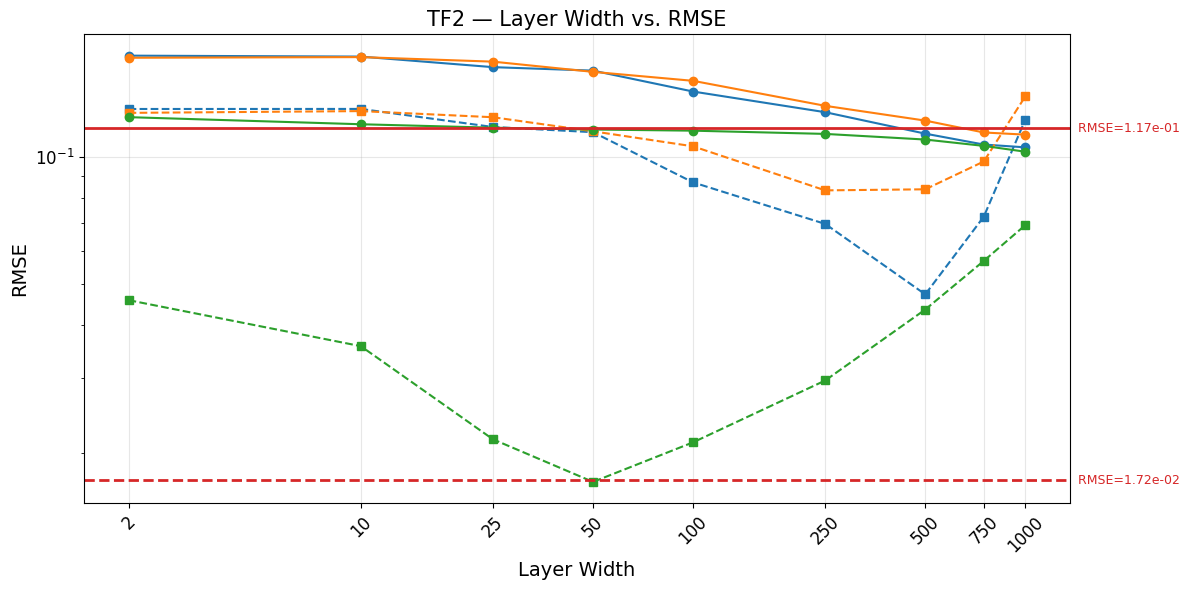

In [16]:
visualize.plot_hypothesis_1_results(
    tf2_hypothesis_1_results_df,
    kan_best_train_rmse=tf2_kan_summary['train_rmse_median'],
    kan_best_test_rmse=tf2_kan_summary['test_rmse_median'],
    title="TF2 — Layer Width vs. RMSE",
    show_legend=False
)

### Hypothesis 2



Increasing layer width (other parameters constant) vs. training time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [17]:
tf2_hypothesis_2_path = "data/tf2_hypothesis_2_results_df.csv"

if os.path.exists(tf2_hypothesis_2_path):
    tf2_hypothesis_2_results_df = pd.read_csv(tf2_hypothesis_2_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    timing = {
        'sgkan_swim': [],
        'sgkan_random': [],
        'hkan': [],
    }

    print("Timing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_sgkan_configs]
        config[0]['layer_width'] = width
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_swim'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_random'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf2_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        start = time.perf_counter()
        utils.fit_hkan(model, tf2_x_train, tf2_y_train)
        fit_time = time.perf_counter() - start
        timing['hkan'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    tf2_hypothesis_2_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_fit_time': timing['sgkan_swim'],
        'sgkan_random_fit_time': timing['sgkan_random'],
        'hkan_fit_time': timing['hkan'],
    })
    tf2_hypothesis_2_results_df.to_csv(tf2_hypothesis_2_path, index=False)

tf2_hypothesis_2_results_df

,layer_width,sgkan_swim_fit_time,sgkan_random_fit_time,hkan_fit_time
0,2,0.052006125,0.012814584,0.098472250
1,10,0.063534208,0.049660167,0.507216583
2,25,0.151322208,0.105025584,1.133421125
3,50,0.222842708,0.326708792,2.786880916
4,100,0.623031791,0.548110291,5.976397250
5,250,1.431658000,1.232278667,12.042511125
6,500,3.010460583,2.922618625,22.210439958
7,750,4.534171875,4.131410833,32.930460083
8,1000,7.150756750,6.277957875,43.266526625


[plot_hypothesis_2_results] saved to static/TF2_Layer_Width_vs_Training_Time_s.png


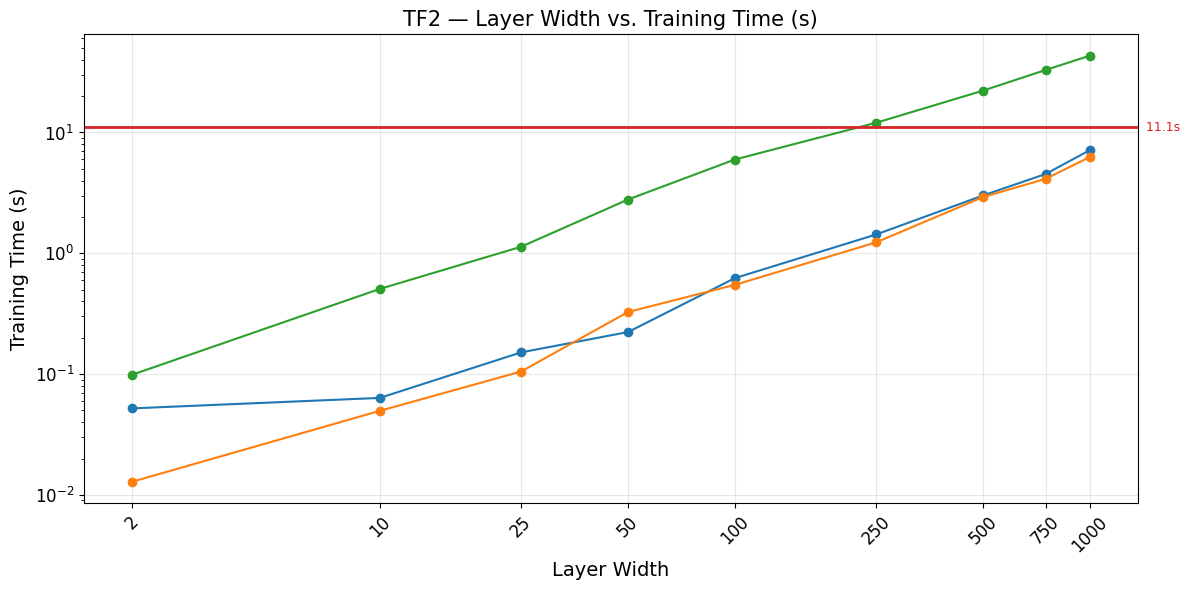

In [18]:
visualize.plot_hypothesis_2_results(
    tf2_hypothesis_2_results_df,
    kan_fit_time=tf2_kan_summary["fit_time_median"],
    title="TF2 — Layer Width vs. Training Time (s)",
    show_legend=False
)

### Hypothesis 3



Increasing layer width (other parameters constant) vs. inference time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [19]:
tf2_hypothesis_3_path = "data/tf2_hypothesis_3_results_df.csv"

if os.path.exists(tf2_hypothesis_3_path):
    tf2_hypothesis_3_results_df = pd.read_csv(tf2_hypothesis_3_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    inf_times = {
        'sgkan_swim': {'train': [], 'test': []},
        'sgkan_random': {'train': [], 'test': []},
        'hkan': {'train': [], 'test': []},
    }

    print("Measuring SGKAN SWIM inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        inf_times['sgkan_swim']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_swim']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring SGKAN Random inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        inf_times['sgkan_random']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_random']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring HKAN inference time...")
    for width in layer_widths:
        config = [c.copy() for c in tf2_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        inf_times['hkan']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['hkan']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    tf2_hypothesis_3_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_inf_time': inf_times['sgkan_swim']['train'],
        'sgkan_swim_test_inf_time': inf_times['sgkan_swim']['test'],
        'sgkan_random_train_inf_time': inf_times['sgkan_random']['train'],
        'sgkan_random_test_inf_time': inf_times['sgkan_random']['test'],
        'hkan_train_inf_time': inf_times['hkan']['train'],
        'hkan_test_inf_time': inf_times['hkan']['test'],
    })
    tf2_hypothesis_3_results_df.to_csv(tf2_hypothesis_3_path, index=False)

tf2_hypothesis_3_results_df

,layer_width,sgkan_swim_train_inf_time,sgkan_swim_test_inf_time,sgkan_random_train_inf_time,sgkan_random_test_inf_time,hkan_train_inf_time,hkan_test_inf_time
0,2,0.004614500,0.004948250,0.001733125,0.012818584,0.035314834,0.054118292
1,10,0.018545917,0.023004000,0.007696417,0.022364834,0.192792583,0.393513791
2,25,0.097020208,0.076970750,0.039826333,0.057851667,0.524506416,0.990580917
3,50,0.170076959,0.197936958,0.061413167,0.131188333,0.893552792,1.772725292
4,100,0.168686084,0.343175041,0.185367917,0.264986541,1.904806208,3.806444541
5,250,0.459642875,0.807416916,0.418505500,0.643049083,4.570713667,9.420592167
6,500,0.949480000,1.601146291,0.719120291,1.317825458,10.255335542,18.878104416
7,750,1.140052125,2.265263958,1.108671542,1.951033000,13.966768000,26.757388709
8,1000,1.386102292,2.486596917,1.417994334,2.437346291,19.414432791,36.399432875


[plot_hypothesis_3_results] saved to static/TF2_Layer_Width_vs_Inference_Time_s.png


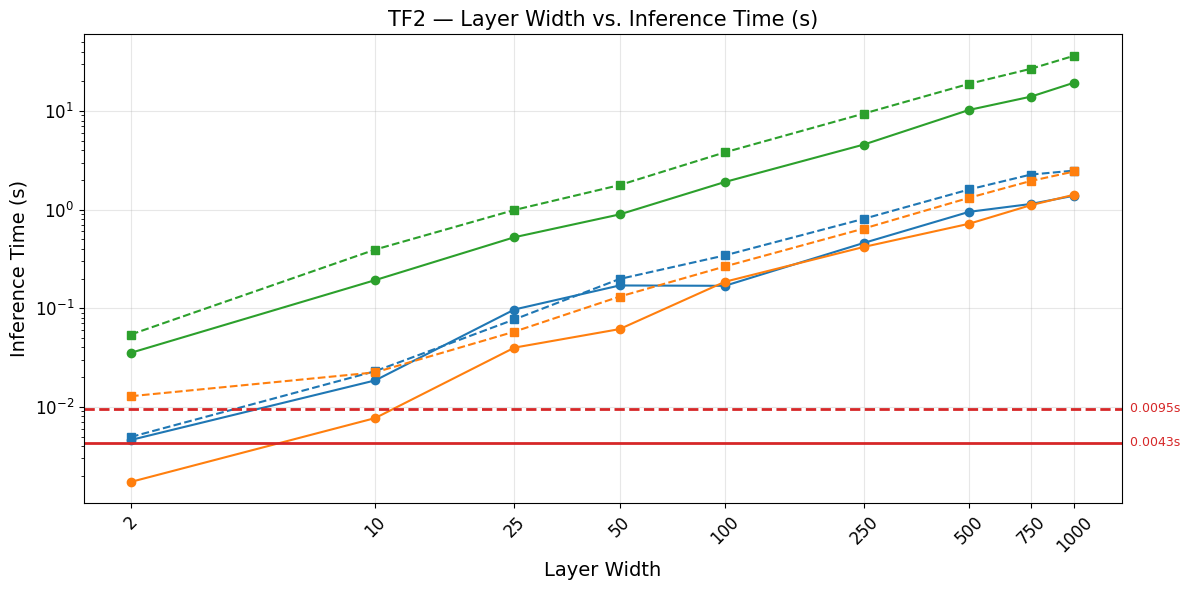

In [20]:
visualize.plot_hypothesis_3_results(
    tf2_hypothesis_3_results_df,
    kan_train_inference_time=tf2_kan_summary['train_inference_time_median'],
    kan_test_inference_time=tf2_kan_summary['test_inference_time_median'],
    title="TF2 — Layer Width vs. Inference Time (s)",
    show_legend=False
)

## TF3

### SG-KAN

In [58]:
# Find best parameter configuration
tf3_sgkan_result = sps.study_optuna_sgkan(
    "tf3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test,
    n_trials=375
)

# Use best parameter configuration to fit an SGKAN model again
best_tf3_sgkan_configs = tf3_sgkan_result["layer_configs"]
best_tf3_sgkan_configs

Results found for tf3. Loading from data/tf3_sgkan_optuna_search.csv
Best Validation RMSE:   0.001775376543405
Best Test RMSE:          0.001930666056172
Best layer_width:        1000
Best num_inducing:       10
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        matern

All 375 trials:
     number         value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type      val_rmse     test_rmse
0         0  0.0022323076                1000                   50              0.001                    0             matern  0.0022323076           NaN
1         1  0.0250078299                1000                   25              1.000                    0           periodic  0.0250078299           NaN
2         2  0.0053409934                 500                   50             10.000                    0                rbf  0.0053409934           NaN
3         3  0.0260327840                 500        

[{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1}]

In [59]:
tf3_sgkan_optuna_df = pd.read_csv("data/tf3_sgkan_optuna_search.csv")
tf3_sgkan_optuna_df.sort_values("val_rmse").head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
67,67,0.0017753765,2026-08-06 20:23:20.566744,2026-08-06 20:23:26.234101,5.667357,1.000,0,matern,1000,10,...,5.355064542,matern,1000,10,1,0.0017753765,67,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0019306661
249,249,0.0018877609,2026-08-06 20:55:24.536475,2026-08-06 20:55:35.458627,10.922152,10.000,0,matern,1000,25,...,10.091062208,matern,1000,25,1,0.0018877609,249,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
334,334,0.0019053303,2026-08-06 21:10:27.816179,2026-08-06 21:10:49.045305,21.229126,10.000,0,matern,1000,50,...,19.464694583,matern,1000,50,1,0.0019053303,334,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
233,233,0.0019149387,2026-08-06 20:52:48.526262,2026-08-06 20:53:21.355434,32.829172,10.000,0,matern,1000,75,...,30.349246417,matern,1000,75,1,0.0019149387,233,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
304,304,0.0019795121,2026-08-06 21:06:13.817630,2026-08-06 21:06:24.470728,10.653098,0.001,0,matern,1000,25,...,9.758293000,matern,1000,25,1,0.0019795121,304,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
317,317,0.0019863965,2026-08-06 21:08:09.493294,2026-08-06 21:08:39.466108,29.972814,1.000,0,matern,1000,75,...,27.628334208,matern,1000,75,1,0.0019863965,317,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
55,55,0.0020292949,2026-08-06 20:20:32.619973,2026-08-06 20:20:52.549542,19.929569,1.000,0,matern,1000,50,...,18.155829667,matern,1000,50,1,0.0020292949,55,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
287,287,0.0020837467,2026-08-06 21:02:24.551335,2026-08-06 21:02:30.048476,5.497141,0.001,0,rbf,1000,10,...,5.078066042,rbf,1000,10,1,0.0020837467,287,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
69,69,0.0021229437,2026-08-06 20:23:37.769235,2026-08-06 20:23:47.302647,9.533412,1.000,0,rbf,1000,25,...,8.873059250,rbf,1000,25,1,0.0021229437,69,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
95,95,0.0021276793,2026-08-06 20:28:59.854633,2026-08-06 20:29:43.196766,43.342133,10.000,0,matern,1000,100,...,39.984610041,matern,1000,100,1,0.0021276793,95,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [60]:
# Calculate training time
start = time.perf_counter()
best_tf3_sgkan_model = sgkan_model.SGKANModel(best_tf3_sgkan_configs).fit(tf3_x_train, tf3_y_train)
fit_time = time.perf_counter() - start
print("SWIM Training time: ", fit_time)

best_tf3_sgkan_results = em.evaluate(
    best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(best_tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval': 934, 'interval_capped': 1063, 'knn_fallback': 3}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 782, 'interval': 216, 'knn_fallback': 2}
[SGKANModel.fit] Total fit duration: 7.6373s
SWIM Training time:  7.638885374999518
Metric          Train                Test                
-------------------------------------------------------
MAE             8.276107e-04         1.145522e-03        
RMSE            1.273151e-03         1.930666e-03        
-------------------------------------------------------
Inference (s)   2.969302             4.778043            


In [61]:
# SWIM (Random) ablation
random_best_tf3_sgkan_configs = copy.deepcopy(best_tf3_sgkan_configs)
for i in random_best_tf3_sgkan_configs:
    i['pair_selection_strategy'] = "random"

# Calculate training time
start = time.perf_counter()
random_best_tf3_sgkan_model = sgkan_model.SGKANModel(random_best_tf3_sgkan_configs).fit(tf3_x_train, tf3_y_train)
fit_time = time.perf_counter() - start
print("SWIM(Random) Training time: ", fit_time)

random_best_tf3_sgkan_results = em.evaluate(
    random_best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(random_best_tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1293, 'interval': 699, 'knn_fallback': 8}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 241, 'interval_capped': 756, 'knn_fallback': 3}
[SGKANModel.fit] Total fit duration: 6.7547s
SWIM(Random) Training time:  6.754837582999244
Metric          Train                Test                
-------------------------------------------------------
MAE             9.423248e-04         1.326763e-03        
RMSE            1.383051e-03         2.151302e-03        
-------------------------------------------------------
Inference (s)   2.113901             3.996010            


#### 50 Seed Results

In [62]:
tf3_sgkan_50_runs_path = "data/tf3_sgkan_50_run_results.csv"

if os.path.exists(tf3_sgkan_50_runs_path):
    tf3_sgkan_50_runs_df = pd.read_csv("data/tf3_sgkan_50_run_results.csv")
else:
    tf3_sgkan_50_runs = utils.run_sgkan_seed_experiments(tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, best_tf3_sgkan_configs, n_runs=50)
    tf3_sgkan_50_runs_df = utils.create_export_seed_results(tf3_sgkan_50_runs, "tf3_sgkan_50_run_results")

tf3_sgkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.0008276107,0.0012731508,3.092180917,0.0011455222,0.0019306661,4.897076375,8.718271459
1,1,0.0007600679,0.0011716224,2.924769083,0.0010382195,0.0017159208,4.965946417,8.633034625
2,2,0.0006876672,0.0010050366,3.404666125,0.0009483529,0.0015937336,6.469937208,9.291172583
3,3,0.0011159125,0.0016390068,2.302409000,0.0015551112,0.0025344626,4.531997625,9.041303542
4,4,0.0008622185,0.0012821773,2.450372333,0.0011731901,0.0018590527,4.569258833,8.269956833
5,5,0.0009960514,0.0014906306,2.289483584,0.0013279576,0.0020827064,4.010769541,7.402902209
6,6,0.0009295057,0.0014779318,2.238742375,0.0012383575,0.0020175093,4.250315625,7.080469666
7,7,0.0037745786,0.0048408695,2.186964209,0.0050510834,0.0070082436,3.980147916,7.347792000
8,8,0.0009760117,0.0014938625,2.335252667,0.0012588618,0.0019701630,4.091151500,7.640765791
9,9,0.0008519719,0.0013048748,2.123365166,0.0011477319,0.0018840282,3.976929791,6.425270375


In [63]:
tf3_sgkan_summary = utils.summarize_metrics(tf3_sgkan_50_runs_df, "TF3 SGKAN")
tf3_sgkan_summary

{'model': 'TF3 SGKAN',
 'train_rmse_median': 0.001503473604451,
 'train_rmse_iqr': 0.000466252771429,
 'test_rmse_median': 0.00219818099358665,
 'test_rmse_iqr': 0.00045187259095469997,
 'train_inference_time_median': 2.1232901664989186,
 'train_inference_time_iqr': 0.16846843700113778,
 'test_inference_time_median': 4.014766915999644,
 'test_inference_time_iqr': 0.2756867502539535,
 'fit_time_median': 6.353491166497406,
 'fit_time_iqr': 0.43240395849352353}

#### Explore Feature Importances and Layers

In [64]:
best_tf3_sgkan_stages, best_tf3_sgkan_ytrain_hat, best_tf3_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf3_x_train, tf3_y_train, best_tf3_sgkan_configs)

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval': 934, 'interval_capped': 1063, 'knn_fallback': 3}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 782, 'interval': 216, 'knn_fallback': 2}


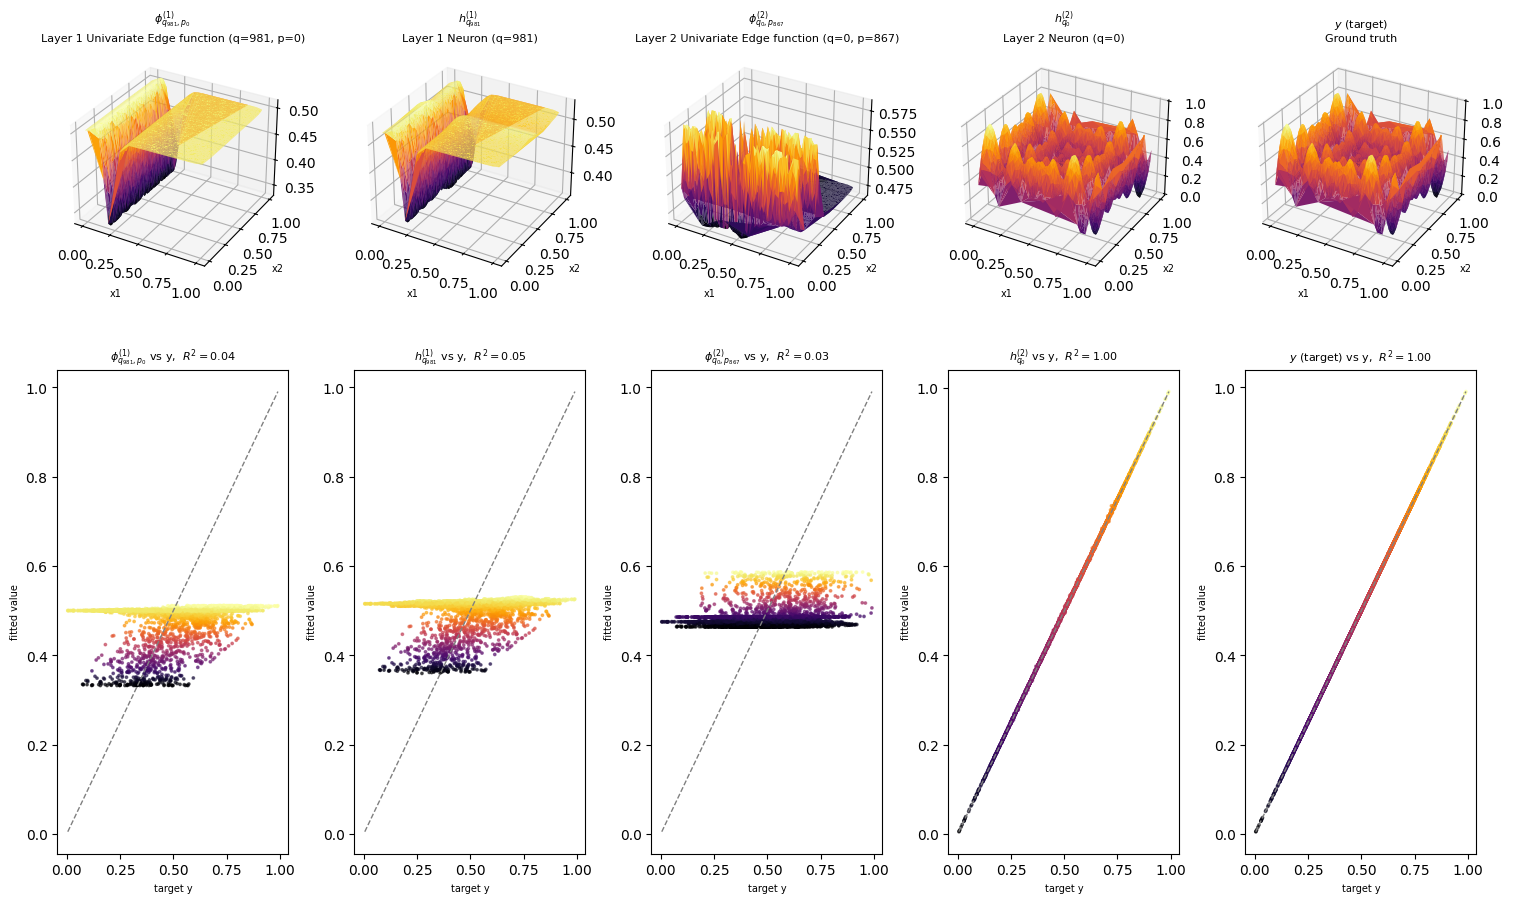

In [65]:
visualize.plot_model_stages(tf3_x_train, tf3_y_train, best_tf3_sgkan_stages, block_idx="random")

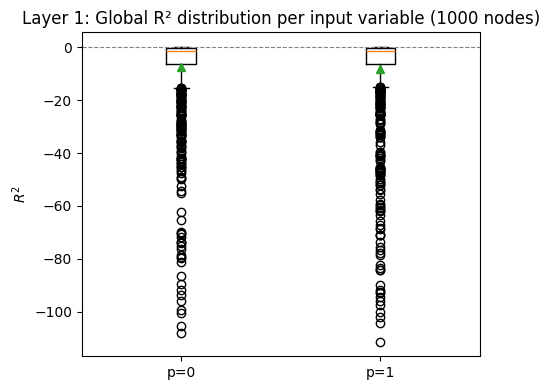

In [66]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf3_sgkan_stages, tf3_y_train)

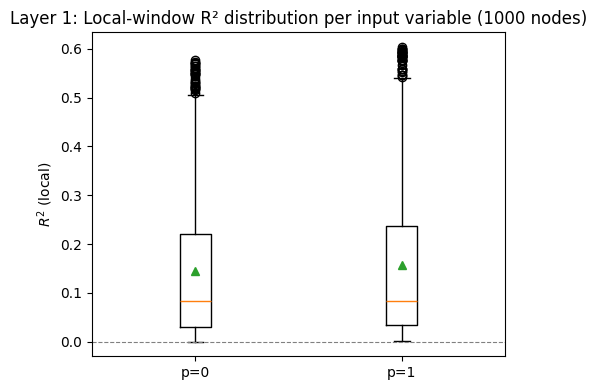

In [67]:
visualize.plot_first_layer_local_edge_r2_summary(best_tf3_sgkan_layer_neurons)

### HKAN

Layer: 0


Fitting connecting regressors: 100%|██████████| 924/924 [00:00<00:00, 2514.13it/s]


Layer: 1


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  4.57it/s]


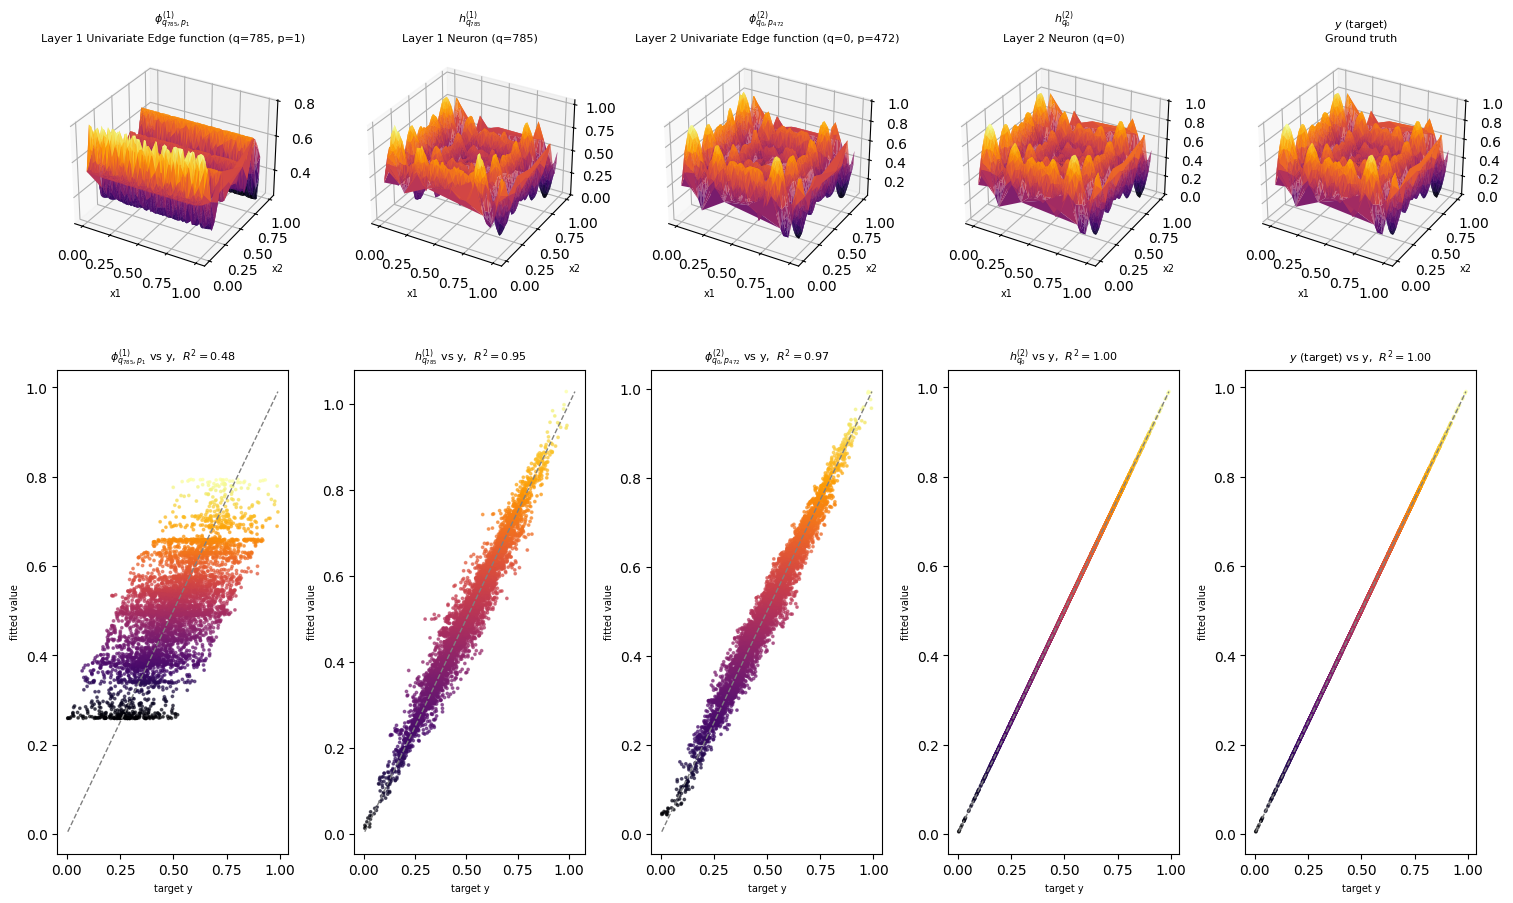

In [68]:
# Best TF3 HKAN configuration
tf3_hkan_layer_configs = [
    dict(layer=0, n_vars_out=924, n_basis=39, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.001)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

tf3_hkan_stages, tf3_ytrain_hat = utils.stack_hkan_layers(tf3_x_train, tf3_y_train, tf3_hkan_layer_configs)
visualize.plot_model_stages(tf3_x_train, tf3_y_train, tf3_hkan_stages, block_idx="random", seed=0)

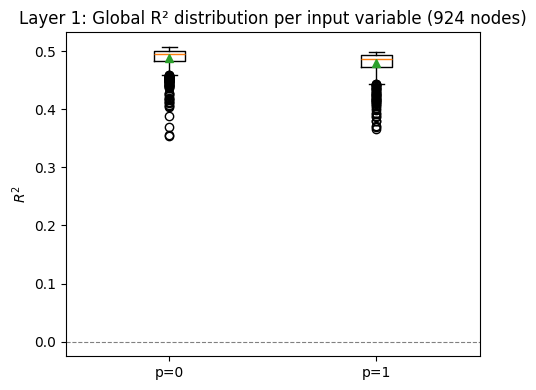

In [69]:
visualize.plot_first_layer_featurewise_r2_summary(tf3_hkan_stages, tf3_y_train)

In [70]:
tf3_hkan_model = utils.build_hkan_model_from_configs(tf3_hkan_layer_configs)
utils.fit_hkan(tf3_hkan_model, tf3_x_train, tf3_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  4.74it/s]


✓ HKAN training completed in 10.8062 seconds


In [71]:
tf3_hkan_results = em.evaluate(tf3_hkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
em.print_results(tf3_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             3.726122e-06         3.733643e-06        
RMSE            9.293242e-06         6.046572e-06        
-------------------------------------------------------
Inference (s)   2.991461             6.360174            


In [72]:
tf3_hkan_50_runs_path = "data/tf3_hkan_50_run_results.csv"
if os.path.exists(tf3_hkan_50_runs_path):
    tf3_hkan_50_runs_df = pd.read_csv("data/tf3_hkan_50_run_results.csv")
else:
    tf3_hkan_50_runs = utils.run_hkan_seed_experiments(tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, tf3_hkan_layer_configs, n_runs=50)
    tf3_hkan_50_runs_df = utils.create_export_seed_results(tf3_hkan_50_runs, "tf3_hkan_50_run_results")

tf3_hkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.0000037369,0.0000092488,4.167478666,0.0000038498,0.0000060818,8.402778667,12.088724958
1,1,0.0000037848,0.0000093519,4.016293250,0.0000039739,0.0000068397,7.344576583,12.689306417
2,2,0.0000037291,0.0000092856,4.001062625,0.0000035740,0.0000059572,8.110503084,13.886430875
3,3,0.0000037393,0.0000092545,3.929582333,0.0000035822,0.0000059017,8.615522000,12.510502958
4,4,0.0000037692,0.0000093853,4.048375792,0.0000038946,0.0000063427,7.571639958,12.093189167
5,5,0.0000037596,0.0000093456,4.283040750,0.0000038073,0.0000062095,7.890274416,11.893437209
6,6,0.0000037921,0.0000093960,4.325472542,0.0000039123,0.0000066329,7.446594041,12.587504083
7,7,0.0000037241,0.0000092683,3.673160750,0.0000036227,0.0000059543,7.717850958,12.045201583
8,8,0.0000037118,0.0000092662,3.413460291,0.0000038888,0.0000063951,7.147152666,12.441207584
9,9,0.0000037233,0.0000093287,3.582448834,0.0000035825,0.0000059679,8.131350583,11.948709750


In [73]:
tf3_hkan_summary = utils.summarize_metrics(tf3_hkan_50_runs_df, "TF3 HKAN")
tf3_hkan_summary

{'model': 'TF3 HKAN',
 'train_rmse_median': 9.331330334421612e-06,
 'train_rmse_iqr': 7.890196262366223e-08,
 'test_rmse_median': 6.2224607190262305e-06,
 'test_rmse_iqr': 3.016883838600043e-07,
 'train_inference_time_median': 3.290012729004957,
 'train_inference_time_iqr': 0.22912247950080245,
 'test_inference_time_median': 6.747140624502208,
 'test_inference_time_iqr': 0.663696312742104,
 'fit_time_median': 10.123105250000663,
 'fit_time_iqr': 1.3469371672508714}

### KAN

In [74]:
tf3_kan_study = utils.study_optuna_kan("TF3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
tf3_kan_best_architecture = tf3_kan_study["architecture"]
tf3_kan_best_architecture

Results found for TF3. Loading from data/tf3_kan_optuna_search.csv
Best Validation RMSE:   0.001287
Best architecture:       [2, 5, 1]

All 10 trials:
   number  params_width_idx user_attrs_architecture  user_attrs_val_rmse user_attrs_grids  user_attrs_steps_per_grid user_attrs_opt  user_attrs_lamb   duration
0       0                 8            [2, 5, 3, 1]         0.0024121264      (5, 10, 20)                         20          LBFGS                0  41.738639
1       1                 1               [2, 2, 1]         0.0138289788      (5, 10, 20)                         20          LBFGS                0  19.691446
2       2                 5            [2, 3, 2, 1]         0.0225861706      (5, 10, 20)                         20          LBFGS                0  33.248830
3       3                 0                  [2, 1]         0.0190491052      (5, 10, 20)                         20          LBFGS                0   8.809514
4       4                 7            [2, 3, 3, 

[2, 5, 1]

In [75]:
# Calculate training time
start = time.perf_counter()
model = utils.build_kan(width=tf3_kan_best_architecture, grid=3, k=3, seed=42)
model = utils.fit_kan_with_grid_extension(
    model,
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test,
    grids=(5, 10, 20), steps_per_grid=20, opt="LBFGS", lamb=0,
)
fit_time = time.perf_counter() - start
print("TF3 KAN Training time: ", fit_time)

tf3_kan_results = em.evaluate(
    utils.KANModel(model),
    tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(tf3_kan_results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.88e-02 | test_loss: 5.10e-02 | reg: 1.27e+01 | : 100%|█| 20/20 [00:05<00:00,  3.51it


saving model version 0.1
saving model version 0.2


| train_loss: 1.79e-02 | test_loss: 1.88e-02 | reg: 1.17e+01 | : 100%|█| 20/20 [00:06<00:00,  3.33it


saving model version 0.3
saving model version 0.4


| train_loss: 2.72e-03 | test_loss: 2.95e-03 | reg: 1.17e+01 | : 100%|█| 20/20 [00:08<00:00,  2.33it


saving model version 0.5
saving model version 0.6


| train_loss: 1.19e-03 | test_loss: 1.27e-03 | reg: 1.17e+01 | : 100%|█| 20/20 [00:17<00:00,  1.16it

saving model version 0.7

✓ KAN training with grid extension completed in 37.8288 seconds
TF3 KAN Training time:  37.8424822500001
Metric          Train                Test                
-------------------------------------------------------
MAE             8.209301e-04         8.786083e-04        
RMSE            1.189853e-03         1.273761e-03        
-------------------------------------------------------
Inference (s)   0.023961             0.043237            


In [21]:
tf3_kan_50_runs_path = "data/tf3_kan_50_run_results.csv"

if os.path.exists(tf3_kan_50_runs_path):
    tf3_kan_50_runs_df = pd.read_csv("data/tf3_kan_50_run_results.csv")
else:
    tf3_kan_50_runs = utils.run_kan_seed_experiments(
        tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test,
        width=tf3_kan_best_architecture,
        grids=(5, 10, 20),
        steps_per_grid=20,
        opt="LBFGS",
        lamb=0,
        n_runs=50
    )
    tf3_kan_50_runs_df = utils.create_export_seed_results(tf3_kan_50_runs, "tf3_kan_50_run_results")

tf3_kan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.0005533848,0.0007490745,0.017826542,0.0006000724,0.0008323751,0.027676625,36.057400250
1,1,0.0003189510,0.0004382521,0.017038042,0.0003463983,0.0004863624,0.030219625,36.668267042
2,2,0.0013586404,0.0019460673,0.016942750,0.0015588302,0.0026737501,0.032120042,36.614670208
3,3,0.0007401227,0.0010772569,0.018689083,0.0008413581,0.0013087177,0.030082000,37.036014417
4,4,0.0006210255,0.0011232676,0.023507667,0.0007026860,0.0012593901,0.031439750,37.128647750
5,5,0.0006789306,0.0009239547,0.019099375,0.0007418228,0.0010200182,0.029113500,37.412844125
6,6,0.0004006709,0.0005391185,0.017234916,0.0004506740,0.0006315040,0.028322833,39.557382625
7,7,0.0012129546,0.0016550064,0.016817541,0.0012869584,0.0017611860,0.034238584,40.452028917
8,8,0.0005286756,0.0008034283,0.018834958,0.0005779401,0.0008985284,0.030938208,38.795319333
9,9,0.0036492180,0.0052126397,0.029569042,0.0042755014,0.0065429101,0.033945666,40.038752083


In [22]:
tf3_kan_summary = utils.summarize_metrics(tf3_kan_50_runs_df, "TF3 KAN")
tf3_kan_summary

{'model': 'TF3 KAN',
 'train_rmse_median': 0.00111475992154375,
 'train_rmse_iqr': 0.000685419384175075,
 'test_rmse_median': 0.0012665753714185,
 'test_rmse_iqr': 0.000865335829924425,
 'train_inference_time_median': 0.0192142915038857,
 'train_inference_time_iqr': 0.0011714479987859003,
 'test_inference_time_median': 0.03041235399723515,
 'test_inference_time_iqr': 0.002725926256971399,
 'fit_time_median': 38.931894707995525,
 'fit_time_iqr': 3.612946177490805}

### Hypothesis 1



Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

In [23]:
tf3_hypothesis_1_path = "data/tf3_hypothesis_1_results_df.csv"

if os.path.exists(tf3_hypothesis_1_path):
    tf3_hypothesis_1_results_df = pd.read_csv(tf3_hypothesis_1_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf3_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    tf3_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf3_hypothesis_1_results_df.to_csv(tf3_hypothesis_1_path, index=False)

tf3_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1606093891,0.1630949723,0.1605158602,0.1631405447,0.0413471783,0.0423645453
1,1,10,0.1257823704,0.1277947818,0.1410482034,0.1442872287,0.0151379485,0.0156420439
2,2,25,0.1365575334,0.1419306667,0.1292651970,0.1328316965,0.0131144791,0.0147889389
3,3,50,0.1020239614,0.1081215188,0.0887024583,0.0932086263,0.0106056831,0.0110887387
4,4,100,0.0910960646,0.0964419545,0.0456342449,0.0466607254,0.0062389279,0.0064022231
5,5,250,0.0164288195,0.0185831746,0.0124639906,0.0134276973,0.0000628219,0.0000680397
6,6,500,0.0046018345,0.0056317524,0.0035814999,0.0043074089,0.0000112750,0.0000102111
7,7,750,0.0021343556,0.0028185804,0.0019904315,0.0024859061,0.0000094502,0.0000063879
8,8,1000,0.0012731508,0.0019306661,0.0013830508,0.0021513025,0.0000092675,0.0000058519


[plot_hypothesis_1_results] saved to static/TF3_Layer_Width_vs_RMSE.png


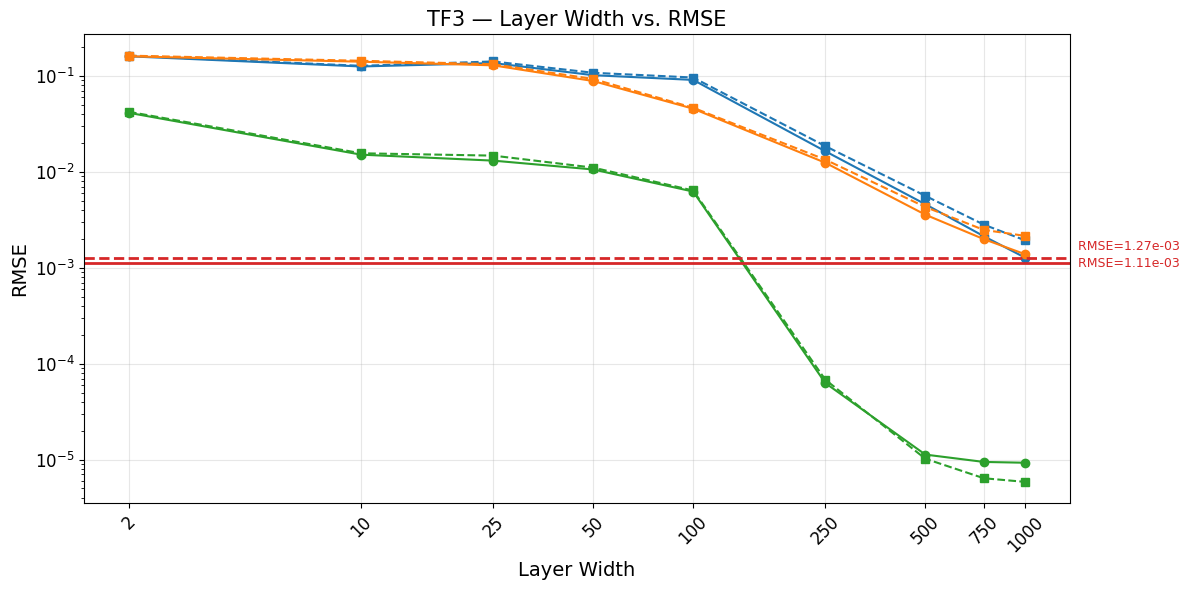

In [24]:
visualize.plot_hypothesis_1_results(
    tf3_hypothesis_1_results_df,
    kan_best_train_rmse=tf3_kan_summary['train_rmse_median'],
    kan_best_test_rmse=tf3_kan_summary['test_rmse_median'],
    title="TF3 — Layer Width vs. RMSE",
    show_legend=False
)

### Hypothesis 2



Increasing layer width (other parameters constant) vs. training time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [25]:
tf3_hypothesis_2_path = "data/tf3_hypothesis_2_results_df.csv"

if os.path.exists(tf3_hypothesis_2_path):
    tf3_hypothesis_2_results_df = pd.read_csv(tf3_hypothesis_2_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    timing = {
        'sgkan_swim': [],
        'sgkan_random': [],
        'hkan': [],
    }

    print("Timing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_sgkan_configs]
        config[0]['layer_width'] = width
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_swim'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_random'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf3_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        start = time.perf_counter()
        utils.fit_hkan(model, tf3_x_train, tf3_y_train)
        fit_time = time.perf_counter() - start
        timing['hkan'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    tf3_hypothesis_2_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_fit_time': timing['sgkan_swim'],
        'sgkan_random_fit_time': timing['sgkan_random'],
        'hkan_fit_time': timing['hkan'],
    })
    tf3_hypothesis_2_results_df.to_csv(tf3_hypothesis_2_path, index=False)

tf3_hypothesis_2_results_df

,layer_width,sgkan_swim_fit_time,sgkan_random_fit_time,hkan_fit_time
0,2,0.030418417,0.013644917,0.028749125
1,10,0.071767875,0.051812792,0.141113291
2,25,0.176048042,0.138963541,0.274394167
3,50,0.295928500,0.325746958,0.547954334
4,100,0.621643625,0.721504375,1.224091458
5,250,1.454807500,1.838625584,2.789673083
6,500,3.397452167,3.235985083,6.472732292
7,750,5.923986542,5.258342209,8.537442750
8,1000,6.376944958,7.210555083,10.924923500


[plot_hypothesis_2_results] saved to static/TF3_Layer_Width_vs_Training_Time_s.png


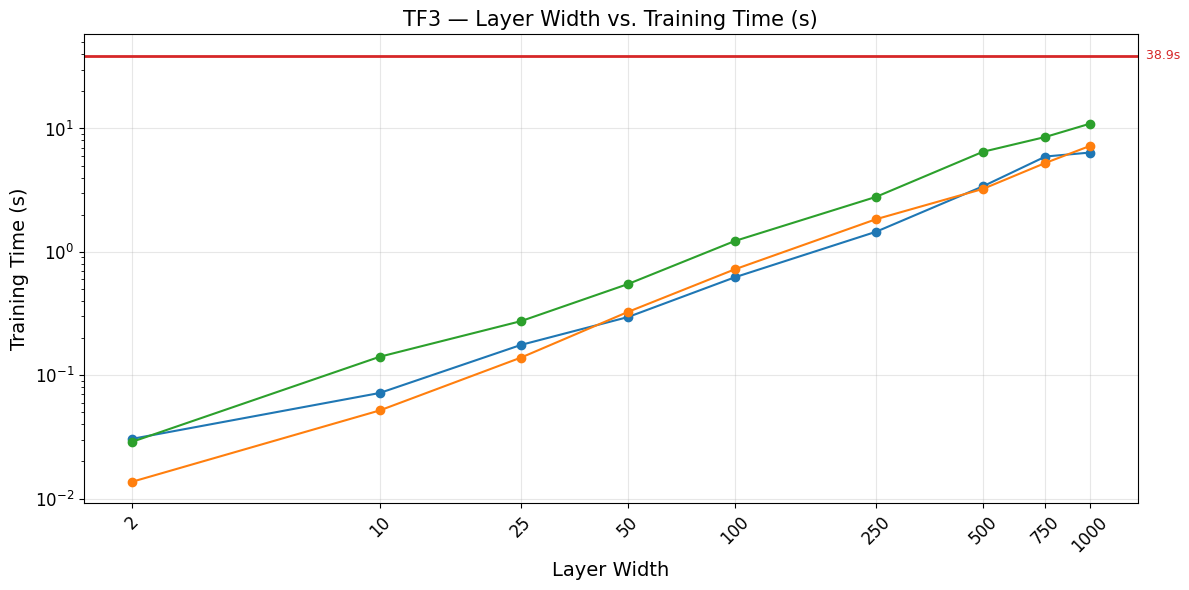

In [26]:
visualize.plot_hypothesis_2_results(
    tf3_hypothesis_2_results_df,
    kan_fit_time=tf3_kan_summary['fit_time_median'],
    title="TF3 — Layer Width vs. Training Time (s)",
    show_legend=False
)

### Hypothesis 3



Increasing layer width (other parameters constant) vs. inference time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [27]:
tf3_hypothesis_3_path = "data/tf3_hypothesis_3_results_df.csv"

if os.path.exists(tf3_hypothesis_3_path):
    tf3_hypothesis_3_results_df = pd.read_csv(tf3_hypothesis_3_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    inf_times = {
        'sgkan_swim': {'train': [], 'test': []},
        'sgkan_random': {'train': [], 'test': []},
        'hkan': {'train': [], 'test': []},
    }

    print("Measuring SGKAN SWIM inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        inf_times['sgkan_swim']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_swim']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring SGKAN Random inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        inf_times['sgkan_random']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_random']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring HKAN inference time...")
    for width in layer_widths:
        config = [c.copy() for c in tf3_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        inf_times['hkan']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['hkan']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    tf3_hypothesis_3_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_inf_time': inf_times['sgkan_swim']['train'],
        'sgkan_swim_test_inf_time': inf_times['sgkan_swim']['test'],
        'sgkan_random_train_inf_time': inf_times['sgkan_random']['train'],
        'sgkan_random_test_inf_time': inf_times['sgkan_random']['test'],
        'hkan_train_inf_time': inf_times['hkan']['train'],
        'hkan_test_inf_time': inf_times['hkan']['test'],
    })
    tf3_hypothesis_3_results_df.to_csv(tf3_hypothesis_3_path, index=False)

tf3_hypothesis_3_results_df

,layer_width,sgkan_swim_train_inf_time,sgkan_swim_test_inf_time,sgkan_random_train_inf_time,sgkan_random_test_inf_time,hkan_train_inf_time,hkan_test_inf_time
0,2,0.006598458,0.007582583,0.002307375,0.008332208,0.004055041,0.021967041
1,10,0.045892459,0.032742542,0.015682584,0.065140417,0.027227833,0.087905083
2,25,0.042942250,0.131837542,0.049356416,0.069189542,0.078531041,0.191967416
3,50,0.079108459,0.200415792,0.070952000,0.168977916,0.195100000,0.349876541
4,100,0.243766333,0.376913708,0.170754834,0.336058667,0.423074292,0.797138209
5,250,0.503844791,1.165635708,0.500371292,0.992184166,0.932066000,1.885504000
6,500,0.885655709,2.019705250,1.026775625,1.736357125,1.795352375,3.681542500
7,750,1.757918750,2.933141542,1.207467375,2.845000208,3.162538834,6.145857208
8,1000,2.566227583,4.035378000,1.870114959,3.627169292,3.940088709,7.796890833


[plot_hypothesis_3_results] saved to static/TF3_Layer_Width_vs_Inference_Time_s.png


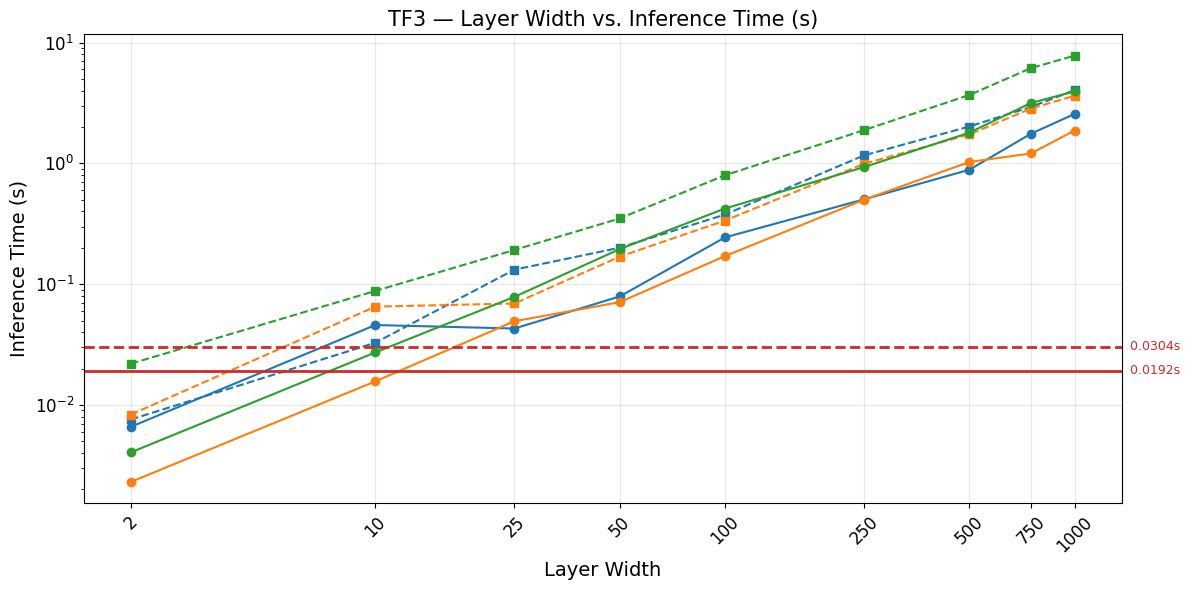

In [28]:
visualize.plot_hypothesis_3_results(
    tf3_hypothesis_3_results_df,
    kan_train_inference_time=tf3_kan_summary['train_inference_time_median'],
    kan_test_inference_time=tf3_kan_summary['test_inference_time_median'],
    title="TF3 — Layer Width vs. Inference Time (s)",
    show_legend=False
)

## TF4

### SG-KAN

In [84]:
# TF4 SGKAN
tf4_sgkan_result = sps.study_optuna_sgkan("tf4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, n_trials=6)
best_tf4_sgkan_configs = tf4_sgkan_result["layer_configs"]
best_tf4_sgkan_configs

Results found for tf4. Loading from data/tf4_sgkan_optuna_search.csv
Best Validation RMSE:   0.313910293974123
Best Test RMSE:          0.284878611883319
Best layer_width:        750
Best num_inducing:       100
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 6 trials:
   number         value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type      val_rmse     test_rmse
0       0  0.3271305006                1000                  100                  1                    0                rbf  0.3271305006           NaN
1       1  0.3139102940                 750                  100                  1                    0                rbf  0.3139102940  0.2848786119
2       2  0.3206821765                 750                   75                  1                    0                rbf  0.3206821765           NaN
3       3  0.3316769512                1000                   50  

[{'layer_width': 750,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [85]:
tf4_sgkan_optuna_df = pd.read_csv("data/tf4_sgkan_optuna_search.csv")
tf4_sgkan_optuna_df.sort_values("val_rmse").head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
1,1,0.3139102940,2026-08-07 18:44:04.021050,2026-08-07 18:45:44.194902,100.173852,1,0,rbf,750,100,...,94.023542250,rbf,750,100,1,0.3139102940,1,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,0.2848786119
4,4,0.3152270725,2026-08-07 18:48:09.613196,2026-08-07 18:49:02.358491,52.745295,1,0,rbf,750,50,...,48.917006666,rbf,750,50,1,0.3152270725,4,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN
2,2,0.3206821765,2026-08-07 18:45:44.201522,2026-08-07 18:46:56.713256,72.511734,1,0,rbf,750,75,...,67.672699375,rbf,750,75,1,0.3206821765,2,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN
0,0,0.3271305006,2026-08-07 18:41:50.155884,2026-08-07 18:44:04.017722,133.861838,1,0,rbf,1000,100,...,125.401469458,rbf,1000,100,1,0.3271305006,0,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN
3,3,0.3316769512,2026-08-07 18:46:56.739732,2026-08-07 18:48:09.609961,72.870229,1,0,rbf,1000,50,...,67.701810792,rbf,1000,50,1,0.3316769512,3,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN
5,5,0.3399988076,2026-08-07 18:49:02.361457,2026-08-07 18:50:50.625235,108.263778,1,0,rbf,1000,75,...,101.627543875,rbf,1000,75,1,0.3399988076,5,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN


In [86]:
start = time.perf_counter()
best_tf4_sgkan_model = sgkan_model.SGKANModel(best_tf4_sgkan_configs).fit(tf4_x_train, tf4_y_train)
fit_time = time.perf_counter() - start
print("SWIM Training time: ", fit_time)

best_tf4_sgkan_results = em.evaluate(best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
em.print_results(best_tf4_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=10)
[fit_layer] local-window method counts over 7500 edges: {'interval_capped': 3904, 'interval': 3226, 'knn_fallback': 370}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval': 339, 'interval_capped': 373, 'knn_fallback': 38}
[SGKANModel.fit] Total fit duration: 114.8200s
SWIM Training time:  114.82011779099957
Metric          Train                Test                
-------------------------------------------------------
MAE             1.956268e-01         2.430517e-01        
RMSE            2.295443e-01         2.848786e-01        
-------------------------------------------------------
Inference (s)   27.281366            11.034172           


In [87]:
# SWIM (Random) ablation
random_best_tf4_sgkan_configs = copy.deepcopy(best_tf4_sgkan_configs)
for i in random_best_tf4_sgkan_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf4_sgkan_configs, best_tf4_sgkan_configs

([{'layer_width': 750,
   'num_inducing': 100,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 100,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 750,
   'num_inducing': 100,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 100,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [88]:
start = time.perf_counter()
random_best_tf4_sgkan_model = sgkan_model.SGKANModel(random_best_tf4_sgkan_configs).fit(tf4_x_train, tf4_y_train)
fit_time = time.perf_counter() - start
print("SWIM(Random) Training time: ", fit_time)

random_best_tf4_sgkan_results = em.evaluate(random_best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
em.print_results(random_best_tf4_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=750, D_in=10)
[fit_layer] local-window method counts over 7500 edges: {'interval_capped': 4015, 'knn_fallback': 347, 'interval': 3138}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval_capped': 476, 'interval': 242, 'knn_fallback': 32}
[SGKANModel.fit] Total fit duration: 111.9863s
SWIM(Random) Training time:  111.98650550000093
Metric          Train                Test                
-------------------------------------------------------
MAE             2.004895e-01         2.459034e-01        
RMSE            2.333145e-01         2.870802e-01        
-------------------------------------------------------
Inference (s)   28.661968            8.429726            


#### 50 Seed Results

In [89]:
# TF4 SGKAN 50 seed runs
tf4_sgkan_50_runs_path = "data/tf4_sgkan_50_run_results.csv"
if os.path.exists(tf4_sgkan_50_runs_path):
    tf4_sgkan_50_runs_df = pd.read_csv("data/tf4_sgkan_50_run_results.csv")
else:
    tf4_sgkan_50_runs = utils.run_sgkan_seed_experiments(tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, best_tf4_sgkan_configs, n_runs=50)
    tf4_sgkan_50_runs_df = utils.create_export_seed_results(tf4_sgkan_50_runs, "tf4_sgkan_50_run_results")

tf4_sgkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.1956267558,0.2295442523,26.251157125,0.2430517037,0.2848786119,7.131397875,87.289873583
1,1,0.1936406420,0.2269175978,24.170886250,0.2439567106,0.2888646165,9.193609542,82.096423917
2,2,0.1976191129,0.2305347766,23.732480292,0.2487397542,0.2918629109,9.234062500,89.550219750
3,3,0.1966061153,0.2305087748,24.935209250,0.2479327284,0.2914698430,7.440626958,80.300739166
4,4,0.1957512459,0.2297333559,23.627324167,0.2443807361,0.2867014589,6.937645250,80.174948584
5,5,0.1941271931,0.2275696201,26.549641750,0.2515462560,0.2949998642,7.491836167,81.366163000
6,6,0.1952644620,0.2290926380,22.900028500,0.2454329212,0.2877272279,7.092931042,80.302492584
7,7,0.1931419145,0.2270608685,23.048637083,0.2517950543,0.2968761518,6.983070125,78.449180041
8,8,0.1950207203,0.2287324660,24.209700083,0.2473302325,0.2932572808,11.654663583,77.436043542
9,9,0.1946112546,0.2280500165,23.527379000,0.2412274520,0.2840801165,8.187857916,81.384603583


In [90]:
tf4_sgkan_summary = utils.summarize_metrics(tf4_sgkan_50_runs_df, "TF4 SGKAN")
tf4_sgkan_summary

{'model': 'TF4 SGKAN',
 'train_rmse_median': 0.22904130859823985,
 'train_rmse_iqr': 0.0026871757177396594,
 'test_rmse_median': 0.28868984970889905,
 'test_rmse_iqr': 0.0061430844428339015,
 'train_inference_time_median': 26.16948885400052,
 'train_inference_time_iqr': 3.1387502609868534,
 'test_inference_time_median': 8.141670687502483,
 'test_inference_time_iqr': 1.7241581252455953,
 'fit_time_median': 93.07514739600447,
 'fit_time_iqr': 23.3641763330088}

#### Explore Feature Importances and Layers

In [91]:
# TF4 SGKAN visualizations
best_tf4_sgkan_stages, best_tf4_sgkan_ytrain_hat, best_tf4_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf4_x_train, tf4_y_train, best_tf4_sgkan_configs)

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=10)
[fit_layer] local-window method counts over 7500 edges: {'interval_capped': 3904, 'interval': 3226, 'knn_fallback': 370}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval': 339, 'interval_capped': 373, 'knn_fallback': 38}


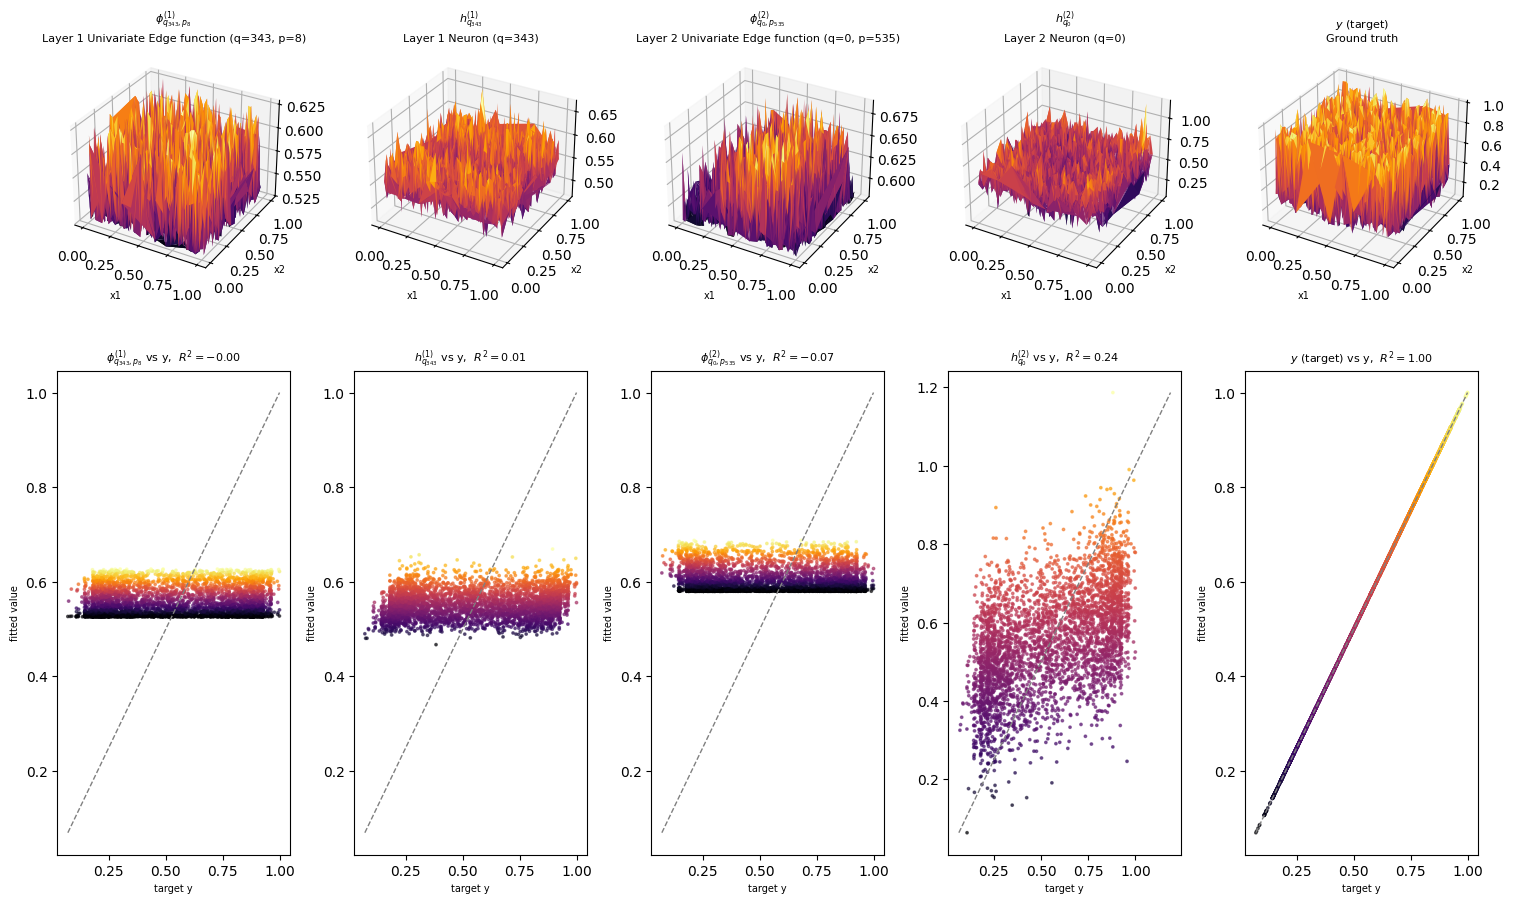

In [92]:
visualize.plot_model_stages(tf4_x_train, tf4_y_train, best_tf4_sgkan_stages, block_idx="random")

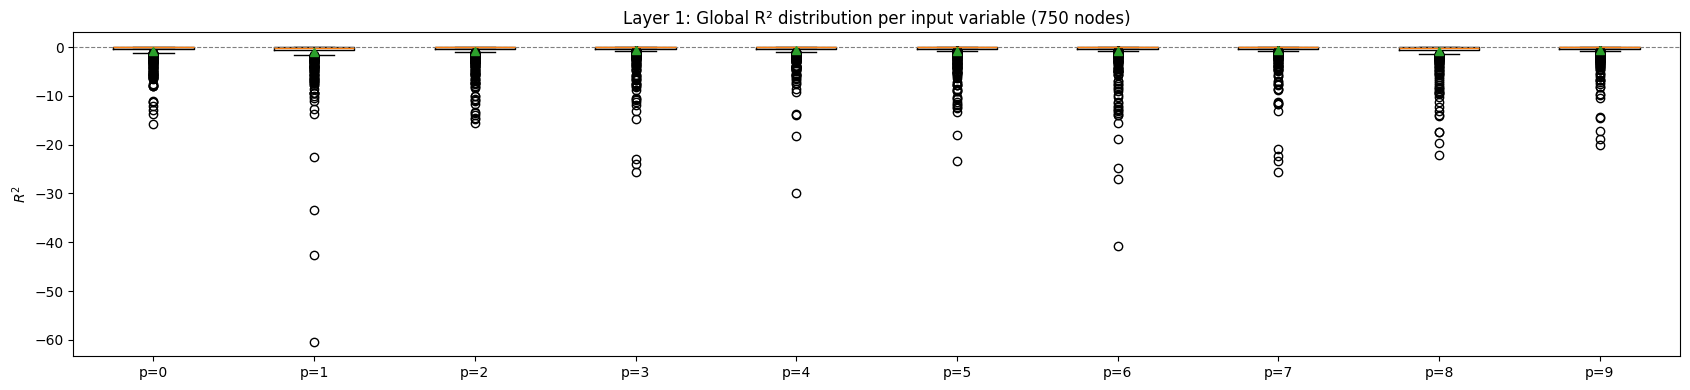

In [93]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf4_sgkan_stages, tf4_y_train)

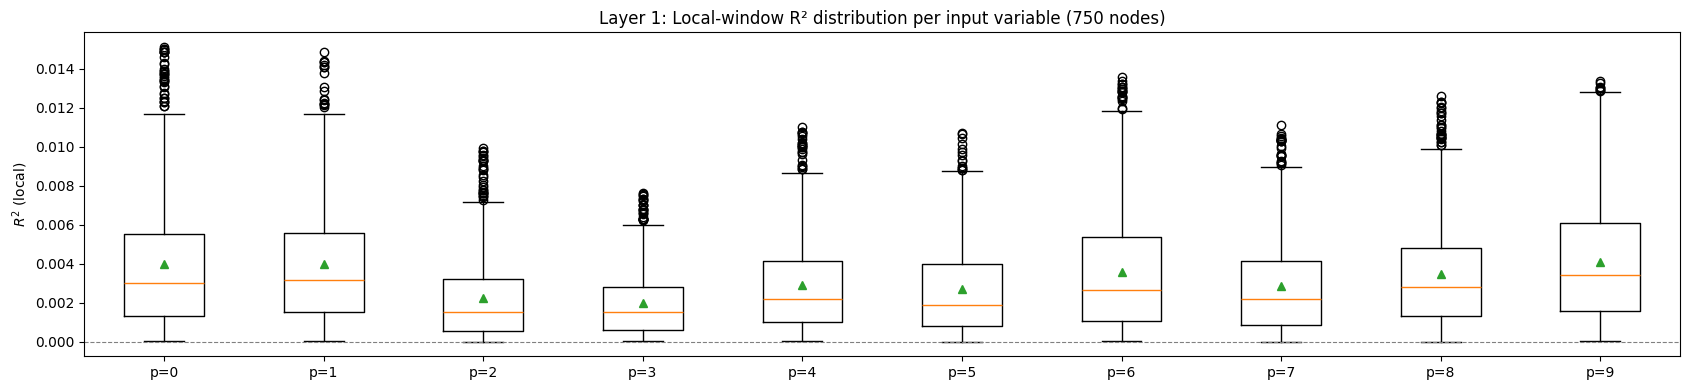

In [94]:
visualize.plot_first_layer_local_edge_r2_summary(best_tf4_sgkan_layer_neurons)

### HKAN

Layer: 0


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 561.79it/s]


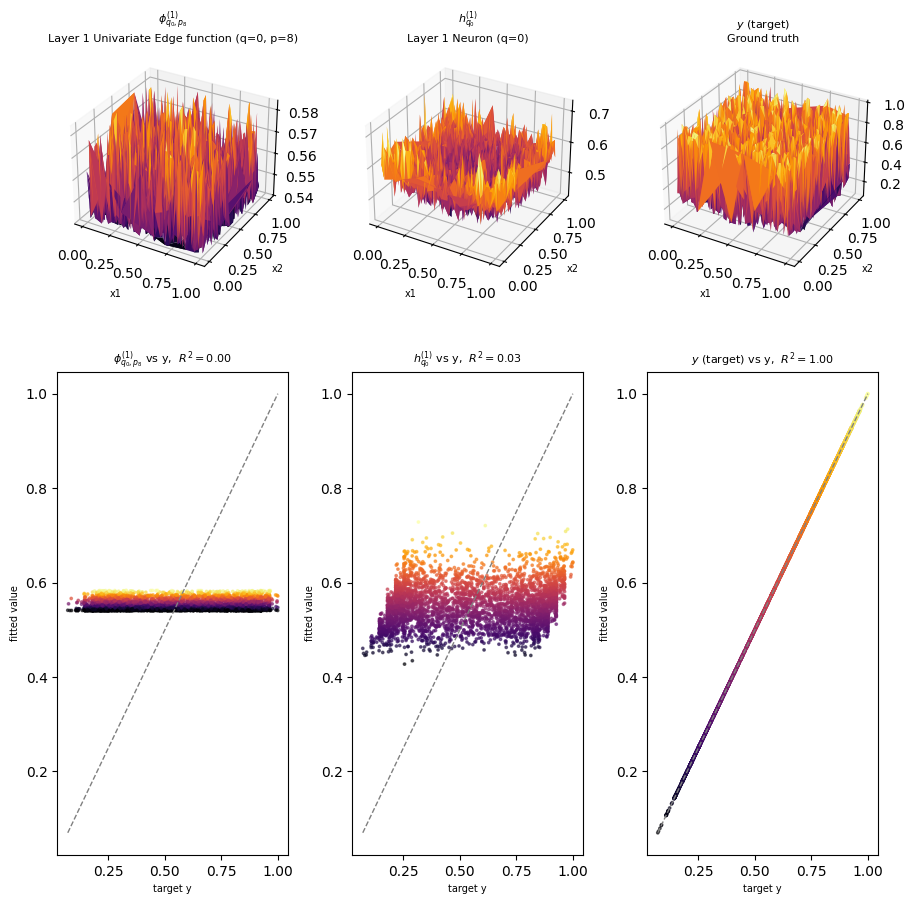

In [95]:
# TF4 HKAN
# Best TF4 HKAN configuration from the paper
tf4_hkan_layer_configs = [
    {
        "layer": 0,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=3),
        "n_basis": 2,
        "centers": "equally_spaced",
        "expanding_base_regressor": Ridge(alpha=0.001),
    }
]

tf4_hkan_stages, tf4_ytrain_hat = utils.stack_hkan_layers(tf4_x_train, tf4_y_train, tf4_hkan_layer_configs)
visualize.plot_model_stages(tf4_x_train, tf4_y_train, tf4_hkan_stages, block_idx="random", seed=0)

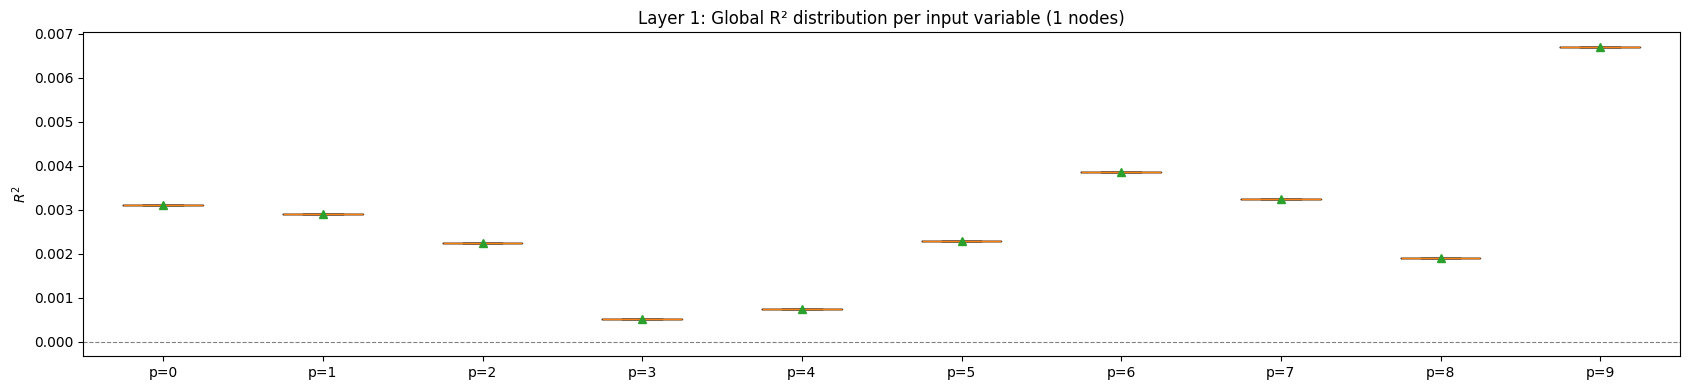

In [96]:
visualize.plot_first_layer_featurewise_r2_summary(tf4_hkan_stages, tf4_y_train)

In [97]:
tf4_hkan_model = utils.build_hkan_model_from_configs(tf4_hkan_layer_configs)
utils.fit_hkan(tf4_hkan_model, tf4_x_train, tf4_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00, 1025.75it/s]


✓ HKAN training completed in 0.0094 seconds


In [98]:
tf4_hkan_results = em.evaluate(tf4_hkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
em.print_results(tf4_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.338550e-01         2.323804e-01        
RMSE            2.594233e-01         2.584713e-01        
-------------------------------------------------------
Inference (s)   0.002702             0.000842            


In [99]:
tf4_hkan_50_runs_path = "data/tf4_hkan_50_run_results.csv"


if os.path.exists(tf4_hkan_50_runs_path):
    tf4_hkan_50_runs_df = pd.read_csv("data/tf4_hkan_50_run_results.csv")
else:
    tf4_hkan_50_runs = utils.run_hkan_seed_experiments(tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, tf4_hkan_layer_configs, n_runs=50)
    tf4_hkan_50_runs_df = utils.create_export_seed_results(tf4_hkan_50_runs, "tf4_hkan_50_run_results")

tf4_hkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.2338549939,0.2594232852,0.004736208,0.232380422,0.2584713406,0.001544541,0.011588333
1,1,0.2338549939,0.2594232852,0.001092042,0.232380422,0.2584713406,0.000573708,0.011753916
2,2,0.2338549939,0.2594232852,0.001085875,0.232380422,0.2584713406,0.000534417,0.005857000
3,3,0.2338549939,0.2594232852,0.000967834,0.232380422,0.2584713406,0.000520750,0.008978292
4,4,0.2338549939,0.2594232852,0.001218500,0.232380422,0.2584713406,0.002069291,0.007338708
5,5,0.2338549939,0.2594232852,0.002633750,0.232380422,0.2584713406,0.000821583,0.009112291
6,6,0.2338549939,0.2594232852,0.000981250,0.232380422,0.2584713406,0.000487791,0.011438625
7,7,0.2338549939,0.2594232852,0.003830292,0.232380422,0.2584713406,0.001605500,0.009791959
8,8,0.2338549939,0.2594232852,0.001987417,0.232380422,0.2584713406,0.007743292,0.008714583
9,9,0.2338549939,0.2594232852,0.000936084,0.232380422,0.2584713406,0.001203583,0.008284083


In [100]:
tf4_hkan_summary = utils.summarize_metrics(tf4_hkan_50_runs_df, "TF4 HKAN")
tf4_hkan_summary

{'model': 'TF4 HKAN',
 'train_rmse_median': 0.2594232852239973,
 'train_rmse_iqr': 0.0,
 'test_rmse_median': 0.2584713405613519,
 'test_rmse_iqr': 0.0,
 'train_inference_time_median': 0.00224802099546645,
 'train_inference_time_iqr': 0.0015769165038363752,
 'test_inference_time_median': 0.0010326460032956,
 'test_inference_time_iqr': 0.001083385508536625,
 'fit_time_median': 0.008687270499649399,
 'fit_time_iqr': 0.004207885507639724}

### KAN

In [101]:
# TF4 KAN
tf4_kan_study = utils.study_optuna_kan("TF4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
tf4_kan_best_architecture = tf4_kan_study["architecture"]
tf4_kan_best_architecture

Results found for TF4. Loading from data/tf4_kan_optuna_search.csv
Best Validation RMSE:   0.268237
Best architecture:       [10, 1]

All 10 trials:
   number  params_width_idx user_attrs_architecture  user_attrs_val_rmse user_attrs_grids  user_attrs_steps_per_grid user_attrs_opt  user_attrs_lamb    duration
0       0                 8         [10, 21, 11, 1]         0.5210003982      (5, 10, 20)                         20          LBFGS                0  160.130044
1       1                 1              [10, 2, 1]         0.3144088396      (5, 10, 20)                         20          LBFGS                0   36.744576
2       2                 5          [10, 11, 2, 1]         0.5416382297      (5, 10, 20)                         20          LBFGS                0   71.851222
3       3                 0                 [10, 1]         0.2682371787      (5, 10, 20)                         20          LBFGS                0   27.332012
4       4                 7         [10, 11, 1

[10, 1]

In [102]:
# Calculate training time
start = time.perf_counter()
model = utils.build_kan(width=tf4_kan_best_architecture, grid=3, k=3, seed=42)
model = utils.fit_kan_with_grid_extension(
    model,
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test,
    grids=(5, 10, 20), steps_per_grid=20, opt="LBFGS", lamb=0
)
fit_time = time.perf_counter() - start
print("TF4 KAN Training time: ", fit_time)

tf4_kan_results = em.evaluate(
    utils.KANModel(model),
    tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(tf4_kan_results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 2.58e-01 | test_loss: 2.59e-01 | reg: 3.77e+00 | : 100%|█| 20/20 [00:03<00:00,  5.37it


saving model version 0.1
saving model version 0.2


| train_loss: 2.57e-01 | test_loss: 2.59e-01 | reg: 3.92e+00 | : 100%|█| 20/20 [00:04<00:00,  4.56it


saving model version 0.3
saving model version 0.4


| train_loss: 2.56e-01 | test_loss: 2.62e-01 | reg: 4.18e+00 | : 100%|█| 20/20 [00:06<00:00,  3.21it


saving model version 0.5
saving model version 0.6


| train_loss: 2.52e-01 | test_loss: 2.67e-01 | reg: 4.66e+00 | : 100%|█| 20/20 [00:09<00:00,  2.19it

saving model version 0.7

✓ KAN training with grid extension completed in 23.5449 seconds
TF4 KAN Training time:  23.555113166999945
Metric          Train                Test                
-------------------------------------------------------
MAE             2.242096e-01         2.381406e-01        
RMSE            2.524938e-01         2.670864e-01        
-------------------------------------------------------
Inference (s)   0.017648             0.007687            


In [29]:
tf4_kan_50_runs_path = "data/tf4_kan_50_run_results.csv"

if os.path.exists(tf4_kan_50_runs_path):
    tf4_kan_50_runs_df = pd.read_csv("data/tf4_kan_50_run_results.csv")
else:
    tf4_kan_50_runs = utils.run_kan_seed_experiments(
        tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test,
        width=tf4_kan_best_architecture,
        grids=(5, 10, 20),
        steps_per_grid=20,
        opt="LBFGS",
        lamb=0,
        n_runs=50
    )
    tf4_kan_50_runs_df = utils.create_export_seed_results(tf4_kan_50_runs, "tf4_kan_50_run_results")

tf4_kan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.2241954270,0.2524874169,0.018042083,0.2381650972,0.2671066836,0.007381792,25.700333958
1,1,0.2241991675,0.2524898319,0.017796625,0.2381745039,0.2671301139,0.007234833,26.389861833
2,2,0.2241924272,0.2524860169,0.017752458,0.2381793588,0.2671191621,0.006806167,25.035332375
3,3,0.2241961752,0.2524863972,0.017519166,0.2381859574,0.2671228266,0.006444625,26.207065750
4,4,0.2242010249,0.2524863688,0.017637667,0.2381729058,0.2671166140,0.006440042,27.042869208
5,5,0.2242007107,0.2524877215,0.016932125,0.2381591961,0.2671073567,0.006327625,27.088485583
6,6,0.2242076359,0.2524908612,0.019225208,0.2381576729,0.2671167866,0.007607209,25.710293334
7,7,0.2242020653,0.2524905982,0.024258542,0.2381631827,0.2671157469,0.007544583,24.731255459
8,8,0.2242048240,0.2524902949,0.020505583,0.2381610729,0.2671080307,0.015908916,28.765700208
9,9,0.2241963586,0.2524863029,0.037393708,0.2381939233,0.2671393517,0.019238958,26.259941875


In [30]:
tf4_kan_summary = utils.summarize_metrics(tf4_kan_50_runs_df, "TF4 KAN")
tf4_kan_summary

{'model': 'TF4 KAN',
 'train_rmse_median': 0.25248676739920095,
 'train_rmse_iqr': 2.449893091283073e-06,
 'test_rmse_median': 0.26711591164347426,
 'test_rmse_iqr': 2.172839065883725e-05,
 'train_inference_time_median': 0.018513688002713,
 'train_inference_time_iqr': 0.0028916664996358997,
 'test_inference_time_median': 0.0073596874935900995,
 'test_inference_time_iqr': 0.0013013329989916252,
 'fit_time_median': 26.194525124999927,
 'fit_time_iqr': 2.227830853749765}

### Hypothesis 1


Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

In [31]:
tf4_hypothesis_1_path = "data/tf4_hypothesis_1_results_df.csv"

if os.path.exists(tf4_hypothesis_1_path):
    tf4_hypothesis_1_results_df = pd.read_csv("data/tf4_hypothesis_1_results_df.csv")

else: 
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]
    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf4_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        config[0]['centers'] = "random"
        config.append(
            dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced",
                basis_fn=Identity(), expanding_base_regressor=None)
        )
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf4_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf4_hypothesis_1_results_df.to_csv("data/tf4_hypothesis_1_results_df.csv")

tf4_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.2630895687,0.2620253931,0.2610528239,0.2600351612,0.2591795309,0.2589103772
1,1,10,0.2603948392,0.2605567767,0.2602528714,0.2595279873,0.2590704833,0.2587857388
2,2,25,0.2597863919,0.2593097685,0.2585181185,0.2593200103,0.2586103137,0.2593608160
3,3,50,0.2573097607,0.2610734861,0.2580460983,0.2601030881,0.2578350266,0.2586757064
4,4,100,0.2561209311,0.2619499260,0.2566744475,0.2607686081,0.2563716567,0.2608134605
5,5,250,0.2501085962,0.2672997193,0.2494078777,0.2670062119,0.2527140288,0.2663366059
6,6,500,0.2397188318,0.2751354121,0.2414433479,0.2762453808,0.2526022108,0.2664609056
7,7,750,0.2295442523,0.2848786119,0.2333145000,0.2870801894,0.2525244575,0.2666203169
8,8,1000,0.2169582708,0.3037269383,0.2192599854,0.2982157076,0.2524014757,0.2665598516


[plot_hypothesis_1_results] saved to static/TF4_Layer_Width_vs_RMSE.png


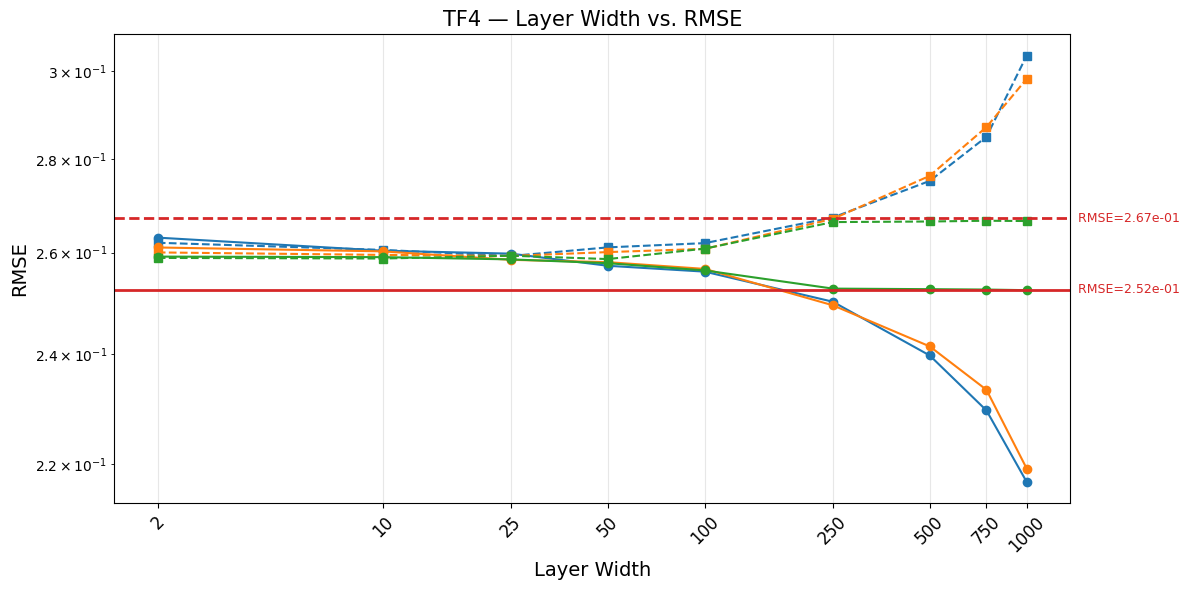

In [32]:
visualize.plot_hypothesis_1_results(
    tf4_hypothesis_1_results_df,
    kan_best_train_rmse=tf4_kan_summary['train_rmse_median'],
    kan_best_test_rmse=tf4_kan_summary['test_rmse_median'],
    title="TF4 — Layer Width vs. RMSE",
    show_legend=False
)

### Hypothesis 2



Increasing layer width (other parameters constant) vs. training time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [33]:
tf4_hypothesis_2_path = "data/tf4_hypothesis_2_results_df.csv"

if os.path.exists(tf4_hypothesis_2_path):
    tf4_hypothesis_2_results_df = pd.read_csv(tf4_hypothesis_2_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    timing = {
        'sgkan_swim': [],
        'sgkan_random': [],
        'hkan': [],
    }

    print("Timing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_sgkan_configs]
        config[0]['layer_width'] = width
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_swim'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_random'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf4_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        config[0]['centers'] = "random"
        config.append(
            dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced",
                basis_fn=Identity(), expanding_base_regressor=None)
        )
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        start = time.perf_counter()
        utils.fit_hkan(model, tf4_x_train, tf4_y_train)
        fit_time = time.perf_counter() - start
        timing['hkan'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    tf4_hypothesis_2_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_fit_time': timing['sgkan_swim'],
        'sgkan_random_fit_time': timing['sgkan_random'],
        'hkan_fit_time': timing['hkan'],
    })
    tf4_hypothesis_2_results_df.to_csv(tf4_hypothesis_2_path, index=False)

tf4_hypothesis_2_results_df

,layer_width,sgkan_swim_fit_time,sgkan_random_fit_time,hkan_fit_time
0,2,0.345617250,0.258988917,0.013619125
1,10,1.473388375,1.388588375,0.093408917
2,25,3.136567459,3.791143834,0.216455167
3,50,6.033792625,8.884672917,0.365315250
4,100,12.351749250,21.963521167,0.594714000
5,250,30.334960834,41.115326125,1.435982000
6,500,68.341228750,65.125760750,2.658541083
7,750,122.596320834,96.180186750,3.885707292
8,1000,157.744993625,121.886238709,5.218857834


[plot_hypothesis_2_results] saved to static/TF4_Layer_Width_vs_Training_Time_s.png


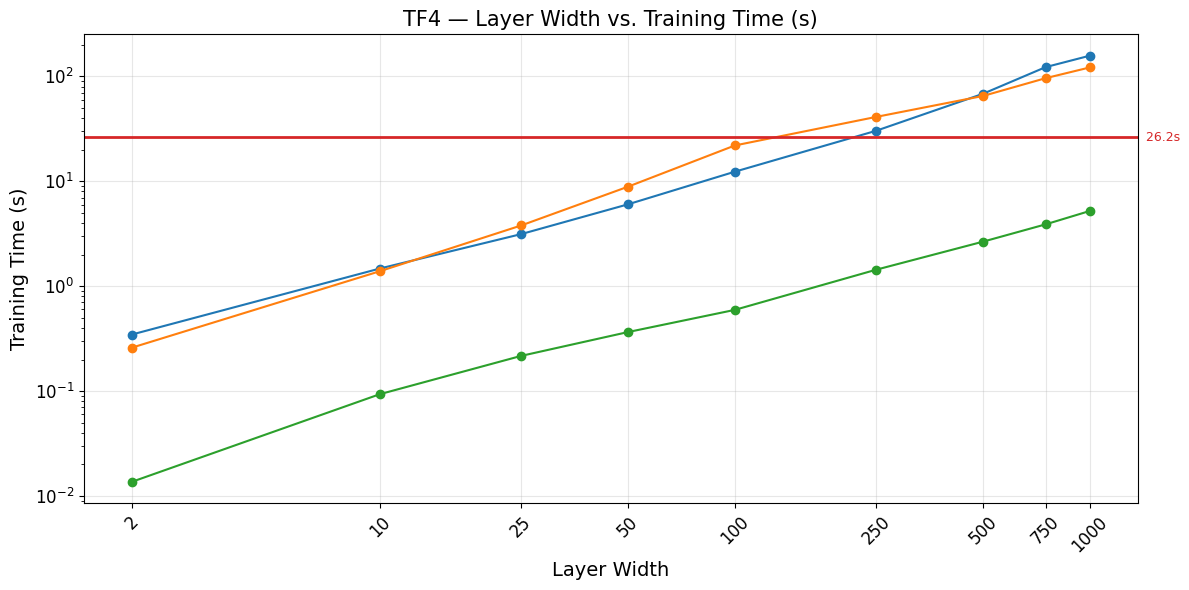

In [34]:
visualize.plot_hypothesis_2_results(
    tf4_hypothesis_2_results_df,
    kan_fit_time=tf4_kan_summary['fit_time_median'],
    title="TF4 — Layer Width vs. Training Time (s)",
    show_legend=False
)

### Hypothesis 3

Increasing layer width (other parameters constant) vs. inference time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [35]:
tf4_hypothesis_3_path = "data/tf4_hypothesis_3_results_df.csv"

if os.path.exists(tf4_hypothesis_3_path):
    tf4_hypothesis_3_results_df = pd.read_csv(tf4_hypothesis_3_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    inf_times = {
        'sgkan_swim': {'train': [], 'test': []},
        'sgkan_random': {'train': [], 'test': []},
        'hkan': {'train': [], 'test': []},
    }

    print("Measuring SGKAN SWIM inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        inf_times['sgkan_swim']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_swim']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring SGKAN Random inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        inf_times['sgkan_random']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_random']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring HKAN inference time...")
    for width in layer_widths:
        config = [c.copy() for c in tf4_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        config[0]['centers'] = "random"
        config.append(
            dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced",
                basis_fn=Identity(), expanding_base_regressor=None)
        )
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        inf_times['hkan']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['hkan']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    tf4_hypothesis_3_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_inf_time': inf_times['sgkan_swim']['train'],
        'sgkan_swim_test_inf_time': inf_times['sgkan_swim']['test'],
        'sgkan_random_train_inf_time': inf_times['sgkan_random']['train'],
        'sgkan_random_test_inf_time': inf_times['sgkan_random']['test'],
        'hkan_train_inf_time': inf_times['hkan']['train'],
        'hkan_test_inf_time': inf_times['hkan']['test'],
    })
    tf4_hypothesis_3_results_df.to_csv(tf4_hypothesis_3_path, index=False)

tf4_hypothesis_3_results_df

,layer_width,sgkan_swim_train_inf_time,sgkan_swim_test_inf_time,sgkan_random_train_inf_time,sgkan_random_test_inf_time,hkan_train_inf_time,hkan_test_inf_time
0,2,0.084185875,0.039066792,0.078451125,0.026626916,0.002170541,0.002856542
1,10,0.406413959,0.123770833,0.396152958,0.114602333,0.012730250,0.010488875
2,25,0.894650708,0.286449375,1.103554917,0.420410875,0.044510375,0.019750791
3,50,1.854711375,0.556270292,2.203348250,0.717218750,0.087389666,0.054175583
4,100,3.908909917,1.138229667,3.825405542,1.224038375,0.142591083,0.083729458
5,250,9.571267959,3.001139708,9.731229959,2.952691334,0.286196208,0.261587000
6,500,17.459153167,5.480065916,18.911243542,5.733918333,0.483255959,0.334835625
7,750,27.617987791,8.285702250,25.850593625,7.560336833,0.842154458,0.480980541
8,1000,45.436763333,13.247851792,69.701269042,14.727621000,0.946723250,0.600812333


[plot_hypothesis_3_results] saved to static/TF4_Layer_Width_vs_Inference_Time_s.png


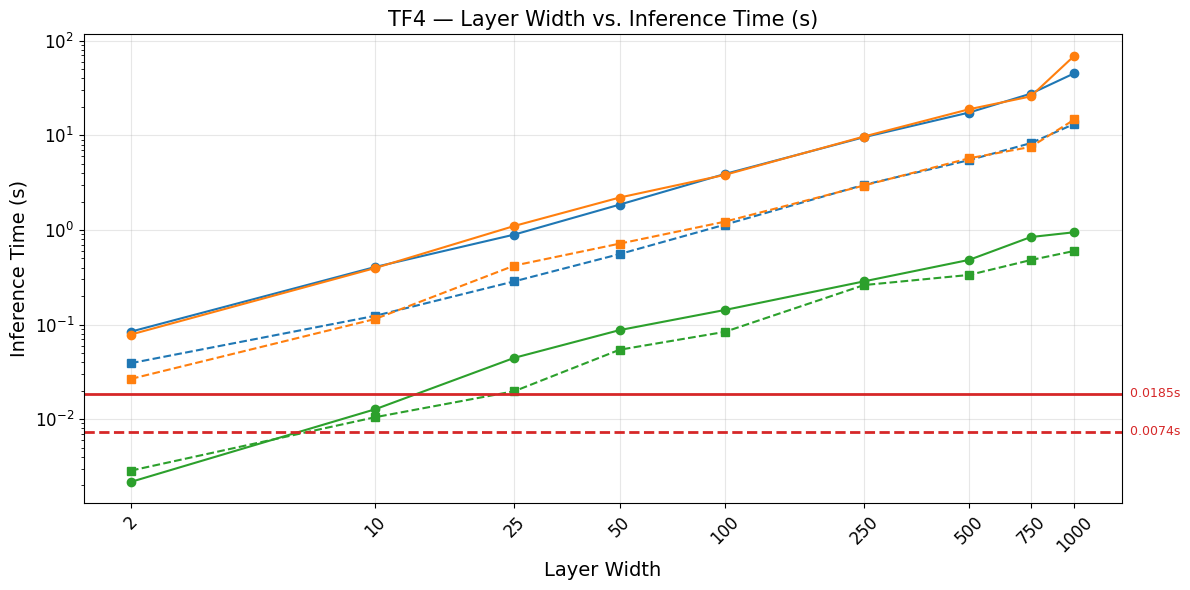

In [36]:
visualize.plot_hypothesis_3_results(
    tf4_hypothesis_3_results_df,
    kan_train_inference_time=tf4_kan_summary['train_inference_time_median'],
    kan_test_inference_time=tf4_kan_summary['test_inference_time_median'],
    title="TF4 — Layer Width vs. Inference Time (s)",
    show_legend=False
)

## TF5

### SG-KAN

In [111]:
# TF5 SGKAN
tf5_sgkan_result = sps.study_optuna_sgkan(
    "tf5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test,
    n_trials=375
)
best_tf5_sgkan_configs = tf5_sgkan_result["layer_configs"]
best_tf5_sgkan_configs

Results found for tf5. Loading from data/tf5_sgkan_optuna_search.csv
Best Validation RMSE:   0.000187550693177
Best Test RMSE:          0.001230334676733
Best layer_width:        1000
Best num_inducing:       50
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number          value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type       val_rmse     test_rmse
0         0   0.0014591474                1000                   50              0.001                    0             matern   0.0014591474           NaN
1         1   0.0126618196                1000                   25              1.000                    0           periodic   0.0126618196           NaN
2         2   0.0059003113                 500                   50             10.000                    0                rbf   0.0059003113           NaN
3         3   0.0211394409                 500  

[{'layer_width': 1000,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [112]:
tf5_sgkan_optuna_df = pd.read_csv("data/tf5_sgkan_optuna_search.csv")
tf5_sgkan_optuna_df.sort_values("val_rmse").head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
207,207,0.0001875507,2026-08-06 23:00:40.564401,2026-08-06 23:00:58.132191,17.567790,1.000,0,rbf,1000,50,...,16.041655916,rbf,1000,50,1,0.0001875507,207,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0012303347
341,341,0.0003012967,2026-08-06 23:28:05.679946,2026-08-06 23:28:40.237560,34.557614,0.001,0,rbf,1000,100,...,32.231201041,rbf,1000,100,1,0.0003012967,341,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
46,46,0.0005518841,2026-08-06 22:31:14.869332,2026-08-06 22:31:24.297717,9.428385,1.000,0,matern,750,25,...,8.756637250,matern,750,25,1,0.0005518841,46,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
334,334,0.0006190977,2026-08-06 23:26:40.259308,2026-08-06 23:27:05.656791,25.397483,10.000,0,matern,1000,50,...,23.286564875,matern,1000,50,1,0.0006190977,334,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
285,285,0.0006386337,2026-08-06 23:14:47.911630,2026-08-06 23:15:26.044923,38.133293,0.001,0,rbf,750,100,...,35.175436500,rbf,750,100,1,0.0006386337,285,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
281,281,0.0006983970,2026-08-06 23:13:55.493638,2026-08-06 23:14:01.374441,5.880803,10.000,0,rbf,750,10,...,5.464403000,rbf,750,10,1,0.0006983970,281,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
347,347,0.0007614306,2026-08-06 23:29:43.325055,2026-08-06 23:29:47.607017,4.281962,1.000,0,matern,750,10,...,3.995689500,matern,750,10,1,0.0007614306,347,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
304,304,0.0007739432,2026-08-06 23:22:00.505518,2026-08-06 23:22:11.842770,11.337252,0.001,0,matern,1000,25,...,10.587528125,matern,1000,25,1,0.0007739432,304,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
282,282,0.0008159303,2026-08-06 23:14:01.382043,2026-08-06 23:14:38.569759,37.187716,0.001,0,rbf,1000,75,...,34.329512833,rbf,1000,75,1,0.0008159303,282,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
152,152,0.0008745842,2026-08-06 22:51:01.081692,2026-08-06 22:51:25.491863,24.410171,10.000,0,matern,750,75,...,22.433200375,matern,750,75,1,0.0008745842,152,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [113]:
start = time.perf_counter()
best_tf5_sgkan_model = sgkan_model.SGKANModel(best_tf5_sgkan_configs).fit(tf5_x_train, tf5_y_train)
fit_time = time.perf_counter() - start
print("SWIM Training time: ", fit_time)

best_tf5_sgkan_results = em.evaluate(
    best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(best_tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1094, 'interval': 881, 'knn_fallback': 25}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 811, 'interval': 182, 'knn_fallback': 7}
[SGKANModel.fit] Total fit duration: 27.7669s
SWIM Training time:  27.767046167000444
Metric          Train                Test                
-------------------------------------------------------
MAE             3.544626e-04         5.664649e-04        
RMSE            5.326688e-04         1.230335e-03        
-------------------------------------------------------
Inference (s)   7.686798             15.816823           


In [114]:
# SWIM (Random) ablation
random_best_tf5_sgkan_configs = copy.deepcopy(best_tf5_sgkan_configs)
for i in random_best_tf5_sgkan_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf5_sgkan_configs, best_tf5_sgkan_configs

([{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [115]:
start = time.perf_counter()
random_best_tf5_sgkan_model = sgkan_model.SGKANModel(random_best_tf5_sgkan_configs).fit(tf5_x_train, tf5_y_train)
fit_time = time.perf_counter() - start
print("SWIM(Random) Training time: ", fit_time)

random_best_tf5_sgkan_results = em.evaluate(
    random_best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(random_best_tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1293, 'knn_fallback': 30, 'interval': 677}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 682, 'interval': 307, 'knn_fallback': 11}
[SGKANModel.fit] Total fit duration: 22.8127s
SWIM(Random) Training time:  22.81284020900057
Metric          Train                Test                
-------------------------------------------------------
MAE             4.386941e-04         7.291172e-04        
RMSE            6.688014e-04         2.238577e-03        
-------------------------------------------------------
Inference (s)   6.724089             13.245638           


#### 50 Seed Results

In [116]:
# TF5 SGKAN 50 seed runs
tf5_sgkan_50_runs_path = "data/tf5_sgkan_50_run_results.csv"

if os.path.exists(tf5_sgkan_50_runs_path):
    tf5_sgkan_50_runs_df = pd.read_csv("data/tf5_sgkan_50_run_results.csv")
else:
    tf5_sgkan_50_runs = utils.run_sgkan_seed_experiments(tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, best_tf5_sgkan_configs, n_runs=50)
    tf5_sgkan_50_runs_df = utils.create_export_seed_results(tf5_sgkan_50_runs, "tf5_sgkan_50_run_results")

tf5_sgkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.0003544626,0.0005326688,7.517290625,0.0005664649,0.0012303347,14.488845292,22.599777875
1,1,0.0003479253,0.0005199217,8.093817875,0.0006643318,0.0028935192,16.354533833,23.577978209
2,2,0.0004575715,0.0006421849,7.110783750,0.0007291917,0.0024873827,13.877878792,19.818639709
3,3,0.0008492616,0.0013203059,7.496199584,0.0014316432,0.0044057665,14.602178041,19.750360250
4,4,0.0004190386,0.0006310671,7.225617875,0.0007362570,0.0032447847,13.952141042,19.359068167
5,5,0.0002556226,0.0003723510,9.161847500,0.0004947518,0.0030922373,13.913019625,19.747119583
6,6,0.0004763600,0.0007726447,7.337049666,0.0008783751,0.0033487973,14.121625500,20.268886584
7,7,0.0003136464,0.0004584682,7.249408833,0.0004645145,0.0009757626,14.021742625,20.015311458
8,8,0.0007792758,0.0012083573,7.354658417,0.0010671875,0.0018078519,14.237014416,20.268381375
9,9,0.0004631122,0.0007187487,7.271500417,0.0008043180,0.0028005988,14.017950708,20.258725333


In [117]:
tf5_sgkan_summary = utils.summarize_metrics(tf5_sgkan_50_runs_df, "TF5 SGKAN")
tf5_sgkan_summary

{'model': 'TF5 SGKAN',
 'train_rmse_median': 0.0006154461406828501,
 'train_rmse_iqr': 0.0006473727233658249,
 'test_rmse_median': 0.00228778627928255,
 'test_rmse_iqr': 0.0016489566705463748,
 'train_inference_time_median': 6.844977062493854,
 'train_inference_time_iqr': 0.6960891042435833,
 'test_inference_time_median': 13.560170437507622,
 'test_inference_time_iqr': 0.8249623955089227,
 'fit_time_median': 18.605208542001492,
 'fit_time_iqr': 2.6734203132546135}

#### Explore Feature Importances and Layers

In [118]:
best_tf5_sgkan_stages, best_tf5_sgkan_ytrain_hat, best_tf5_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf5_x_train, tf5_y_train, best_tf5_sgkan_configs)

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1094, 'interval': 881, 'knn_fallback': 25}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 811, 'interval': 182, 'knn_fallback': 7}


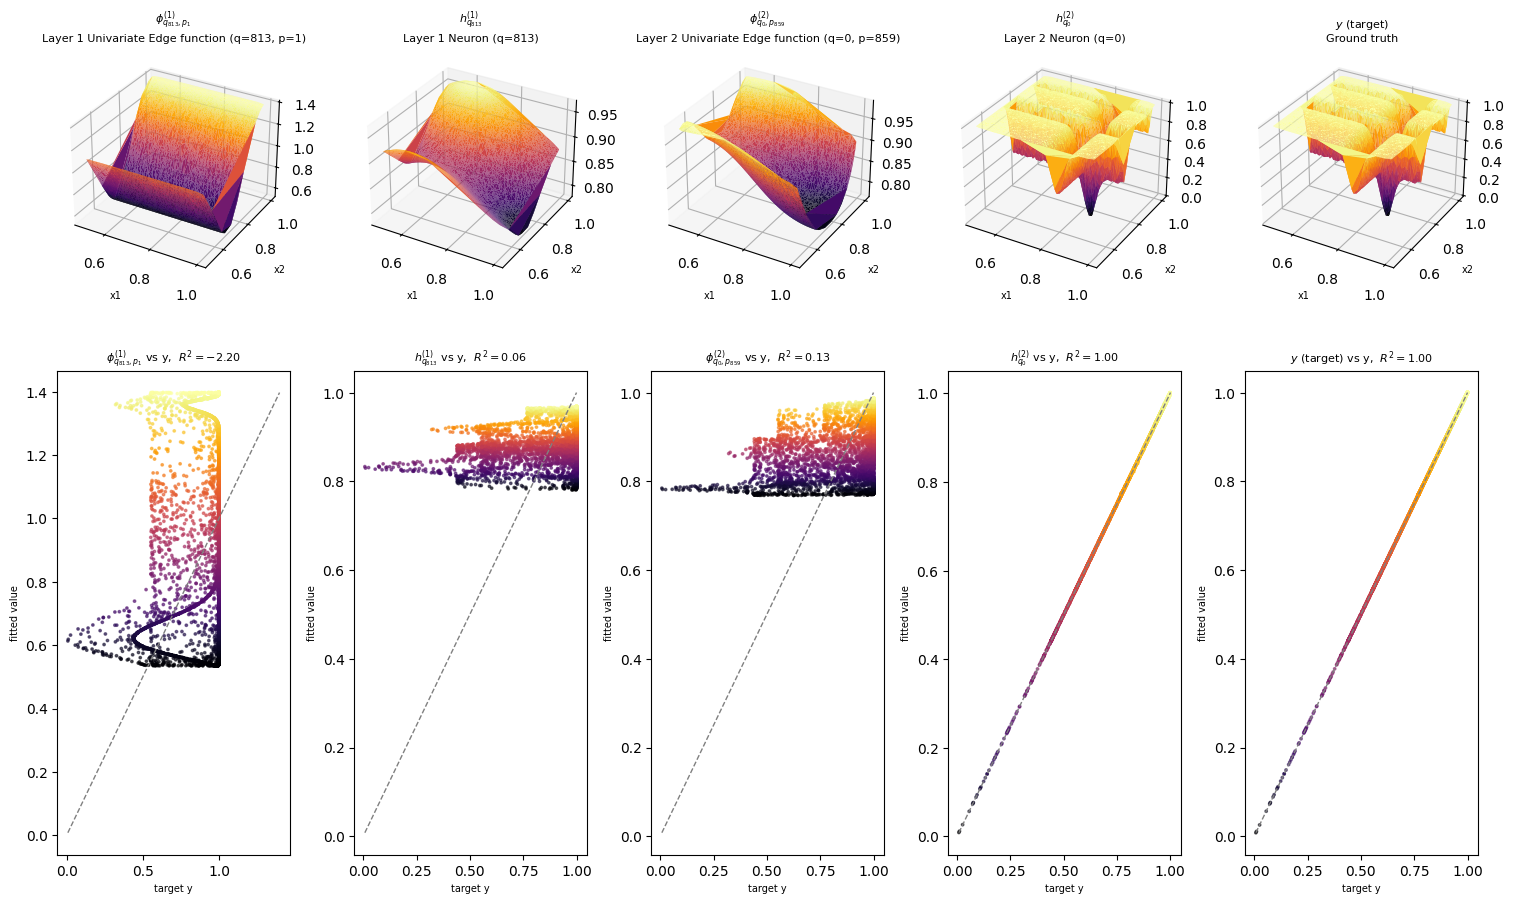

In [119]:
visualize.plot_model_stages(tf5_x_train, tf5_y_train, best_tf5_sgkan_stages, block_idx="random")

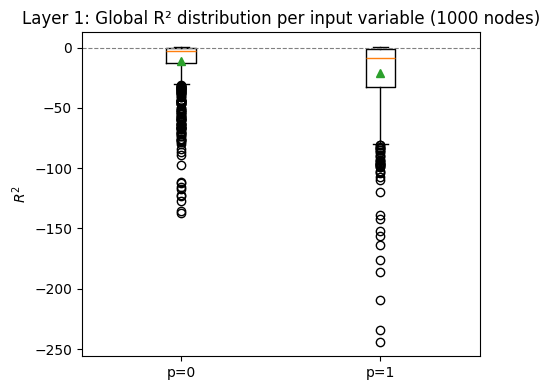

In [120]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf5_sgkan_stages, tf5_y_train)

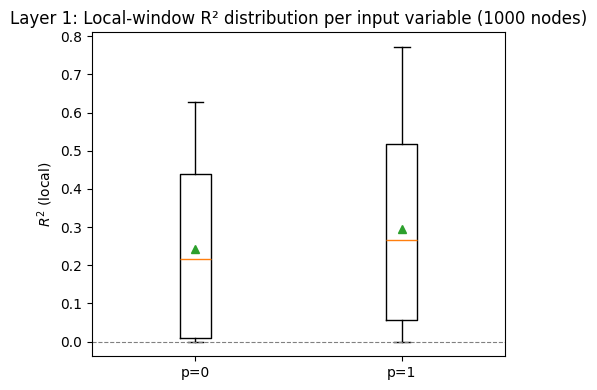

In [121]:
visualize.plot_first_layer_local_edge_r2_summary(best_tf5_sgkan_layer_neurons)

### HKAN

Layer: 0


Fitting connecting regressors: 100%|██████████| 912/912 [00:00<00:00, 2484.31it/s]


Layer: 1


Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  5.03it/s]


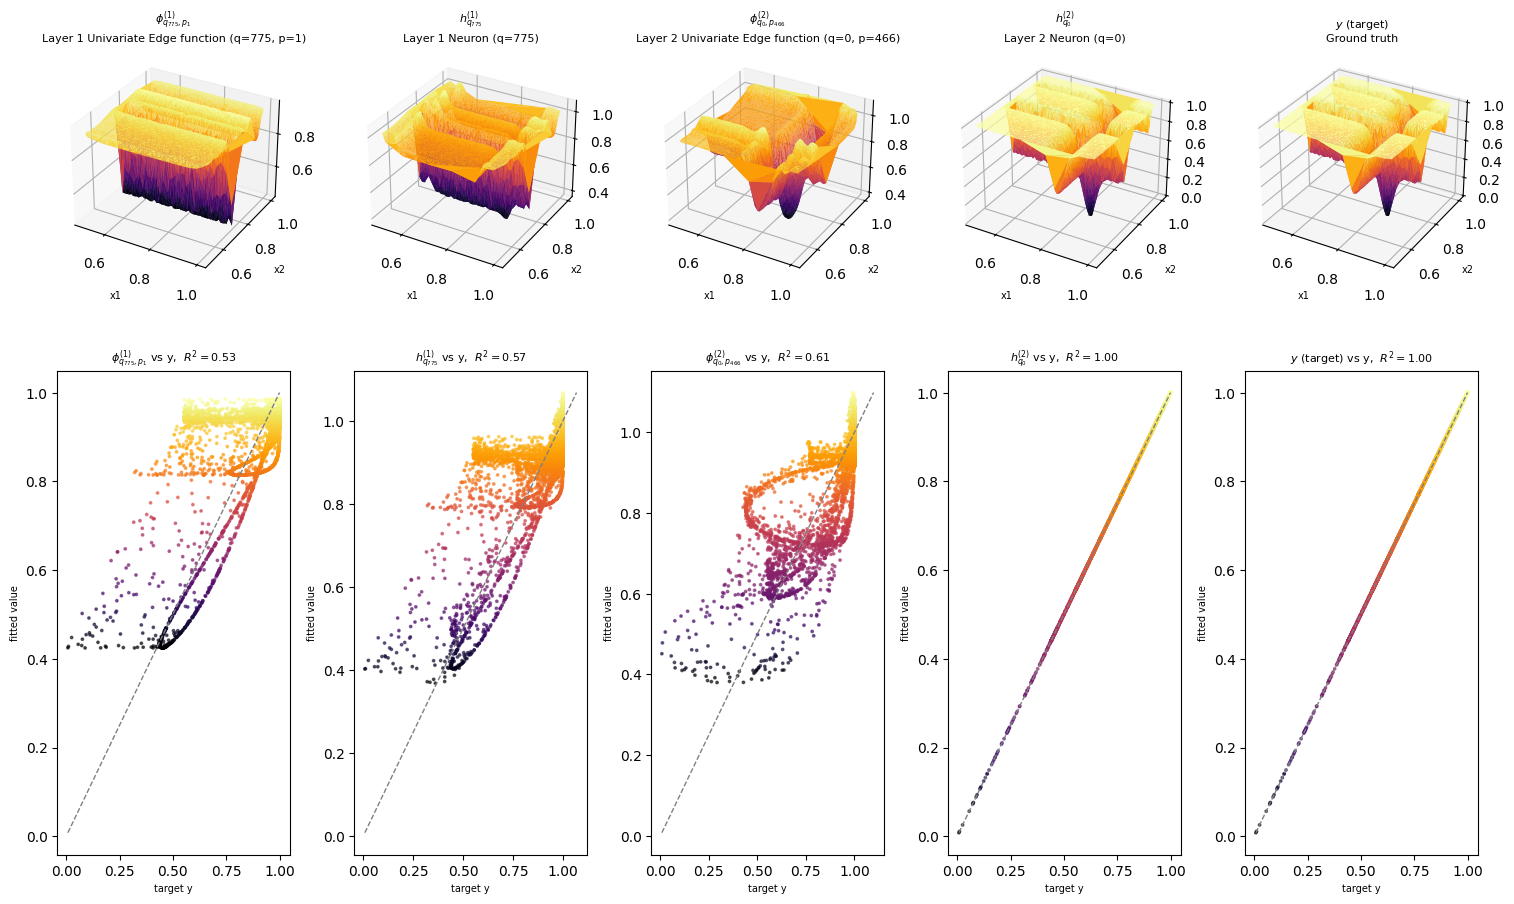

In [122]:
# TF5 HKAN
tf5_hkan_layer_configs = [
    dict(layer=0, n_vars_out=912, n_basis=23, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.01)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

tf5_hkan_stages, tf5_ytrain_hat = utils.stack_hkan_layers(tf5_x_train, tf5_y_train, tf5_hkan_layer_configs)
visualize.plot_model_stages(tf5_x_train, tf5_y_train, tf5_hkan_stages, block_idx="random", seed=0)

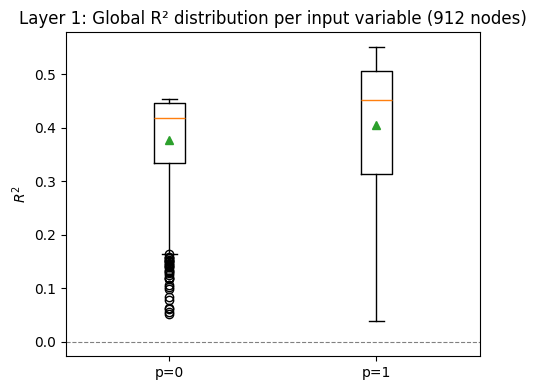

In [123]:
visualize.plot_first_layer_featurewise_r2_summary(tf5_hkan_stages, tf5_y_train)

In [124]:
tf5_hkan_model = utils.build_hkan_model_from_configs(tf5_hkan_layer_configs)
utils.fit_hkan(tf5_hkan_model, tf5_x_train, tf5_y_train)

Fitting connecting regressors: 100%|██████████| 1/1 [00:00<00:00,  5.02it/s]


✓ HKAN training completed in 5.9948 seconds


In [125]:
tf5_hkan_results = em.evaluate(tf5_hkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
em.print_results(tf5_hkan_results)

Metric          Train                Test                
-------------------------------------------------------
MAE             2.558449e-13         4.165208e-13        
RMSE            3.215468e-13         1.150066e-12        
-------------------------------------------------------
Inference (s)   2.587146             4.005845            


In [126]:
tf5_hkan_50_runs_path = "data/tf5_hkan_50_run_results.csv"

if os.path.exists(tf5_hkan_50_runs_path):
    tf5_hkan_50_runs_df = pd.read_csv("data/tf5_hkan_50_run_results.csv")
else:
    tf5_hkan_50_runs = utils.run_hkan_seed_experiments(tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, tf5_hkan_layer_configs, n_runs=50)
    tf5_hkan_50_runs_df = utils.create_export_seed_results(tf5_hkan_50_runs, "tf5_hkan_50_run_results")

tf5_hkan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,2.3327981144e-13,2.9575955186e-13,1.989021583,2.4808557947e-13,3.1754580294e-13,3.648584958,5.693040917
1,1,1.6628137825e-13,2.0491430649e-13,1.801508625,2.1490755734e-13,3.8871623878e-13,3.492593459,5.720045292
2,2,1.4688257763e-13,1.8786524368e-13,1.856633584,2.0914209150e-13,5.3385358136e-13,3.660014667,5.610897458
3,3,1.4950484392e-13,1.9223864364e-13,1.939129542,2.2663629979e-13,5.1361883498e-13,3.496912250,5.642777334
4,4,1.6034552991e-13,1.9849968181e-13,1.742190958,2.0791424563e-13,3.6685826609e-13,4.059381375,5.721110583
5,5,1.7418091552e-13,2.1902291178e-13,2.246102625,2.5626502440e-13,5.8549986055e-13,4.442970000,6.116907125
6,6,2.3296421806e-13,2.8397055131e-13,1.927433917,3.1264493920e-13,7.4640808245e-13,3.866781959,5.614924791
7,7,1.8319372477e-13,2.2528757252e-13,1.969613667,2.0721278283e-13,2.6540469225e-13,3.771750583,5.795954000
8,8,1.5811561851e-13,1.9515323158e-13,1.908843458,2.1288438955e-13,3.9763669882e-13,3.905811458,5.759110333
9,9,2.8324583096e-13,3.4220229038e-13,2.035628208,3.9889824225e-13,1.0018040161e-12,3.953726250,5.611293875


In [127]:
tf5_hkan_summary = utils.summarize_metrics(tf5_hkan_50_runs_df, "TF5 HKAN")
tf5_hkan_summary

{'model': 'TF5 HKAN',
 'train_rmse_median': 2.240970868666831e-13,
 'train_rmse_iqr': 7.142021180771875e-14,
 'test_rmse_median': 3.8901535501829135e-13,
 'test_rmse_iqr': 2.1262966416959008e-13,
 'train_inference_time_median': 1.9534446459947503,
 'train_inference_time_iqr': 0.09681520824597101,
 'test_inference_time_median': 3.9123595415003365,
 'test_inference_time_iqr': 0.23907178123772566,
 'fit_time_median': 5.720577937507187,
 'fit_time_iqr': 0.17938461374433157}

### KAN

In [128]:
# TF5 KAN
tf5_kan_study = utils.study_optuna_kan("TF5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
tf5_kan_best_architecture = tf5_kan_study["architecture"]
tf5_kan_best_architecture

Results found for TF5. Loading from data/tf5_kan_optuna_search.csv
Best Validation RMSE:   0.000268
Best architecture:       [2, 5, 1]

All 10 trials:
   number  params_width_idx user_attrs_architecture  user_attrs_val_rmse user_attrs_grids  user_attrs_steps_per_grid user_attrs_opt  user_attrs_lamb   duration
0       0                 8            [2, 5, 3, 1]         0.0003187009      (5, 10, 20)                         20          LBFGS                0  59.969476
1       1                 1               [2, 2, 1]         0.0020459187      (5, 10, 20)                         20          LBFGS                0  23.936112
2       2                 5            [2, 3, 2, 1]         0.0009833178      (5, 10, 20)                         20          LBFGS                0  43.552150
3       3                 0                  [2, 1]         0.0153309495      (5, 10, 20)                         20          LBFGS                0   9.688724
4       4                 7            [2, 3, 3, 

[2, 5, 1]

In [129]:
start = time.perf_counter()
model = utils.build_kan(width=tf5_kan_best_architecture, grid=3, k=3, seed=42)
model = utils.fit_kan_with_grid_extension(
    model,
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test,
    grids=(5, 10, 20), steps_per_grid=20, opt="LBFGS", lamb=0
)
fit_time = time.perf_counter() - start
print("TF5 KAN Training time: ", fit_time)

tf5_kan_results = em.evaluate(
    utils.KANModel(model),
    tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(tf5_kan_results)

checkpoint directory created: ./model
saving model version 0.0


| train_loss: 4.14e-02 | test_loss: 4.20e-02 | reg: 1.37e+01 | : 100%|█| 20/20 [00:06<00:00,  3.20it


saving model version 0.1
saving model version 0.2


| train_loss: 2.14e-02 | test_loss: 2.14e-02 | reg: 1.41e+01 | : 100%|█| 20/20 [00:06<00:00,  3.30it


saving model version 0.3
saving model version 0.4


| train_loss: 1.79e-03 | test_loss: 1.90e-03 | reg: 1.23e+01 | : 100%|█| 20/20 [00:07<00:00,  2.54it


saving model version 0.5
saving model version 0.6


| train_loss: 4.78e-04 | test_loss: 5.31e-04 | reg: 1.23e+01 | : 100%|█| 20/20 [00:12<00:00,  1.55it

saving model version 0.7

✓ KAN training with grid extension completed in 33.4627 seconds
TF5 KAN Training time:  33.472502709000764
Metric          Train                Test                
-------------------------------------------------------
MAE             3.089717e-04         3.284045e-04        
RMSE            4.776988e-04         5.306665e-04        
-------------------------------------------------------
Inference (s)   0.017645             0.032298            


In [37]:
tf5_kan_50_runs_path = "data/tf5_kan_50_run_results.csv"

if os.path.exists(tf5_kan_50_runs_path):
    tf5_kan_50_runs_df = pd.read_csv("data/tf5_kan_50_run_results.csv")
else:
    tf5_kan_50_runs = utils.run_kan_seed_experiments(
        tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test,
        width=tf5_kan_best_architecture,
        grids=(5, 10, 20),
        steps_per_grid=20,
        opt="LBFGS",
        lamb=0,
        n_runs=50)
    tf5_kan_50_runs_df = utils.create_export_seed_results(tf5_kan_50_runs, "tf5_kan_50_run_results")

tf5_kan_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs,fit_time_secs
0,0,0.0005528877,0.0008569660,0.017197458,0.0005722667,0.0008890482,0.027977833,37.302441042
1,1,0.0010699365,0.0014771867,0.017714958,0.0012290424,0.0017482362,0.028743917,36.675452084
2,2,0.0002254754,0.0003268439,0.018274583,0.0002364916,0.0003365723,0.030636166,36.346473500
3,3,0.0007337612,0.0010132932,0.018766084,0.0007886004,0.0011013397,0.029622792,38.373381625
4,4,0.0003221939,0.0004343835,0.018508541,0.0003462330,0.0005043923,0.027332625,37.056635916
5,5,0.0002962898,0.0004081261,0.019224167,0.0003450103,0.0005471702,0.030718791,38.208729291
6,6,0.0002117355,0.0002901706,0.020231000,0.0002182183,0.0003042166,0.029726833,40.838296250
7,7,0.0004822479,0.0006166889,0.021335667,0.0005565736,0.0007498517,0.028568625,37.255412875
8,8,0.0003308126,0.0004588100,0.021541708,0.0003769080,0.0005530984,0.028523417,37.306363125
9,9,0.0002263123,0.0003486746,0.060328125,0.0002608452,0.0004024557,0.030609042,37.123033917


In [38]:
tf5_kan_summary = utils.summarize_metrics(tf5_kan_50_runs_df, "TF5 KAN")
tf5_kan_summary

{'model': 'TF5 KAN',
 'train_rmse_median': 0.0005116959219131499,
 'train_rmse_iqr': 0.000505328037797475,
 'test_rmse_median': 0.0005532206323413001,
 'test_rmse_iqr': 0.0005225507265031,
 'train_inference_time_median': 0.01945812500343885,
 'train_inference_time_iqr': 0.0016933752485783493,
 'test_inference_time_median': 0.03011610450630535,
 'test_inference_time_iqr': 0.0018799685130944273,
 'fit_time_median': 38.17779758349934,
 'fit_time_iqr': 1.293788468999992}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

In [39]:
tf5_hypothesis_1_path = "data/tf5_hypothesis_1_results_df.csv"

if os.path.exists(tf5_hypothesis_1_path):
    tf5_hypothesis_1_results_df = pd.read_csv(tf5_hypothesis_1_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf5_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    tf5_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf5_hypothesis_1_results_df.to_csv(tf5_hypothesis_1_path, index=False)

tf5_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1752523906,0.1772748196,0.1729328081,0.1750342162,4.3849197462e-02,4.3548397140e-02
1,1,10,0.1348603833,0.1346299552,0.1387088241,0.1389774793,1.9560166616e-02,1.9611767286e-02
2,2,25,0.1225806518,0.1233142290,0.1124346593,0.1152760487,1.6415402108e-02,1.6830933965e-02
3,3,50,0.0555545582,0.0563760235,0.0856136542,0.0875913105,4.4213981678e-03,4.6426776186e-03
4,4,100,0.0312809810,0.0319592326,0.0483029996,0.0510438614,1.8570823303e-04,1.9977532142e-04
5,5,250,0.0103980811,0.0115087670,0.0162204842,0.0181433504,9.2484792191e-11,2.1547613527e-10
6,6,500,0.0028677049,0.0036678253,0.0028873230,0.0037855780,6.5436451469e-13,1.0032765193e-12
7,7,750,0.0033233712,0.0052819257,0.0009233708,0.0019773005,2.2954721058e-13,2.8840089467e-13
8,8,1000,0.0005326688,0.0012303347,0.0006688014,0.0022385771,2.3059286159e-13,4.5875125699e-13


[plot_hypothesis_1_results] saved to static/TF5_Layer_Width_vs_RMSE.png


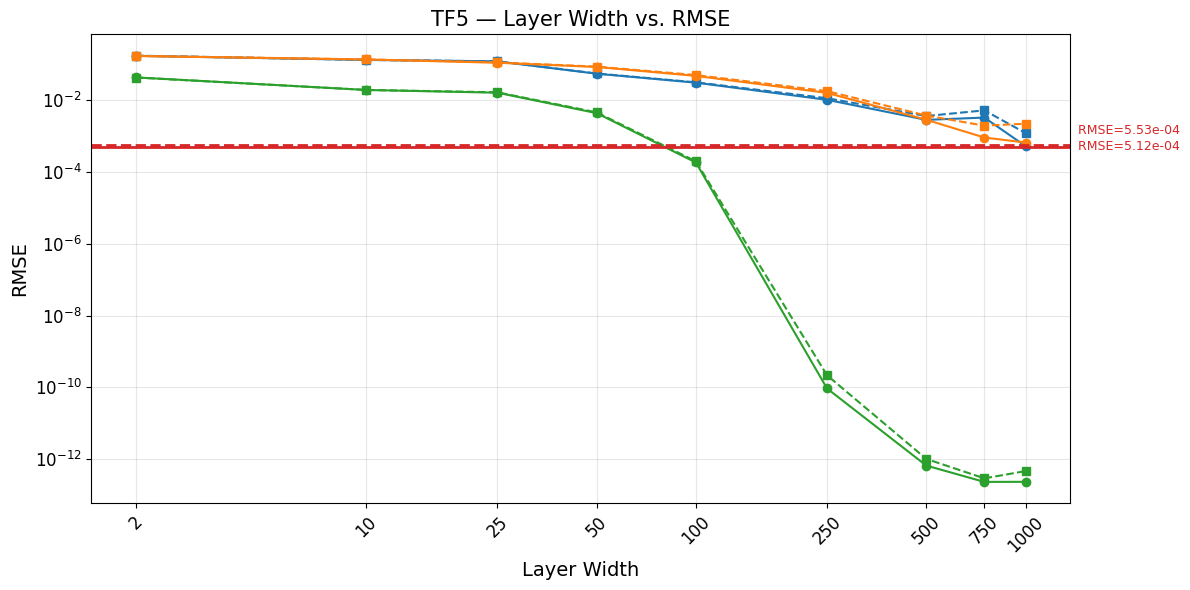

In [40]:
visualize.plot_hypothesis_1_results(
    tf5_hypothesis_1_results_df,
    kan_best_train_rmse=tf5_kan_summary['train_rmse_median'],
    kan_best_test_rmse=tf5_kan_summary['test_rmse_median'],
    title="TF5 — Layer Width vs. RMSE",
    show_legend=False
)

### Hypothesis 2

Increasing layer width (other parameters constant) vs. training time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [41]:
tf5_hypothesis_2_path = "data/tf5_hypothesis_2_results_df.csv"

if os.path.exists(tf5_hypothesis_2_path):
    tf5_hypothesis_2_results_df = pd.read_csv(tf5_hypothesis_2_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    timing = {
        'sgkan_swim': [],
        'sgkan_random': [],
        'hkan': [],
    }

    print("Timing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_sgkan_configs]
        config[0]['layer_width'] = width
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_swim'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        start = time.perf_counter()
        sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        fit_time = time.perf_counter() - start
        timing['sgkan_random'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    print("\nTiming HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf5_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        start = time.perf_counter()
        utils.fit_hkan(model, tf5_x_train, tf5_y_train)
        fit_time = time.perf_counter() - start
        timing['hkan'].append(fit_time)
        print(f"  Width {width}: {fit_time:.4f}s")

    tf5_hypothesis_2_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_fit_time': timing['sgkan_swim'],
        'sgkan_random_fit_time': timing['sgkan_random'],
        'hkan_fit_time': timing['hkan'],
    })
    tf5_hypothesis_2_results_df.to_csv(tf5_hypothesis_2_path, index=False)

tf5_hypothesis_2_results_df

,layer_width,sgkan_swim_fit_time,sgkan_random_fit_time,hkan_fit_time
0,2,0.037415959,0.041294208,0.010194583
1,10,0.168416083,0.192193750,0.071688500
2,25,0.444711958,0.441135833,0.177591708
3,50,0.974623375,0.828756542,0.287594208
4,100,1.741479625,2.164324000,0.677254166
5,250,4.755684417,4.272531834,1.627660375
6,500,8.572963750,8.644106875,3.106832667
7,750,13.118931292,13.156720333,4.537945917
8,1000,17.500530208,17.742192959,6.432982333


[plot_hypothesis_2_results] saved to static/TF5_Layer_Width_vs_Training_Time_s.png


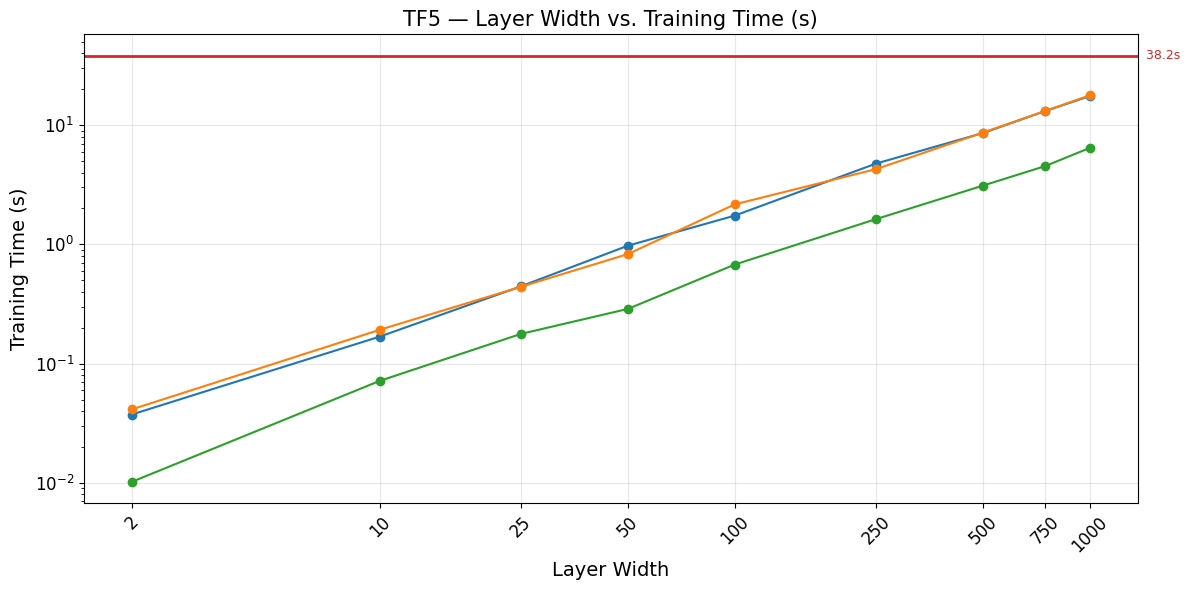

In [42]:
visualize.plot_hypothesis_2_results(
    tf5_hypothesis_2_results_df,
    kan_fit_time=tf5_kan_summary['fit_time_median'],
    title="TF5 — Layer Width vs. Training Time (s)",
    show_legend=False
)

### Hypothesis 3

Increasing layer width (other parameters constant) vs. inference time for different models: HKAN, SGKAN SWIM, SGKAN random, and KAN as a fixed reference.

In [43]:
tf5_hypothesis_3_path = "data/tf5_hypothesis_3_results_df.csv"

if os.path.exists(tf5_hypothesis_3_path):
    tf5_hypothesis_3_results_df = pd.read_csv(tf5_hypothesis_3_path)
else:
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    inf_times = {
        'sgkan_swim': {'train': [], 'test': []},
        'sgkan_random': {'train': [], 'test': []},
        'hkan': {'train': [], 'test': []},
    }

    print("Measuring SGKAN SWIM inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_sgkan_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        inf_times['sgkan_swim']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_swim']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring SGKAN Random inference time...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_sgkan_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        inf_times['sgkan_random']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['sgkan_random']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    print("\nMeasuring HKAN inference time...")
    for width in layer_widths:
        config = [c.copy() for c in tf5_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        inf_times['hkan']['train'].append(eval_results['train']['inference_time_secs'])
        inf_times['hkan']['test'].append(eval_results['test']['inference_time_secs'])
        print(f"  Width {width}: Train={eval_results['train']['inference_time_secs']:.4f}s, Test={eval_results['test']['inference_time_secs']:.4f}s")

    tf5_hypothesis_3_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_inf_time': inf_times['sgkan_swim']['train'],
        'sgkan_swim_test_inf_time': inf_times['sgkan_swim']['test'],
        'sgkan_random_train_inf_time': inf_times['sgkan_random']['train'],
        'sgkan_random_test_inf_time': inf_times['sgkan_random']['test'],
        'hkan_train_inf_time': inf_times['hkan']['train'],
        'hkan_test_inf_time': inf_times['hkan']['test'],
    })
    tf5_hypothesis_3_results_df.to_csv(tf5_hypothesis_3_path, index=False)

tf5_hypothesis_3_results_df

,layer_width,sgkan_swim_train_inf_time,sgkan_swim_test_inf_time,sgkan_random_train_inf_time,sgkan_random_test_inf_time,hkan_train_inf_time,hkan_test_inf_time
0,2,0.007985792,0.014596125,0.007392458,0.035639334,0.002936958,0.011274125
1,10,0.061394666,0.137685209,0.046757958,0.113619500,0.028651209,0.041442417
2,25,0.192381167,0.416878292,0.170812666,0.300880334,0.139095083,0.139711958
3,50,0.333463958,0.592981792,0.320331750,0.657943250,0.146100250,0.268020375
4,100,0.620023708,1.355102041,0.592297250,1.228859375,0.357402083,0.524544792
5,250,1.716956375,3.175009917,1.555557833,3.281168750,0.622330291,1.394959625
6,500,3.481942708,6.368147541,3.038381000,6.395253792,1.466098209,2.725921334
7,750,5.380338041,10.811481458,4.636220500,9.401282958,1.900023542,3.814480625
8,1000,6.234197042,12.632550750,6.757819334,13.746089833,2.481237875,5.445210209


[plot_hypothesis_3_results] saved to static/TF5_Layer_Width_vs_Inference_Time_s.png


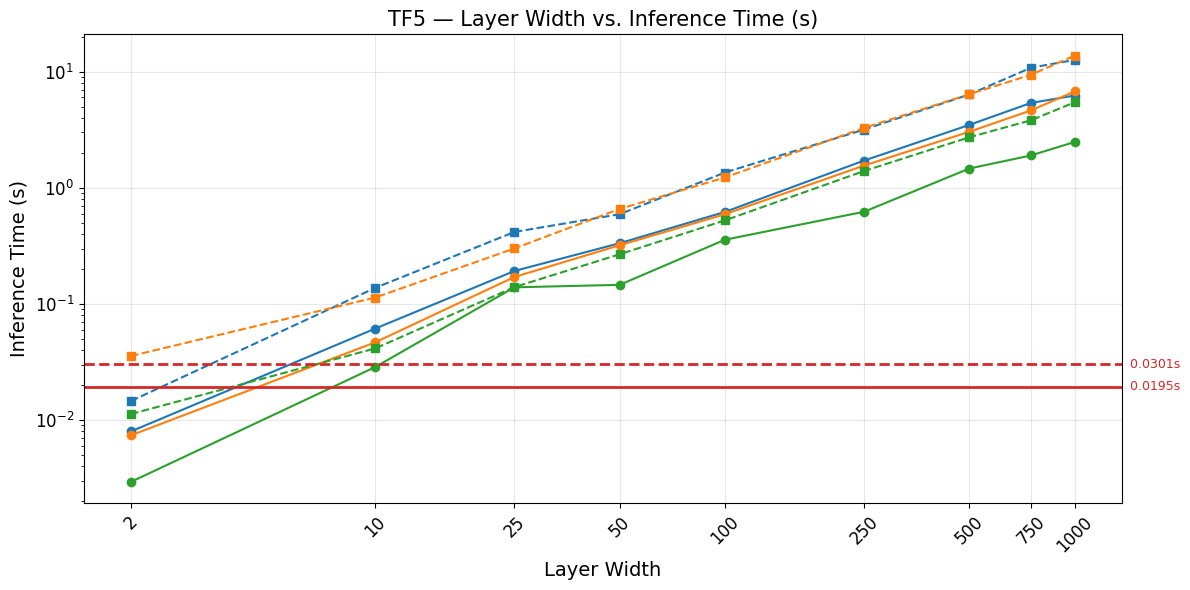

In [44]:
visualize.plot_hypothesis_3_results(
    tf5_hypothesis_3_results_df,
    kan_train_inference_time=tf5_kan_summary['train_inference_time_median'],
    kan_test_inference_time=tf5_kan_summary['test_inference_time_median'],
    title="TF5 — Layer Width vs. Inference Time (s)",
    show_legend=False
)